# Deconstructing Domain Shift in Diabetic Retinopathy Grading: A Multi-Scale Multiple Instance Learning Approach with Ordinal Regression

[![PyTorch](https://img.shields.io/badge/PyTorch-2.0%2B-EE4C2C.svg?logo=pytorch)](https://pytorch.org/)
[![License: MIT](https://img.shields.io/badge/License-MIT-blue.svg)](https://opensource.org/licenses/MIT)
[![Domain: Medical Imaging](https://img.shields.io/badge/Domain-Medical%20Computer%20Vision-success.svg)]()
[![Task: 5-Grade Ordinal DR](https://img.shields.io/badge/Task-5--Grade%20Ordinal%20DR-informational.svg)]()

---

## Executive Summary & Proposed System Architecture

This notebook implements the proposed **Multi-Scale Ordinal Multiple Instance Learning** deep neural architecture for automated Diabetic Retinopathy (DR) grading across the 5-grade International Clinical Diabetic Retinopathy Severity (ICDRS 0–4) scale.

The architecture directly addresses the key clinical failure modes under external domain shift:
1. **Resolution Collapse & Microaneurysm Destruction ($H_1$):** Downsampling ultra-high-resolution fundus images ($3000+\text{px}$) to standard CNN inputs ($224\text{px}$ or $300\text{px}$) physically obliterates focal microaneurysms ($\le 120\,\mu\text{m}$, sub-$15\text{px}$), causing sensitivity collapse on **Grade 1 (Mild NPDR)**.
2. **Context Fragmentation & 4-Quadrant Hemorrhage Density ($H_2$):** Diagnosing **Grade 3 (Severe NPDR)** requires spatial attention across the entire retinal hemisphere to assess hemorrhage density across all 4 quadrants (the clinical 4-2-1 rule). This is tackled via a Non-Local Block and Quadrant Token Transformer Aggregator.
3. **Ordinal Inconsistency & Nominal Softmax Pathology ($H_3$):** Nominal Softmax cross-entropy treats disease grades as independent categories, destroying the monotonic disease spectrum and causing severe rank probability violations.

### Core Architectural Components:
- **Global Context Stream ($512 \times 512$):** Pre-trained `ResNet-50` backbone with a Non-Local Self-Attention Block, Convolutional Block Attention Module (`CBAM`), and Quadrant Token Aggregator on Layer 4 to extract macro-retinal structural patterns and 4-quadrant vascular geometry ($F_{\text{Global}} \in \mathbb{R}^{4096}$, or $\mathbb{R}^{2048}$ without quadrant tokens).
- **Local Sliding-Window MIL Stream:** 4-step robust Retinal FOV Segmentation (`compute_fov_mask`) paired with sliding-window patch extraction (`extract_mil_patches_sliding`: $128 \times 128$ native patches with stride $s=96\text{ px}$ (with adaptive fallback $s=48$ for small images), adaptive FOV ratio $\ge 0.5$, stochastic $M \in [32, 64]$ in training, dense full-grid sweep up to 256 in evaluation). Features are encoded via `EfficientNet-B0` with Dual Pooling (1D Max-Pooling + Masked Gated Attention Pooling with `patch_mask` support) ($F_{\text{Local}} \in \mathbb{R}^{2560}$).
- **Multimodal Latent Fusion Layer:** Concatenates global and local features ($4096 + 2560 = 6656\text{-d}$, or $2048 + 2560 = 4608\text{-d}$) and projects into a normalized $512\text{-d}$ latent severity representation $\mathbf{z}$ via a LayerNorm MLP.
- **Champion CLM_QWK Ordinal Head:** Maps latent features to a 1D continuous severity axis $s(\mathbf{x}) = \mathbf{w}^T \mathbf{z}$ evaluated against strictly monotonic cutpoints $\theta_1 < \theta_2 < \theta_3 < \theta_4$ via the complementary log-log ($\text{clog-log}$) link function, optimized with a 2-component loss: $\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{NLL}}(\mathbf{p}, \mathbf{y}) + \lambda(t) \cdot \mathcal{L}_{\text{QWK}}(\mathbf{p}, \mathbf{y})$ with dynamic linear warmup.
- **Explainable AI (XAI) Verification ($H_5$):** Evaluates visual localization fidelity on ground-truth IDRiD lesion masks via Mean IoU and Pointing Game Accuracy with memory-safe hook cleanup.
- **Transparent High-Speed Caching Engine:** Precomputes FOV masks and valid patch anchors (`valid_anchors`) stored in compressed `.npz` format. DataLoader loads pre-selected anchors directly from cache in $O(1)$ time, bypassing CPU-intensive image decoding and morphological operations during training.
---

## 📑 Table of Contents

- [Executive Summary & Proposed System Architecture](#executive-summary--proposed-system-architecture)
  - [Core Architectural Components](#core-architectural-components)
- [1. Environment Setup & Configuration](#1-environment-setup--configuration)
  - [1.1 Library Imports & Single Logger](#11-library-imports--single-logger)
  - [1.2 Dataset Path Definitions](#12-dataset-path-definitions)
  - [1.3 Publication-Ready Plotting Standards](#13-publication-ready-plotting-standards)
- [2. Multi-Scale Retinal Data Pipeline](#2-multi-scale-retinal-data-pipeline)
  - [2.1 Green-Channel Preprocessing & Ablation Strategy](#21-green-channel-preprocessing--ablation-strategy)
  - [2.2 Global Context Data Augmentations](#22-global-context-data-augmentations)
  - [2.3 Dual-Branch PyTorch Dataset](#23-dual-branch-pytorch-dataset)
  - [2.4 Robust Retinal FOV Segmentation & Sliding-Window MIL Patch Extraction](#24-robust-retinal-fov-segmentation--sliding-window-mil-patch-extraction)
  - [2.5 DataLoader Initialization with Dynamic Collate](#25-dataloader-initialization-with-dynamic-collate)
  - [2.6 Visual Batch Inspection & Patch Verification](#26-visual-batch-inspection--patch-verification)
  - [2.7 Class Distribution & Imbalance Breakdown](#27-class-distribution--imbalance-breakdown)
- [3. Deep Neural Network Architecture & Ordinal Heads](#3-deep-neural-network-architecture--ordinal-heads)
  - [3.1 Convolutional Block Attention Module (CBAM)](#31-convolutional-block-attention-module-cbam)
    - [3.1.5 Non-local Block & Quadrant Tokens (Mechanism for H2)](#315-non-local-block--quadrant-tokens-architectural-mechanism-for-h2)
  - [3.2 Global Context Branch (ResNet-50 + Non-Local + CBAM + Quadrant Tokens)](#32-global-context-branch-resnet-50--non-local--cbam--quadrant-tokens)
  - [3.3 Local Sliding-Window MIL Branch (EfficientNet-B0 + Dual Pooling)](#33-local-sliding-window-mil-branch-efficientnet-b0--dual-pooling)
  - [3.4 Multimodal Dual-Branch Latent Fusion](#34-multimodal-dual-branch-latent-fusion)
  - [3.5 Output Head Ablation Suite & Loss Formulations](#35-output-head-ablation-suite--loss-formulations)
    - [3.5.1 Differentiable Continuous Quadratic Weighted Kappa (QWK) Loss](#351-differentiable-continuous-quadratic-weighted-kappa-qwk-loss)
    - [3.5.2 Output Head 1: Softmax + Categorical Cross-Entropy (Nominal Baseline)](#352-output-head-1-softmax--categorical-cross-entropy-nominal-baseline)
    - [3.5.3 Output Head 2: Softmax + Hybrid Continuous QWK Loss](#353-output-head-2-softmax--hybrid-continuous-qwk-loss)
    - [3.5.4 Output Head 3: Consistent Rank Logits (CORAL)](#354-output-head-3-consistent-rank-logits-coral)
    - [3.5.5 Output Head 4: Conditional Ordinal Regression Neural Network (CORN)](#355-output-head-4-conditional-ordinal-regression-neural-network-corn)
    - [3.5.6 Output Head 5: Cumulative Link Model + Continuous QWK (Champion Architecture)](#356-output-head-5-cumulative-link-model--continuous-qwk-champion-architecture)
  - [3.6 End-to-End Model Wrapper & Offline Feature Caching](#36-end-to-end-model-wrapper--offline-feature-caching)
  - [3.7 Unified Model Factory Builder](#37-unified-model-factory-builder)
- [4. Training Engine & Clinical Evaluation Metrics](#4-training-engine--clinical-evaluation-metrics)
  - [4.1 Comprehensive Medical & Statistical Metric Suite](#41-comprehensive-medical--statistical-metric-suite)
  - [4.2 High-Performance DRTrainer Engine with AMP](#42-high-performance-drtrainer-engine-with-amp)
- [5. Explainable AI (XAI) & Quantitative Saliency Fidelity](#5-explainable-ai-xai--quantitative-saliency-fidelity)
  - [5.1 FundusGradCAM Saliency Generator](#51-fundusgradcam-saliency-generator)
  - [5.2 Quantitative XAI Evaluation (Mean IoU & Pointing Game vs. IDRiD Masks)](#52-quantitative-xai-evaluation-mean-iou--pointing-game-vs-idrid-masks)
- [6. Evaluation & Publication-Quality Results Dashboard](#6-evaluation--publication-quality-results-dashboard)
  - [6.1 Best Checkpoint Restoration & In-Distribution Test Evaluation](#61-best-checkpoint-restoration--in-distribution-test-evaluation)
  - [6.2 4-Panel Publication Results Dashboard Generation](#62-4-panel-publication-results-dashboard-generation)


# 1. Environment Setup & Configuration

This section initializes required deep learning frameworks (`PyTorch`, `Torchvision`), scientific computing libraries (`NumPy`, `Pandas`, `Albumentations`, `OpenCV`), dynamic path injection for modular imports, a singleton logger to avoid duplicate log entries in interactive notebook environments, and publication-ready plotting aesthetics following IEEE/Springer journal guidelines.

## 1.1 Library Imports & Single Logger

In [50]:
# Upgrade & install required libraries
# !pip install -q --upgrade albumentations
# !pip install -q timm torchmetrics


In [51]:
import os
import sys
import time
import logging
from pathlib import Path, PureWindowsPath
from typing import List, Tuple, Union, Dict, Optional, Any

# --- Deep Learning & PyTorch Core ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset

# --- Image Processing & Data Manipulation ---
import cv2
cv2.setNumThreads(0)  # Mandatory: prevent OpenCV multi-threading contention in DataLoader workers
import numpy as np
import pandas as pd
from PIL import Image
import albumentations as A

# --- Dynamic Path Resolution ---
# Dynamically add the shared modular pipeline root ('pipeline/full') to sys.path
current_dir = Path().cwd()
full_pipeline_path = current_dir.parent.parent.parent / "pipeline" / "full"

if str(full_pipeline_path) not in sys.path:
    sys.path.append(str(full_pipeline_path))

# --- Clinical & Statistical Evaluation Metrics ---
from sklearn.metrics import (
    cohen_kappa_score,
    confusion_matrix,
    accuracy_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    auc,
)

# --- Logging Configuration ---
# Setup logger with a singleton stream handler to prevent duplicate logs in Jupyter/interactive runs
logger = logging.getLogger("DRTrainer")
if not logger.handlers:
    handler = logging.StreamHandler()
    formatter = logging.Formatter("[%(levelname)s | %(asctime)s | DRTrainer] %(message)s")
    handler.setFormatter(formatter)
    logger.addHandler(handler)
logger.setLevel(logging.INFO)

# --- Visualization & Academic Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import collections
from functools import partial
from tqdm.auto import tqdm
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
from google.colab import drive
import zipfile

In [52]:
# ==============================================================================
# 1. AUTOMATIC GOOGLE DRIVE MOUNTING (COLAB OR LOCAL)
# ==============================================================================
import os
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        print('Connecting to Google Drive...')
        drive.mount('/content/drive')
    else:
        print('Google Drive already mounted at /content/drive.')
except ImportError:
    print('Running in local environment (google.colab not available). Drive mount skipped.')


Google Drive already mounted at /content/drive.


In [53]:
# ==============================================================================
# 2. AUTOMATED DATASET UNPACKING TO COLAB LOCAL FAST SSD (/content/dataset_local)
# ==============================================================================
import os
import time

zip_source = '/content/drive/MyDrive/native_cropped.zip'   # Path on Google Drive
extract_dest = '/content/dataset_local'                   # Local fast SSD directory on Colab

if os.path.exists(zip_source):
    if not os.path.exists(extract_dest) or len(os.listdir(extract_dest)) == 0:
        os.makedirs(extract_dest, exist_ok=True)
        print(f"Extracting dataset archive '{zip_source}' to '{extract_dest}'...")
        t0 = time.time()
        # Fast shell decompression
        get_ipython().system('unzip -q "$zip_source" -d "$extract_dest"')
        print(f"-> Extraction completed in {time.time() - t0:.1f} seconds!")
        print(f"-> Directory structure at '{extract_dest}':")
        get_ipython().system('ls -lh "$extract_dest"')
    else:
        print(f"-> Dataset directory '{extract_dest}' already populated ({len(os.listdir(extract_dest))} items). Skipping extraction.")
else:
    print(f"[INFO] zip_source '{zip_source}' not found or running in local environment.")
    if os.path.exists(extract_dest):
        print(f"-> Found existing local dataset directory at '{extract_dest}'.")
    else:
        print(f"-> Note: Ensure dataset metadata and images are located at '{extract_dest}' or update DATA_ROOT.")


-> Dataset directory '/content/dataset_local' already populated (7 items). Skipping extraction.


## 1.2 Dataset Path Definitions

In [54]:
# ==============================================================================
# 1.2 ROOT DIRECTORIES & PATH SYSTEM CONFIGURATION
# ==============================================================================
DATA_ROOT   = '/content/dataset_local'
RESULT_ROOT = '/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/notebooks/diabetic_retinopathy/pipeline/model'

# Derived Experiment Folders (Preserving exact existing project structures)
CHECKPOINT_DIR = os.path.join(RESULT_ROOT, "checkpoints_main")
CACHE_DIR      = os.path.join("/content", "cache_fundus_dual_branch")
FIGURES_DIR    = os.path.join(RESULT_ROOT, "figures_publication")

# Quantitative XAI Ground Truth Segmentation Paths (IDRiD Benchmark Sub-task)
idrid_seg_root = "/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/data/raw/idrid_segmentation"
idrid_seg_image_dirs = [
    f"{idrid_seg_root}/DR_Testing_Set/Fundus Images",
    f"{idrid_seg_root}/DR_Training_Set/Fundus Images"
]
idrid_seg_mask_dirs = [
    f"{idrid_seg_root}/DR_Testing_Set/Combined Masks",
    f"{idrid_seg_root}/DR_Training_Set/Combined Masks"
]

# Ensure result and figure directories exist
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


In [ ]:
# ==============================================================================
# 1.3 GLOBAL EXPERIMENTAL CONFIGURATION & HYPERPARAMETERS (TWEAK HERE)
# ==============================================================================
# Set SMOKE_TEST to True for rapid sanity check (3 epochs), False for full official run
SMOKE_TEST = False

# --- Hardware & Reproducibility Settings ---
SEED = 42
num_workers = min(8, os.cpu_count() or 4)
use_pin_memory = torch.cuda.is_available()
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

# --- Image Dimension & Batch Processing ---
IMG_SIZE = 512
NUM_CLASSES = 5

# --- Model Architecture & Fusion Parameters ---
HEAD_TYPE = "CLM_QWK"      # Options: 'Softmax_CE', 'Softmax_QWK', 'CORAL', 'CORN', 'CLM_QWK'
FUSION_DIM = 512
PRETRAINED = True
USE_CBAM = True
USE_NONLOCAL = True
USE_QUADRANT_TOKENS = True

# --- LOSS STABILIZATION & CONTINUOUS QWK OPTIMIZATION ---
# Scaled down from 1.2 to 0.4 to prevent gradient instability on batch soft confusion matrices
TARGET_QWK_WEIGHT = 0.4

# --- Optimization, Schedulers, & Early Stopping ---
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MIN_LR = 1e-6

# Extended patience to allow full convergence without premature termination
PATIENCE_EARLY_STOPPING = 15
PATIENCE_REDUCE_LR = 4
REDUCE_LR_FACTOR = 0.5
GRAD_CLIP = 1.0

# --- Dataset Paths & Execution Mode Setup ---
image_root_dir = f"{DATA_ROOT}/native_cropped"

if SMOKE_TEST:
    print("[SMOKE TEST MODE]: Running rapid sanity check on pipeline flow (3 epochs, mini sample dataset).")
    csv_train_path = f"{DATA_ROOT}/raw/samples/hybrid/sample_50_metadata.csv"
    csv_val_path   = "../../../../data/raw/samples/hybrid/val_sample_50_metadata.csv"
    csv_test_path  = "../../../../data/raw/samples/hybrid/test_sample_50_metadata.csv"
    EPOCHS = 3
    BATCH_SIZE = 8
    QWK_WARMUP_EPOCHS = 1
    T_MAX = 3
else:
    print("[FULL RUN MODE]: Executing official full-dataset training (CosineAnnealing T_max=30).")
    csv_train_path = f"{DATA_ROOT}/train_balanced_metadata.csv"
    csv_val_path   = f"{DATA_ROOT}/val_metadata.csv"
    csv_test_path  = f"{DATA_ROOT}/test_metadata.csv"
    EPOCHS = 100
    BATCH_SIZE = 16  # Fixed at 16 for Google Colab T4 GPU (15GB VRAM) to prevent OOM
    # Extended linear warmup from 5 to 15 epochs to stabilize early batch QWK variance
    QWK_WARMUP_EPOCHS = 15
    T_MAX = 50

print(f"  - Train Path:     {csv_train_path}")
print(f"  - Val Path:       {csv_val_path}")
print(f"  - Test Path:      {csv_test_path}")
print(f"  - Active Head:    {HEAD_TYPE} (QWK Warmup Weight: {TARGET_QWK_WEIGHT}, Warmup Epochs: {QWK_WARMUP_EPOCHS})")
print(f"  - Epochs:         {EPOCHS} | Batch Size: {BATCH_SIZE} | EarlyStopping Patience: {PATIENCE_EARLY_STOPPING}")
print(f"  - Checkpoint Dir: {CHECKPOINT_DIR}")
print(f"  - Cache Dir:      {CACHE_DIR}")
plt.rcParams["savefig.dpi"] = 300


[FULL RUN MODE]: Executing official full-dataset training (CosineAnnealing T_max=30).
  - Train Path:     /content/dataset_local/train_balanced_metadata.csv
  - Val Path:       /content/dataset_local/val_metadata.csv
  - Test Path:      /content/dataset_local/test_metadata.csv
  - Active Head:    CLM_QWK (QWK Warmup Weight: 0.4, Warmup Epochs: 15)
  - Epochs:         100 | Batch Size: 16 | EarlyStopping Patience: 15
  - Checkpoint Dir: /content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/notebooks/diabetic_retinopathy/pipeline/model/checkpoints_main
  - Cache Dir:      /content/cache_fundus_dual_branch


## 1.3 Publication-Ready Plotting Standards

In [56]:
# ==================================================================================================
# 0. GLOBAL PUBLICATION PLOTTING CONFIGURATION (IEEE / Springer / Nature Standards)
# ==================================================================================================
def configure_publication_style():
    """
    Sets up cohesive typography, axis weights, subtle grids, and high-resolution
    export parameters suitable for IEEE/Springer journal publication figures.
    """
    plt.rcParams.update({
        # --- Typography & Font Hierarchy ---
        # Cross-platform sans-serif fallbacks with proportional font sizes
        'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
        'font.family': 'sans-serif',
        'font.size': 10.5,
        'axes.labelsize': 11.5,
        'axes.titlesize': 12.5,
        'xtick.labelsize': 10.0,
        'ytick.labelsize': 10.0,
        'legend.fontsize': 10.0,
        'figure.titlesize': 14.0,

        # --- Axis Spines & Grid Styling ---
        # Dark-slate borders with non-distracting dashed gridlines
        'axes.linewidth': 1.1,
        'axes.edgecolor': '#2d3748',
        'grid.linewidth': 0.7,
        'grid.alpha': 0.45,
        'grid.linestyle': '--',
        'grid.color': '#a0aec0',

        # --- Export & Rendering Quality ---
        # 300 DPI high-resolution output with automatic padding clipping
        'mathtext.fontset': 'dejavusans',
        'figure.dpi': 300,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.08
    })

    # Base clean background theme
    sns.set_theme(style="whitegrid")

# Apply publication style globally
configure_publication_style()

In [57]:
# Academic Color Palette Definitions (IEEE / Springer Guidelines)
C_NAVY     = "#1f4e79"  # In-Domain Validation / Baseline Primary
C_ORANGE   = "#e65100"  # Grade 1 (H1 Microaneurysm) / Accent
C_CHAMP    = "#008080"  # Proposed Champion Model (Teal)
C_TEAL     = "#0d9488"  # Alternative Teal Accent
C_GREEN    = "#2e7d32"  # Success / Accuracy / High Recall
C_RED      = "#c53030"  # Error / Violation / Severe Drop
C_CRIMSON  = "#c53030"  # Grade 3 (H2 Severe NPDR)
C_AMBER    = "#d97706"  # Warning / Intermediate Stage
C_PURPLE   = "#6b21a8"  # Monotonic cutpoints theta of CLM (H3)
C_SLATE    = "#4a5568"  # Neutral / Secondary
C_GRAY     = "#94a3b8"  # Muted baseline / Classes G0, G2, G4
C_DARKGRAY = "#475569"
C_EMERALD  = "#16a34a"


# 2. Multi-Scale Retinal Data Pipeline

To address the trade-off between macro-retinal structural context and micro-lesion visibility, our data pipeline processes each fundus photograph through two synchronized streams:
1. **Global Stream**: Resized to $512 \times 512$ pixels with stochastic spatial and photometric augmentations, capturing the entire retinal hemisphere and 4-quadrant lesion distribution.
2. **Local Stream**: Preserves native high-resolution details by computing a robust 4-step retinal FOV mask and extracting overlapping $128 \times 128$ patches via a sliding window (stride $s=96\text{ px}$ (with adaptive fallback $s=48$ for small images), FOV filter ratio $\ge 0.5$, dynamic $M \in [32, 64]$ during training, dense grid sweep during evaluation).

## 2.1 Green-Channel Preprocessing & Ablation Strategy
Extracts and enhances the Green channel ($G$), where hemoglobin absorbs light maximally and provides the highest optical contrast for microaneurysms, hemorrhages, and hard exudates. Implements Ben Graham local contrast normalization ($G' = 4G - 4 \cdot \text{Gaussian}(G) + 128$) and CLAHE enhancement.

In [58]:
def apply_green_channel_ablation(
    img_rgb: np.ndarray, ablation_mode: str = "ben_graham_green"
) -> np.ndarray:
    """
    Applies fundus image preprocessing ablations centered on the Green channel.
    The Green channel provides the highest contrast for retinal vascular micro-lesions
    (microaneurysms, hemorrhages, and exudates).

    Args:
        img_rgb: Input fundus image array in RGB format (H, W, 3).
        ablation_mode: Preprocessing strategy:
            - 'ben_graham_green': Gaussian background subtraction on Green channel.
            - 'clahe_green': Contrast Limited Adaptive Histogram Equalization.
            - 'raw_green' (default/fallback): Unmodified Green channel.

    Returns:
        Processed 3-channel pseudo-RGB image array (H, W, 3).
    """
    # Convert RGB to BGR for OpenCV operations and apply edge-preserving bilateral denoising
    bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    denoised = cv2.bilateralFilter(bgr, d=9, sigmaColor=75, sigmaSpace=75)
    b, g, r = cv2.split(denoised)

    if ablation_mode == "ben_graham_green":
        # Ben Graham method: subtract local illumination background to normalize color variance
        blurred = cv2.GaussianBlur(g, (0, 0), 30)
        adjusted = cv2.addWeighted(g, 4, blurred, -4, 128)
        processed = cv2.merge([adjusted, adjusted, adjusted])

    elif ablation_mode == "clahe_green":
        # CLAHE: enhances local micro-contrast without over-amplifying background camera noise
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced_g = clahe.apply(g)
        processed = cv2.merge([enhanced_g, enhanced_g, enhanced_g])

    else:
        # Fallback: replicate raw green channel across all 3 channels
        processed = cv2.merge([g, g, g])

    # Convert back to standard RGB format for downstream PyTorch transforms
    return cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)


## 2.2 Global Context Data Augmentations

Applies spatial transformations (horizontal/vertical flips, 90-degree rotations, affine shifts/scales) and color jitter strictly to the $512 \times 512$ global stream during training.

In [59]:
def get_global_augmentations(img_size: int = IMG_SIZE, is_train: bool = True) -> A.Compose:
    """
    Constructs the Albumentations transformation pipeline for the Global Context branch.
    Resizes whole-fundus images to fixed dimensions (IMG_SIZE x IMG_SIZE) and applies spatial/photometric
    augmentations during training while preserving anatomical integrity.
    Args:
        img_size: Target spatial resolution (height and width) in pixels.
        is_train: If True, applies randomized augmentations; otherwise, applies deterministic resize.
    Returns:
        Albumentations Compose transform pipeline.
    """
    if is_train:
        return A.Compose([
            # Deterministic bilinear interpolation resize
            A.Resize(height=img_size, width=img_size, interpolation=cv2.INTER_LINEAR),

            # Spatial invariances (rotational symmetry of retinal fundus morphology)
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(
                shift_limit=0.05,
                scale_limit=0.10,
                rotate_limit=30,
                p=0.5,
                border_mode=cv2.BORDER_CONSTANT
            ),

            # Photometric invariances (subtle illumination & camera exposure variations)
            A.RandomBrightnessContrast(
                brightness_limit=0.10,
                contrast_limit=0.10,
                p=0.5
            ),
        ])
    else:
        # Validation / Testing: deterministic resize only
        return A.Compose([
            A.Resize(height=img_size, width=img_size, interpolation=cv2.INTER_LINEAR)
        ])

## 2.3 Dual-Branch PyTorch Dataset

Custom `FundusDualBranchDataset` producing synchronized multi-modal sample dictionaries containing both the augmented global image and the native-resolution image. Loads native high-resolution images directly from the `native_path` column in the metadata CSV (with robust fallback path resolution to `data/raw/hybrid/native_cropped/[dataset_name]/...`).


In [60]:
class FundusDualBranchDataset(Dataset):
    def __init__(
        self,
        csv_path: Optional[Union[str, pd.DataFrame]] = None,
        img_size: int = IMG_SIZE,
        img_root: Optional[str] = None,
        split: str = "train",
        ablation_mode: str = "ben_graham_green",
        cache_dir: Optional[str] = None,
        patch_size: int = 128,
        stride: int = 96,
        transform: Optional[Any] = None,
        metadata: Optional[Union[str, pd.DataFrame]] = None,
        image_root_dir: Optional[str] = None
    ):
        """
        Dataset serving the proposed Dual-Branch model (Global + Local MIL) on Google Colab.
        Optimizations:
          1. Reads image paths directly from 'native_path' column in metadata CSV.
          2. Converts DataFrame to list of dicts (self.records) for O(1) in-memory indexing.
          3. Decodes JPEG via high-speed OpenCV C++ backend.
          4. Separates FOV Mask calculation (strictly on RAW RGB) from Ben Graham enhancement.
          5. Returns uint8 tensors to minimize PyTorch DataLoader IPC Shared Memory bandwidth (755MB -> 189MB/batch).
          6. Supports automatic on-the-fly precomputed NPZ cache saving & instant reloading via valid_anchors.
        """
        if csv_path is None:
            if metadata is not None:
                csv_path = metadata
            else:
                raise ValueError("FundusDualBranchDataset requires 'csv_path' or 'metadata'.")
        if img_root is None and image_root_dir is not None:
            img_root = image_root_dir

        if isinstance(csv_path, pd.DataFrame):
            self.df = csv_path.reset_index(drop=True)
        else:
            self.df = pd.read_csv(csv_path)

        self.records = self.df.to_dict("records")
        self.img_size = img_size
        self.patch_size = patch_size
        self.stride = stride
        self.split = split
        self.img_root = img_root
        self.ablation_mode = ablation_mode
        self.is_train = (split == "train")
        self.cache_dir = cache_dir

        # Augmentation and resize applied ONLY to the Global stream
        self.global_transform = get_global_augmentations(
            img_size, is_train=self.is_train
        )

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records[idx]
        label = int(row.get("diagnosis", 0))

        # 1. Resolve image path
        native_path_str = str(row.get("native_path", row.get("raw_full_path", "")))
        dataset_key = row.get("dataset_key", "default")
        if self.img_root and not os.path.isabs(native_path_str) and not os.path.exists(native_path_str):
            img_path = f"{self.img_root}/{dataset_key}/{PureWindowsPath(native_path_str).name}"
        else:
            img_path = native_path_str

        # 2. Check if precomputed NPZ cache is available
        img_id = PureWindowsPath(native_path_str).stem if native_path_str else str(row.get("image_id", idx))
        cache_file = os.path.join(self.cache_dir, dataset_key, f"{img_id}.npz") if self.cache_dir else None

        if cache_file and os.path.exists(cache_file):
            try:
                data = np.load(cache_file)
                processed_np = data["img"]
                valid_anchors = data["anchors"]
                fov_mask = None
            except Exception:
                processed_np, valid_anchors, fov_mask = None, None, None
        else:
            processed_np, valid_anchors, fov_mask = None, None, None

        if processed_np is None:
            # Read JPEG via high-speed OpenCV backend
            bgr = cv2.imread(img_path)
            if bgr is not None:
                img_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            else:
                try:
                    pil_img = Image.open(img_path).convert("RGB")
                    img_rgb = np.array(pil_img)
                except Exception as e:
                    logger.error(f"Error loading image from {img_path}: {e}")
                    img_rgb = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

            # CRITICAL: Compute FOV mask strictly on RAW RGB image BEFORE Ben Graham
            fov_mask = compute_fov_mask(img_rgb, erode_px=15)

            # Apply Green channel ablation / Ben Graham background subtraction
            processed_np = apply_green_channel_ablation(
                img_rgb, ablation_mode=self.ablation_mode
            )
            valid_anchors = compute_valid_anchors(
                img_rgb.shape[:2], fov_mask, patch_size=self.patch_size, stride=self.stride, fov_thresh=0.5
            )

            # Auto-save cache archive for subsequent epochs (Epoch 2 -> 100+)
            if cache_file:
                try:
                    os.makedirs(os.path.dirname(cache_file), exist_ok=True)
                    np.savez_compressed(cache_file, img=processed_np, anchors=valid_anchors)
                except Exception:
                    pass

        # ======================================================================
        # STREAM 1: GLOBAL CONTEXT BRANCH -> RESIZE (uint8 tensor for IPC speed)
        # ======================================================================
        global_augmented = self.global_transform(image=processed_np)
        global_img = global_augmented["image"] if isinstance(global_augmented, dict) else global_augmented
        # Retain uint8 tensor to slash IPC shared memory transfer (Normalized on GPU in DRTrainer)
        global_tensor = torch.from_numpy(global_img).permute(2, 0, 1).contiguous()

        # ======================================================================
        # STREAM 2: LOCAL MIL BRANCH -> PRESERVE NATIVE HIGH-RESOLUTION & ANCHORS
        # ======================================================================
        local_native_np = processed_np

        return {
            "global_image": global_tensor,
            "local_native_image": local_native_np,
            "fov_mask": fov_mask,
            "valid_anchors": valid_anchors,
            "native_path": img_path,
            "label": torch.tensor(label, dtype=torch.long),
        }


## 2.4 Robust Retinal FOV Segmentation & Sliding-Window MIL Patch Extraction

Implements a 4-step robust Retinal Field-of-View (FOV) segmentation pipeline (`compute_fov_mask`) replacing brittle static thresholding (`gray > 15`), paired with a sliding-window Multiple Instance Learning (MIL) patch extractor (`extract_mil_patches_sliding`):
1. **Otsu's Adaptive Thresholding**: Dynamically computes the optimal bimodal intensity threshold per image.
2. **Morphological Close & Open**: Seals internal retinal mask holes with a $25 \times 25$ ellipse structuring element and cleans isolated noise.
3. **Largest Connected Component**: Isolates the true retinal disk via `cv2.connectedComponentsWithStats`, eliminating calibration text, camera watermarks, and lens dust.
4. **Inward Boundary Erosion (`erode_px = 15`)**: Eliminates untrusted edge vignetting and illumination halos at the camera perimeter.
5. **Sliding-Window Patch Extraction**: Strided overlapping window scanning ($128 \times 128$, stride $s=96$, FOV ratio $\ge 0.5$) with stochastic sampling ($M \in [32, 64]$) in training and dense sweep in evaluation.
6. **Dynamic Batch Collate (`trainer_compatible_collate_fn`)**: Synchronizes variable patch counts using zero-padding and boolean `patch_mask` `[Batch, N_max]`.

In [61]:
# ==============================================================================
# 2.4 ROBUST RETINAL FOV & SLIDING-WINDOW MIL PATCH EXTRACTION
# ==============================================================================

def compute_fov_mask(img_np: np.ndarray, erode_px: int = 15) -> np.ndarray:
    """
    Computes the true retinal Field-of-View (FOV) binary mask for a SINGLE fundus image.
    IMPORTANT: Must be computed on the RAW RGB fundus image BEFORE Ben Graham preprocessing.
    (Ben Graham sets background to 128 gray, which collapses Otsu thresholding).

    4-Step Pipeline:
    1. Otsu's Adaptive Thresholding: Dynamically calculates the optimal bimodal threshold on raw image.
    2. Morphological Close + Open (25x25 ellipse): Seals internal vessel holes and removes noise.
    3. Largest Connected Component: Strictly retains the main retinal disk (removes artifacts/watermarks).
    4. Inward Morphological Erosion (erode_px=15): Strips away peripheral edge vignetting/halos.
    """
    if img_np.ndim == 3:
        # Green channel offers highest absorption contrast for retinal boundaries
        gray = img_np[:, :, 1] if img_np.shape[2] == 3 else img_np[:, :, 0]
    else:
        gray = img_np

    # 1. Otsu's Adaptive Thresholding
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, binary = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # 2. Morphological Close & Open
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

    # 3. Largest Connected Component
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned, connectivity=8)
    if num_labels > 1:
        largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        fov_mask = (labels == largest_label).astype(np.uint8) * 255
    else:
        fov_mask = cleaned

    # 4. Inward Erosion
    if erode_px > 0:
        kernel_erode = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE, (erode_px * 2 + 1, erode_px * 2 + 1)
        )
        fov_mask = cv2.erode(fov_mask, kernel_erode)

    return (fov_mask > 0).astype(np.uint8)


def compute_valid_anchors(
    img_shape: Tuple[int, int],
    fov_mask: np.ndarray,
    patch_size: int = 128,
    stride: int = 96,
    fov_thresh: float = 0.5
) -> np.ndarray:
    """
    Calculates 2D top-left coordinate anchors [y0, x0] passing the FOV threshold.
    Returns (N, 2) numpy array of integer coordinates.
    """
    h, w = img_shape[:2]
    p = patch_size

    if np.any(fov_mask):
        coords = np.argwhere(fov_mask)
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
    else:
        y_min, x_min, y_max, x_max = 0, 0, h, w

    content_h = max(1, y_max - y_min)
    content_w = max(1, x_max - x_min)

    def get_coords(curr_stride: int):
        s = max(1, curr_stride)
        y_starts = list(range(y_min, y_min + content_h - p + 1, s)) if content_h > p else [y_min]
        x_starts = list(range(x_min, x_min + content_w - p + 1, s)) if content_w > p else [x_min]

        if content_h > p and (y_min + content_h - p) not in y_starts:
            y_starts.append(y_min + content_h - p)
        if content_w > p and (x_min + content_w - p) not in x_starts:
            x_starts.append(x_min + content_w - p)

        valid_list = []
        for y0 in y_starts:
            for x0 in x_starts:
                y1, x1 = min(y0 + p, h), min(x0 + p, w)
                mask_patch = fov_mask[y0:y1, x0:x1]
                fov_ratio = mask_patch.mean() if mask_patch.size > 0 else 0.0
                if fov_ratio >= fov_thresh:
                    valid_list.append([y0, x0])
        return valid_list

    anchors = get_coords(stride)
    if len(anchors) < 32 and stride > 48 and min(content_h, content_w) > p:
        dense_anchors = get_coords(48)
        if len(dense_anchors) > len(anchors):
            anchors = dense_anchors

    if len(anchors) == 0:
        cy = max(0, y_min + content_h // 2 - p // 2)
        cx = max(0, x_min + content_w // 2 - p // 2)
        anchors = [[cy, cx]]

    return np.array(anchors, dtype=np.int32)


# ==============================================================================
# SLIDING-WINDOW MIL PATCH EXTRACTION (Overlapping s=96 + Raw FOV Filter + uint8 IPC)
# ==============================================================================
def extract_mil_patches_sliding(
    img_np: np.ndarray,
    fov_mask: Optional[np.ndarray] = None,
    patch_size: int = 128,
    stride: int = 96,
    fov_thresh: float = 0.5,
    mode: str = "train",
    num_sample: Union[int, Tuple[int, int]] = 48,
    max_patches_eval: int = 256,
    native_path: Optional[str] = None,
    valid_anchors: Optional[np.ndarray] = None,
    return_anchors: bool = False
) -> Union[torch.Tensor, Tuple[torch.Tensor, np.ndarray]]:
    h, w, _ = img_np.shape
    p = patch_size

    if mode == "train":
        if isinstance(num_sample, (tuple, list)):
            m_target = int(np.random.randint(num_sample[0], num_sample[1] + 1))
        else:
            m_target = int(num_sample)
    else:
        m_target = max_patches_eval

    # Fast-path (cache) — GIỮ NGUYÊN, không đổi
    if valid_anchors is not None and len(valid_anchors) > 0:
        n_anchors = len(valid_anchors)
        if mode == "train":
            if n_anchors < m_target:
                idx = np.random.choice(n_anchors, size=m_target, replace=True)
            else:
                idx = np.random.choice(n_anchors, size=m_target, replace=False)
            selected_coords = valid_anchors[idx]
        else:
            max_eval = min(n_anchors, max_patches_eval)
            idx = np.linspace(0, n_anchors - 1, max_eval).astype(int)
            selected_coords = valid_anchors[idx]

        patches = []
        for y0, x0 in selected_coords:
            y1, x1 = min(y0 + p, h), min(x0 + p, w)
            patch = img_np[y0:y1, x0:x1]
            if patch.shape[0] < p or patch.shape[1] < p:
                pad_h = max(0, p - patch.shape[0])
                pad_w = max(0, p - patch.shape[1])
                patch = np.pad(patch, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
            patches.append(patch)

        patches_np = np.stack(patches, axis=0)
        tensor_patches = torch.from_numpy(patches_np).permute(0, 3, 1, 2).contiguous()
        if return_anchors:
            return tensor_patches, np.asarray(selected_coords, dtype=np.int32)
        return tensor_patches

    # Nhánh tính on-the-fly
    if fov_mask is None:
        fov_mask = compute_fov_mask(img_np, erode_px=15)

    if np.any(fov_mask):
        coords = np.argwhere(fov_mask)
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
    else:
        y_min, x_min, y_max, x_max = 0, 0, h, w

    content_h = max(1, y_max - y_min)
    content_w = max(1, x_max - x_min)

    # >>> SỬA: get_candidates giờ trả thêm danh sách anchor tương ứng
    def get_candidates(current_stride):
        s = max(1, current_stride)
        y_starts = list(range(y_min, y_min + content_h - p + 1, s)) if content_h > p else [y_min]
        x_starts = list(range(x_min, x_min + content_w - p + 1, s)) if content_w > p else [x_min]

        if content_h > p and (y_min + content_h - p) not in y_starts:
            y_starts.append(y_min + content_h - p)
        if content_w > p and (x_min + content_w - p) not in x_starts:
            x_starts.append(x_min + content_w - p)

        cands, cand_anchors = [], []
        for y0 in y_starts:
            for x0 in x_starts:
                y1, x1 = y0 + p, x0 + p
                y1c, x1c = min(y1, h), min(x1, w)
                patch = img_np[y0:y1c, x0:x1c]
                mask_patch = fov_mask[y0:y1c, x0:x1c]
                fov_ratio = mask_patch.mean() if mask_patch.size > 0 else 0.0
                if fov_ratio < fov_thresh:
                    continue

                if patch.shape[0] < p or patch.shape[1] < p:
                    pad_h = max(0, p - patch.shape[0])
                    pad_w = max(0, p - patch.shape[1])
                    patch = np.pad(patch, ((0, pad_h), (0, pad_w), (0, 0)), mode="reflect")
                cands.append(patch)
                cand_anchors.append([y0, x0])   # <-- track tọa độ
        return cands, cand_anchors

    candidates, cand_anchors = get_candidates(stride)

    if mode == "train" and len(candidates) < m_target and stride > 48 and min(content_h, content_w) > p:
        dense_candidates, dense_anchors = get_candidates(48)
        if len(dense_candidates) > len(candidates):
            candidates, cand_anchors = dense_candidates, dense_anchors

    if len(candidates) == 0:
        cy = max(0, y_min + content_h // 2 - p // 2)
        cx = max(0, x_min + content_w // 2 - p // 2)
        patch = img_np[cy:cy + p, cx:cx + p]
        if patch.shape[0] < p or patch.shape[1] < p:
            patch = np.pad(patch, ((0, max(0, p - patch.shape[0])), (0, max(0, p - patch.shape[1])), (0, 0)), mode="reflect")
        candidates = [patch]
        cand_anchors = [[cy, cx]]

    if mode == "train":
        if len(candidates) < m_target:
            idx = np.random.choice(len(candidates), size=m_target, replace=True)
        else:
            idx = np.random.choice(len(candidates), size=m_target, replace=False)
        selected = [candidates[i] for i in idx]
        selected_anchors = [cand_anchors[i] for i in idx]
    else:
        if len(candidates) > max_patches_eval:
            idx = np.linspace(0, len(candidates) - 1, max_patches_eval).astype(int)
            selected = [candidates[i] for i in idx]
            selected_anchors = [cand_anchors[i] for i in idx]
        else:
            selected = candidates
            selected_anchors = cand_anchors

    patches_np = np.stack(selected, axis=0)
    patches_u8 = torch.from_numpy(patches_np).permute(0, 3, 1, 2).contiguous()

    # >>> SỬA: check return_anchors ở cuối, giống hệt nhánh fast-path
    if return_anchors:
        return patches_u8, np.asarray(selected_anchors, dtype=np.int32)
    return patches_u8


# ==============================================================================
# OFFLINE PRECOMPUTATION & NPZ CACHING ENGINE
# ==============================================================================
def precompute_dataset_cache(
    df: pd.DataFrame,
    img_root: Optional[str] = None,
    cache_dir: str = "./cache",
    patch_size: int = 128,
    stride: int = 96,
    fov_thresh: float = 0.5,
    ablation_mode: str = "ben_graham_green"
) -> Dict[str, int]:
    """
    Offline precomputes and saves compressed NPZ cache files containing:
      - 'img': Preprocessed image array (processed_u8, uint8)
      - 'anchors': Valid patch anchor top-left coordinates (N, 2)
    Eliminates redundant CPU calculations across 100+ training epochs.
    """
    os.makedirs(cache_dir, exist_ok=True)
    records = df.to_dict("records")

    def process_single(row):
        dataset_key = row.get("dataset_key", "default")
        native_path_str = str(row.get("native_path", row.get("raw_full_path", "")))
        img_id = PureWindowsPath(native_path_str).stem if native_path_str else str(row.get("image_id", "sample"))

        target_dir = os.path.join(cache_dir, dataset_key)
        os.makedirs(target_dir, exist_ok=True)
        out_path = os.path.join(target_dir, f"{img_id}.npz")

        if os.path.exists(out_path):
            return True

        if img_root and not os.path.isabs(native_path_str) and not os.path.exists(native_path_str):
            img_path = os.path.join(img_root, dataset_key, PureWindowsPath(native_path_str).name)
        else:
            img_path = native_path_str

        bgr = cv2.imread(img_path)
        if bgr is None:
            return False

        img_rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        fov_mask = compute_fov_mask(img_rgb, erode_px=15)
        processed_u8 = apply_green_channel_ablation(img_rgb, ablation_mode=ablation_mode)
        valid_anchors = compute_valid_anchors(
            img_rgb.shape[:2], fov_mask, patch_size=patch_size, stride=stride, fov_thresh=fov_thresh
        )

        np.savez_compressed(out_path, img=processed_u8, anchors=valid_anchors)
        return True

    success_count = 0
    fail_count = 0

    print(f"[INFO] Precomputing NPZ cache for {len(records)} samples -> '{cache_dir}'...")
    for r in tqdm(records, desc="Precomputing NPZ Cache"):
        res = process_single(r)
        if res:
            success_count += 1
        else:
            fail_count += 1

    print(f"[INFO] Cache generation completed: {success_count} succeeded, {fail_count} failed.")
    return {"success": success_count, "failed": fail_count}


# ==============================================================================
# CUSTOM BATCH COLLATE_FN (uint8 IPC Transmission & Synchronized Masks)
# ==============================================================================
def trainer_compatible_collate_fn(
    batch,
    mode: str = "train",
    num_sample: Union[int, Tuple[int, int]] = (32, 64)
):
    """
    Collate function transmitting raw uint8 tensors across shared memory IPC:
    - Train mode: Returns [Batch, M, 3, 128, 128] uint8 tensor.
    - Eval mode: Zero-pads variable patch count up to batch maximum N_max, returns boolean patch_mask.
    """
    if mode == "train":
        if isinstance(num_sample, (tuple, list)):
            batch_m = int(np.random.randint(num_sample[0], num_sample[1] + 1))
        else:
            batch_m = int(num_sample)
    else:
        batch_m = num_sample

    global_imgs = torch.stack([item["global_image"] for item in batch], dim=0)
    local_patches_list = [
        extract_mil_patches_sliding(
            item["local_native_image"],
            fov_mask=item.get("fov_mask"),
            patch_size=128,
            stride=96,
            fov_thresh=0.5,
            mode=mode,
            num_sample=batch_m,
            native_path=item.get("native_path"),
            valid_anchors=item.get("valid_anchors")
        )
        for item in batch
    ]
    labels = torch.stack([item["label"] for item in batch], dim=0)

    if mode == "train":
        local_patches = torch.stack(local_patches_list, dim=0)  # [Batch, M, 3, 128, 128] uint8
        return {
            "global_img": global_imgs,
            "local_patches": local_patches,
            "label": labels,
        }

    # --- Eval Mode: Zero-pad variable patch counts to batch maximum N_max ---
    n_max = max(p.shape[0] for p in local_patches_list)
    padded, masks = [], []
    for p in local_patches_list:
        n = p.shape[0]
        if n < n_max:
            pad = torch.zeros((n_max - n, *p.shape[1:]), dtype=p.dtype)
            p = torch.cat([p, pad], dim=0)
        mask = torch.zeros(n_max, dtype=torch.bool)
        mask[:n] = True
        padded.append(p)
        masks.append(mask)

    local_patches = torch.stack(padded, dim=0)     # [Batch, N_max, 3, 128, 128] uint8
    patch_mask = torch.stack(masks, dim=0)         # [Batch, N_max], True = valid patch

    return {
        "global_img": global_imgs,
        "local_patches": local_patches,
        "patch_mask": patch_mask,
        "label": labels,
    }


# Collate function aliases for pipeline convenience
from functools import partial
train_collate_fn = partial(trainer_compatible_collate_fn, mode="train", num_sample=(32, 64))
eval_collate_fn = partial(trainer_compatible_collate_fn, mode="eval")


## 2.5 DataLoader Initialization with Dynamic Collate

Instantiates PyTorch DataLoaders for Training, In-Domain Validation, and Held-out In-Distribution Testing (15% split) with multi-threaded dynamic patch batching.

In [62]:
# ==============================================================================
# 2.5 DATALOADER INITIALIZATION & PRE-WARMING CACHE ROUTINE
# ==============================================================================
from functools import partial

# ------------------------------------------------------------------------------
# 1. INSTANTIATE DUAL-BRANCH DATASETS (Train / Val / Test)
# ------------------------------------------------------------------------------
# Training Dataset: enables spatial/photometric data augmentations on Global stream
train_dataset = FundusDualBranchDataset(
    csv_path=csv_train_path,
    img_root=image_root_dir,
    img_size=IMG_SIZE,
    split="train",
    ablation_mode="ben_graham_green",
    cache_dir=CACHE_DIR
)

# In-Domain Validation Dataset: deterministic resize without random augmentations
val_dataset = FundusDualBranchDataset(
    csv_path=csv_val_path,
    img_root=image_root_dir,
    img_size=IMG_SIZE,
    split="val",
    ablation_mode="ben_graham_green",
    cache_dir=CACHE_DIR
)

# Held-out In-Distribution Test Dataset (15% split): deterministic evaluation
test_dataset = FundusDualBranchDataset(
    csv_path=csv_test_path,
    img_root=image_root_dir,
    img_size=IMG_SIZE,
    split="test",
    ablation_mode="ben_graham_green",
    cache_dir=CACHE_DIR
)

# ------------------------------------------------------------------------------
# 2. CONFIGURE COLLATE FUNCTIONS (Distinct Train vs Eval Data Loading)
# ------------------------------------------------------------------------------
# Train mode: Randomly samples M in [32, 64] patches per image for stochastic regularization
train_collate_fn = partial(trainer_compatible_collate_fn, mode="train", num_sample=(32, 64))

# Eval & Test mode: Deterministic dense patch sweep (up to max_patches_eval=256) + boolean patch_mask
eval_collate_fn = partial(trainer_compatible_collate_fn, mode="eval")

# ------------------------------------------------------------------------------
# 3. OPTIONAL PRE-WARMING CACHE ENGINE (Precomputes all .npz files before training)
# ------------------------------------------------------------------------------
def warm_cache_dual_branch(dataset: FundusDualBranchDataset, num_workers: int = num_workers, batch_size: int = 16):
    """
    Iterates through the dataset once to precompute and save all .npz archives
    (FOV masks, patch anchors, preprocessed images) on disk before launching training.
    """
    loader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=False,
        collate_fn=lambda b: [item.get("native_path", "") for item in b]
    )
    for _ in tqdm(loader, desc=f"Pre-caching [{dataset.split}]"):
        pass

# ------------------------------------------------------------------------------
# 4. INITIALIZE PYTORCH DATALOADERS
# ------------------------------------------------------------------------------
eval_batch_size = BATCH_SIZE // 4  # batch_size=1 prevents OOM on dense patch grids and avoids padding variance
# Training DataLoader: batch shuffling & parallel workers enabled
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
    collate_fn=train_collate_fn,
    persistent_workers=(num_workers > 0),
    drop_last=True
)

# Validation DataLoader: deterministic sequential evaluation (eval_collate_fn)
val_loader = DataLoader(
    val_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
    collate_fn=eval_collate_fn,
    persistent_workers=(num_workers > 0)
)

# Held-out Test DataLoader: deterministic sequential evaluation (eval_collate_fn)
test_loader = DataLoader(
    test_dataset,
    batch_size=eval_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
    collate_fn=eval_collate_fn,
    persistent_workers=(num_workers > 0)
)

print(f"[INFO] DataLoaders Initialized Successfully:")
print(f"  - Train: batch_size={BATCH_SIZE}, mode='train' (M=32 - 64 stochastic sub-sampling, shuffle=True)")
print(f"  - Val:   batch_size={eval_batch_size}, mode='eval' (Deterministic full dense sweep + Masked Pooling)")
print(f"  - Test:  batch_size={eval_batch_size}, mode='eval' (Held-out In-Distribution Test, dense sweep)")


/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[INFO] DataLoaders Initialized Successfully:
  - Train: batch_size=16, mode='train' (M=32 - 64 stochastic sub-sampling, shuffle=True)
  - Val:   batch_size=4, mode='eval' (Deterministic full dense sweep + Masked Pooling)
  - Test:  batch_size=4, mode='eval' (Held-out In-Distribution Test, dense sweep)


In [63]:
# ==============================================================================
# 1. INSPECT ARBITRARY SAMPLE IN TRAINING DATASET
# ==============================================================================
sample_idx = 0  # Modify this index to inspect any image (e.g., 0, 10, 150, etc.)
sample = train_dataset[sample_idx]

global_tensor = sample["global_image"]       # Global fundus stream tensor [3, H, W]
fov_mask = sample["fov_mask"]                 # Calculated FOV binary mask (or None if cached)
valid_anchors = sample["valid_anchors"]       # Precomputed patch anchors
native_img = sample["local_native_image"]     # Native-resolution image (H, W, 3)
label_val = sample["label"].item()
img_path = sample.get("native_path", "N/A")

fov_info = f"{fov_mask.mean() * 100:.2f}% of total image area" if fov_mask is not None else f"{len(valid_anchors)} valid anchors (loaded from precomputed cache)"

print("=" * 75)
print(f"SAMPLE DIAGNOSTICS & TENSOR METRICS (INDEX: {sample_idx})")
print("=" * 75)
print(f"• Native File Path       : {img_path}")
print(f"• Clinical Label (Grade) : ICDRS Grade {label_val}")
print(f"• Global Tensor Shape    : {global_tensor.shape} (Channels, Height, Width)")
print(f"• Global Tensor Dtype    : {global_tensor.dtype}")
print(f"• Value Statistics       : Min = {global_tensor.min().item()} | Max = {global_tensor.max().item()}")
print(f"• Mean Pixel Intensity   : {global_tensor.float().mean().item():.2f}")
print(f"• Retinal FOV / Anchors  : {fov_info}")
print("=" * 75)
print("5x5 Center Pixel Intensity Matrix (Channel 0):")
print(global_tensor[0, 250:255, 250:255])
print("=" * 75)


SAMPLE DIAGNOSTICS & TENSOR METRICS (INDEX: 0)
• Native File Path       : /content/dataset_local/native_cropped/IDRiD/IDRiD_118.jpg
• Clinical Label (Grade) : ICDRS Grade 0
• Global Tensor Shape    : torch.Size([3, 512, 512]) (Channels, Height, Width)
• Global Tensor Dtype    : torch.uint8
• Value Statistics       : Min = 24 | Max = 255
• Mean Pixel Intensity   : 163.14
• Retinal FOV / Anchors  : 910 valid anchors (loaded from precomputed cache)
5x5 Center Pixel Intensity Matrix (Channel 0):
tensor([[158, 150, 150, 157, 165],
        [165, 159, 163, 154, 161],
        [166, 159, 168, 159, 157],
        [170, 157, 156, 172, 154],
        [166, 154, 150, 170, 163]], dtype=torch.uint8)


## 2.6 Visual Batch Inspection & Patch Verification

Sanity-check visualization confirming correct denormalization, global context geometry, and patch grid coverage across the active retinal field.

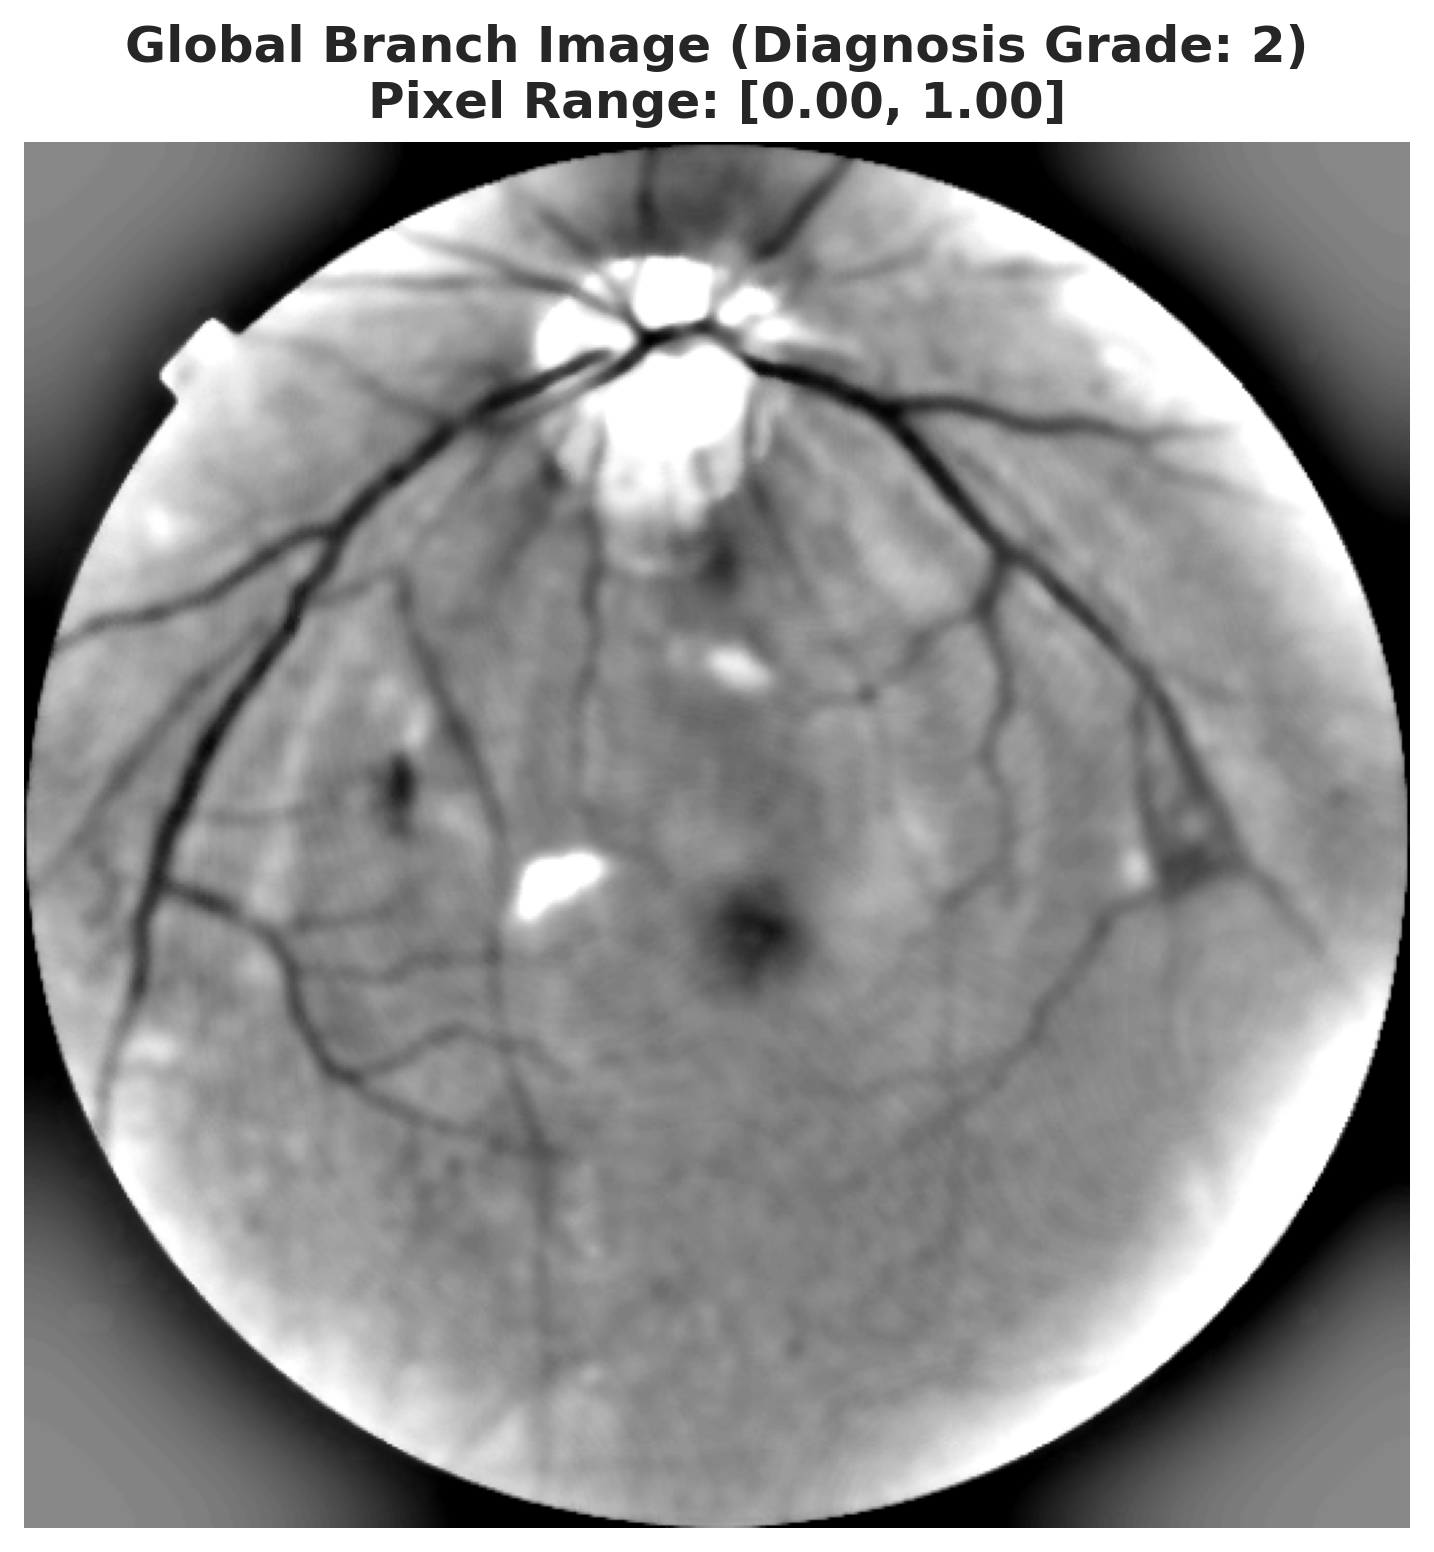

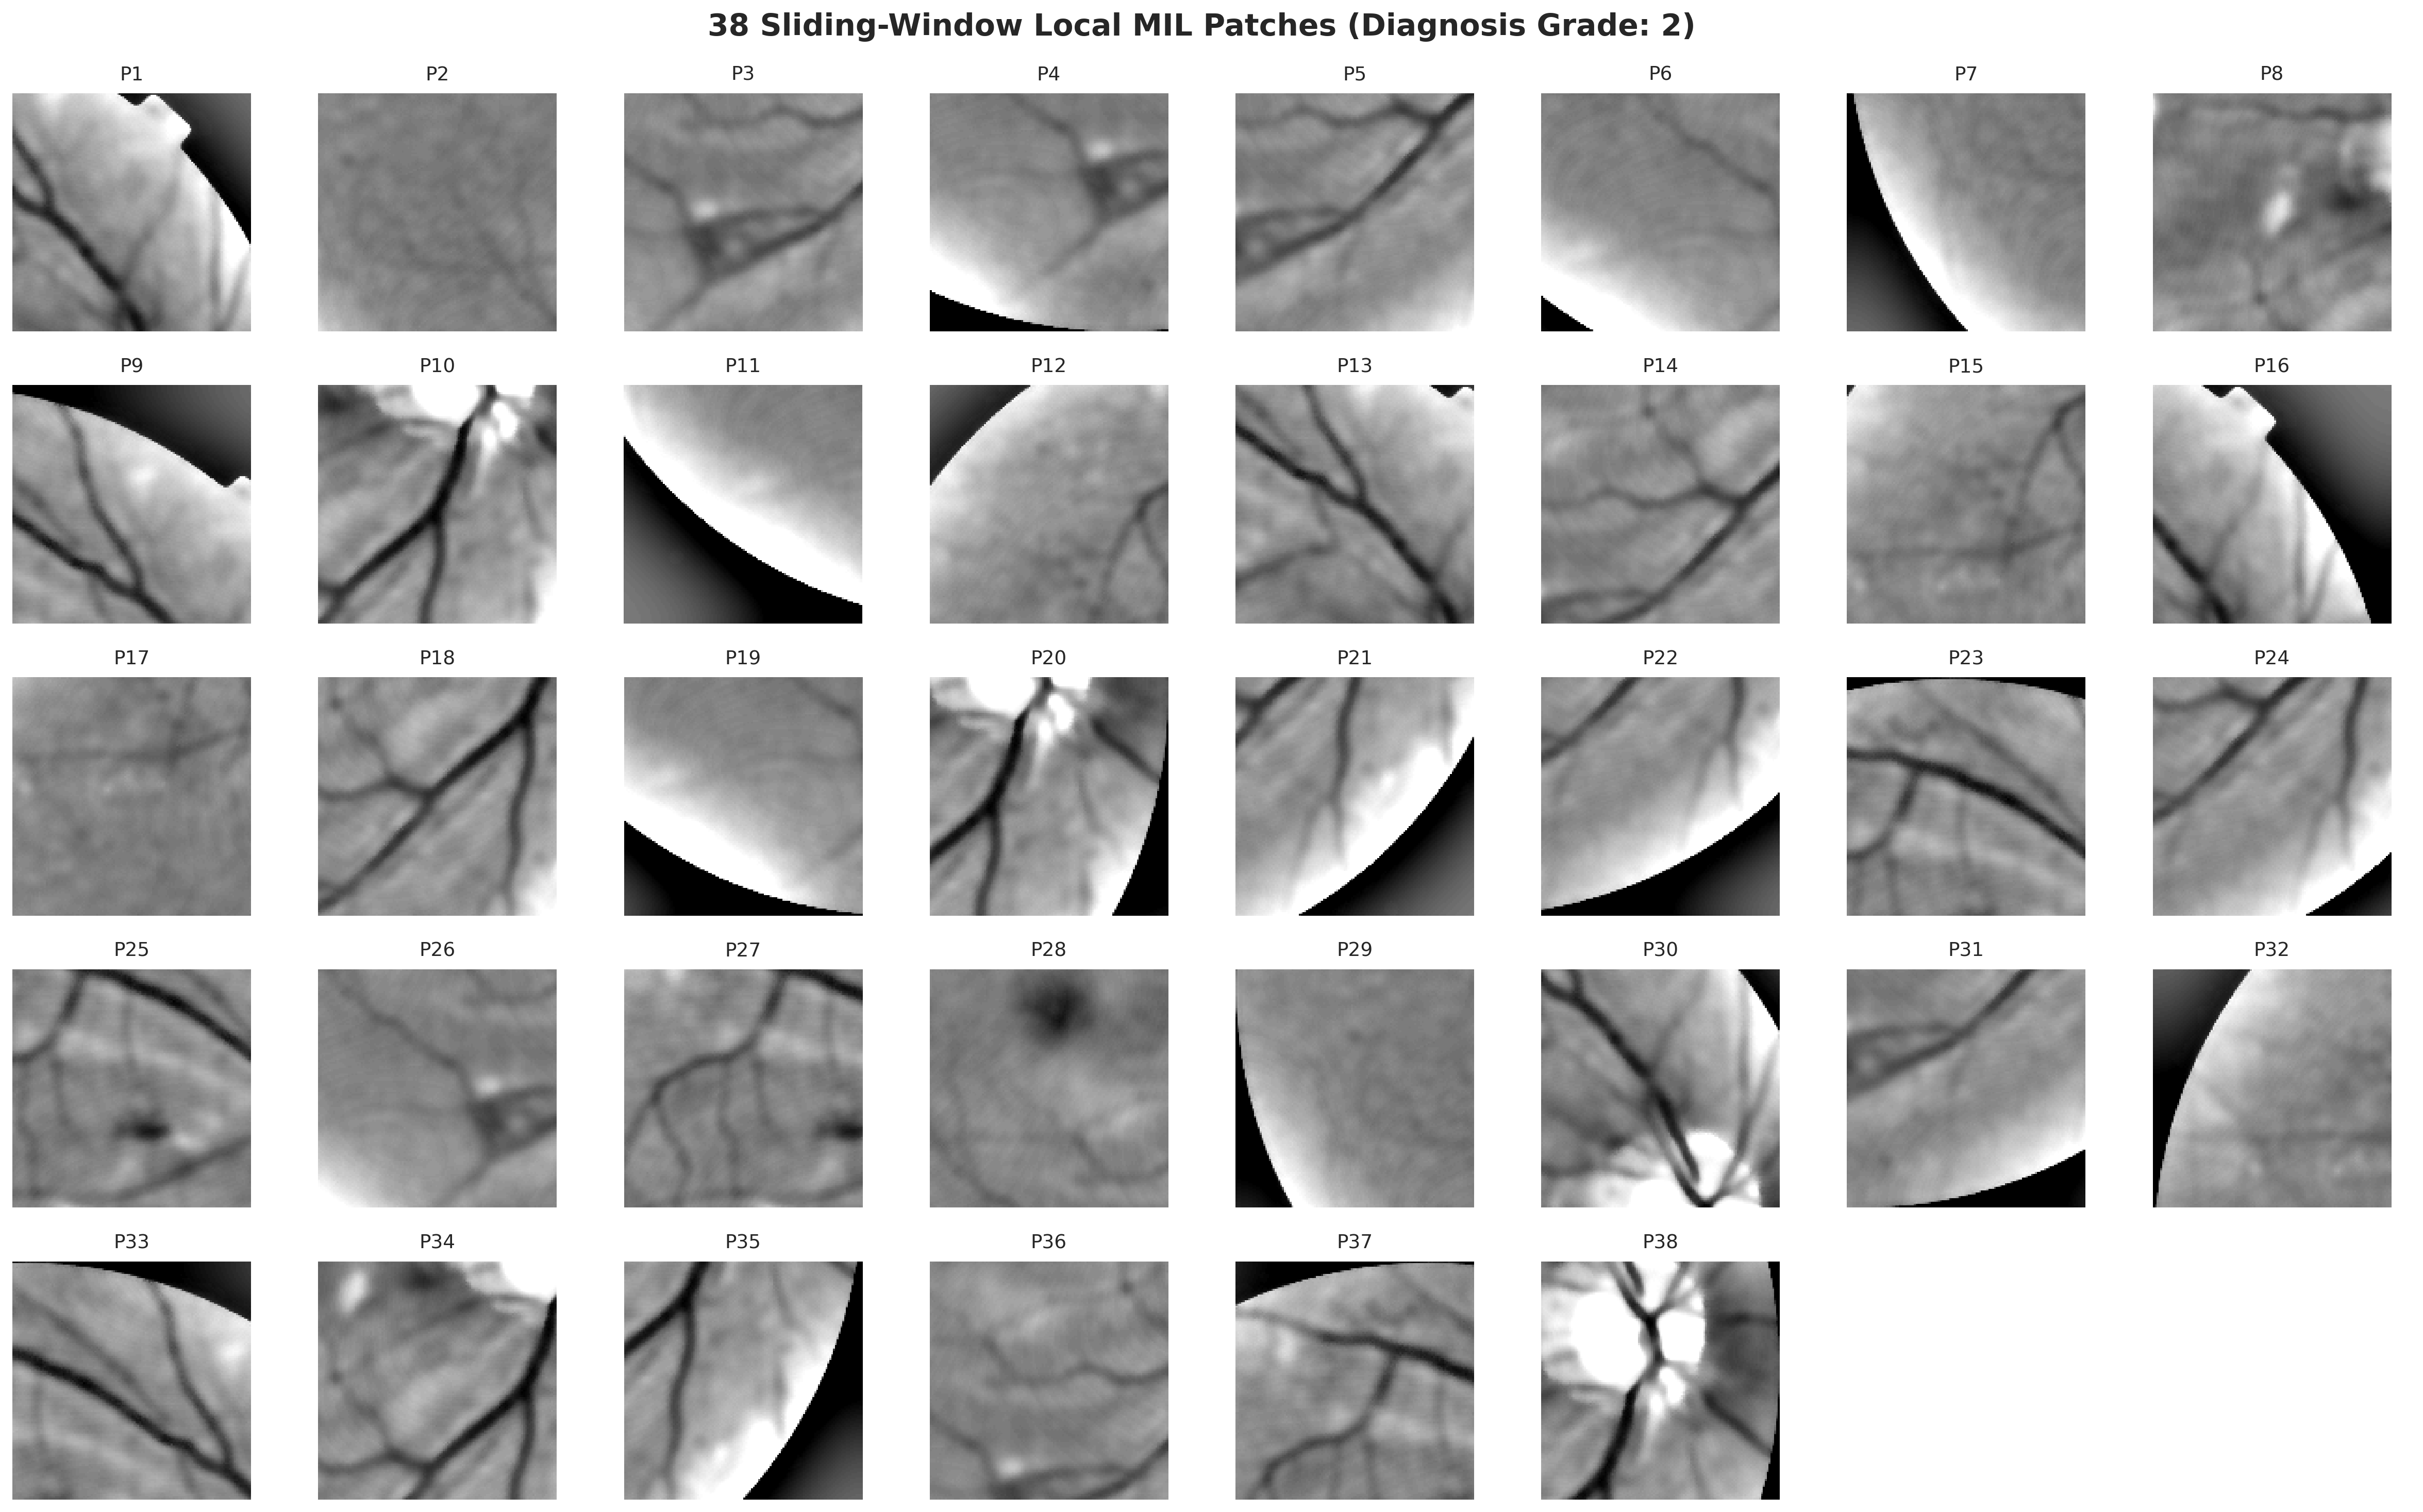

In [64]:
# ==============================================================================
# 1. FETCH A SINGLE MINI-BATCH FOR VISUAL VALIDATION
# ==============================================================================
for batch in train_loader:
    global_imgs = batch["global_img"]      # Tensor shape: [Batch, 3, 512, 512]
    local_patches = batch["local_patches"] # Tensor shape: [Batch, N, 3, 128, 128]
    labels = batch["label"]                # Tensor shape: [Batch]
    break
def safe_convert_for_plot(img_data: torch.Tensor) -> np.ndarray:
    """
    Converts any image tensor format (uint8, float32, raw RGB, or ImageNet Z-score normalized)
    into a standardized float32 NumPy array in range [0.0, 1.0] for accurate Matplotlib rendering.
    """
    if isinstance(img_data, torch.Tensor):
        if img_data.ndim == 4:
            img_data = img_data[0]
        if img_data.ndim == 3 and img_data.shape[0] in [1, 3]:
            img_data = img_data.permute(1, 2, 0)
        arr = img_data.detach().cpu().numpy()
    else:
        arr = np.array(img_data)

    arr = np.squeeze(arr).astype(np.float32)

    # Range calibration for Matplotlib [0.0, 1.0] display standard
    if arr.max() > arr.min():
        if arr.min() < 0:  # ImageNet Z-score normalized tensor (contains negative values)
            mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
            std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
            if arr.ndim == 3 and arr.shape[-1] == 3:
                arr = arr * std + mean
            arr = np.clip(arr, 0.0, 1.0)
        elif arr.max() > 1.0:  # Unnormalized integer or float scale [0, 255]
            arr = arr / 255.0
            arr = np.clip(arr, 0.0, 1.0)
    else:
        arr = np.zeros_like(arr)

    return arr
# Select sample index within the mini-batch (index = 0)
img_idx = 0
label_val = labels[img_idx].item()
# ------------------------------------------------------------------------------
# 2. VISUALIZE GLOBAL CONTEXT IMAGE (Whole Fundus Stream)
# ------------------------------------------------------------------------------
global_plot = safe_convert_for_plot(global_imgs[img_idx])
plt.figure(figsize=(6, 6))
plt.imshow(global_plot)
plt.title(
    f"Global Branch Image (Diagnosis Grade: {label_val})\n"
    f"Pixel Range: [{global_plot.min():.2f}, {global_plot.max():.2f}]",
    fontsize=12,
    fontweight="bold"
)
plt.axis("off")
plt.show()
# ------------------------------------------------------------------------------
# 3. VISUALIZE LOCAL MIL PATCHES (Dynamic Sliding-Window Grid)
# ------------------------------------------------------------------------------
patches = local_patches[img_idx]  # Tensor shape: [N, 3, 128, 128]
num_patches = patches.shape[0]
# Calculate dynamic subplot grid dimensions
ncols = 8 if num_patches >= 16 else 4
nrows = int(np.ceil(num_patches / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.0, nrows * 2.0))
fig.suptitle(
    f"{num_patches} Sliding-Window Local MIL Patches (Diagnosis Grade: {label_val})",
    fontsize=14,
    fontweight="bold"
)
axes_flat = np.array(axes).flatten()
for i in range(len(axes_flat)):
    if i < num_patches:
        p_plot = safe_convert_for_plot(patches[i])
        axes_flat[i].imshow(p_plot)
        axes_flat[i].set_title(f"P{i+1}", fontsize=9)
    # Hide unused subplot axes
    axes_flat[i].axis("off")
plt.tight_layout()
plt.show()

## 2.7 Class Distribution & Imbalance Breakdown

Analyzes the 5-class severity distribution (Grade 0: Normal to Grade 4: Proliferative DR) and reports on-the-fly augmentation parameters.


In [65]:
def visualize_dataset_statistics(
    csv_path: str,
    save_path: str = None
):
    """
    Parses the metadata CSV directly (via 'diagnosis' column) and generates a bar chart
    displaying exact sample counts for each clinical grade (Grade 0 to Grade 4).
    """
    # 1. Load metadata from CSV file
    df = pd.read_csv(csv_path)
    counts_series = df['diagnosis'].value_counts()
    total_samples = len(df)

    # 2. Define clinical class labels and extract exact counts
    classes = [f"Grade {i}" for i in range(5)]
    raw_counts = [int(counts_series.get(i, 0)) for i in range(5)]

    # 3. Print structured summary table to console
    print("=" * 60)
    print("DATASET CLASS DISTRIBUTION SUMMARY")
    print("=" * 60)
    for i in range(5):
        print(f"  • Grade {i}: {raw_counts[i]:>6} images")
    print("-" * 60)
    print(f"Total Sample Count: {total_samples} images")
    print("=" * 60)

    # 4. Configure Matplotlib publication style
    if 'configure_publication_style' in globals():
        configure_publication_style()
    else:
        plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

    fig, ax = plt.subplots(figsize=(9.5, 5.5))

    # Academic color palette representing 5 DR severity stages
    bar_colors = ["#1f4e79", "#2b6cb0", "#319795", "#d69e2e", "#c53030"]

    # 5. Render single-bar distribution chart
    bars = ax.bar(
        classes,
        raw_counts,
        color=bar_colors,
        edgecolor="#2d3748",
        width=0.5,
        alpha=0.9,
        zorder=3
    )

    # 6. Annotate exact sample counts directly above each bar
    max_count = max(raw_counts) if raw_counts else 1
    for bar, count in zip(bars, raw_counts):
        height = bar.get_height()
        ax.annotate(
            f"{count}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold",
            color="#2d3748"
        )

    # 7. Configure axis labels, title, and limits
    ax.set_xlabel("Diabetic Retinopathy Clinical Severity Grade", fontsize=11.5, fontweight="bold", labelpad=10)
    ax.set_ylabel("Sample Count", fontsize=11.5, fontweight="bold", labelpad=8)
    ax.set_title(f"Class Distribution Breakdown (Total: {total_samples} Images)", fontsize=13, fontweight="bold", pad=14)

    ax.set_ylim(0, max_count * 1.22)
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

    # 8. Render dataset summary info box
    info_text = (
        f"Dataset Overview:\n"
        f"• Total Images: {total_samples}\n"
        f"• Classes: 5 Ordinal Grades (0–4)\n"
        f"• Processing: Dynamic On-the-fly"
    )
    props = dict(boxstyle="round,pad=0.45", facecolor="#f7fafc", edgecolor="#cbd5e0", lw=0.9, alpha=0.95)
    ax.text(
        0.98,
        0.95,
        info_text,
        transform=ax.transAxes,
        fontsize=9.5,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=props
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

DATASET CLASS DISTRIBUTION SUMMARY
  • Grade 0:   1602 images
  • Grade 1:   2336 images
  • Grade 2:   2288 images
  • Grade 3:   1326 images
  • Grade 4:   1527 images
------------------------------------------------------------
Total Sample Count: 9079 images


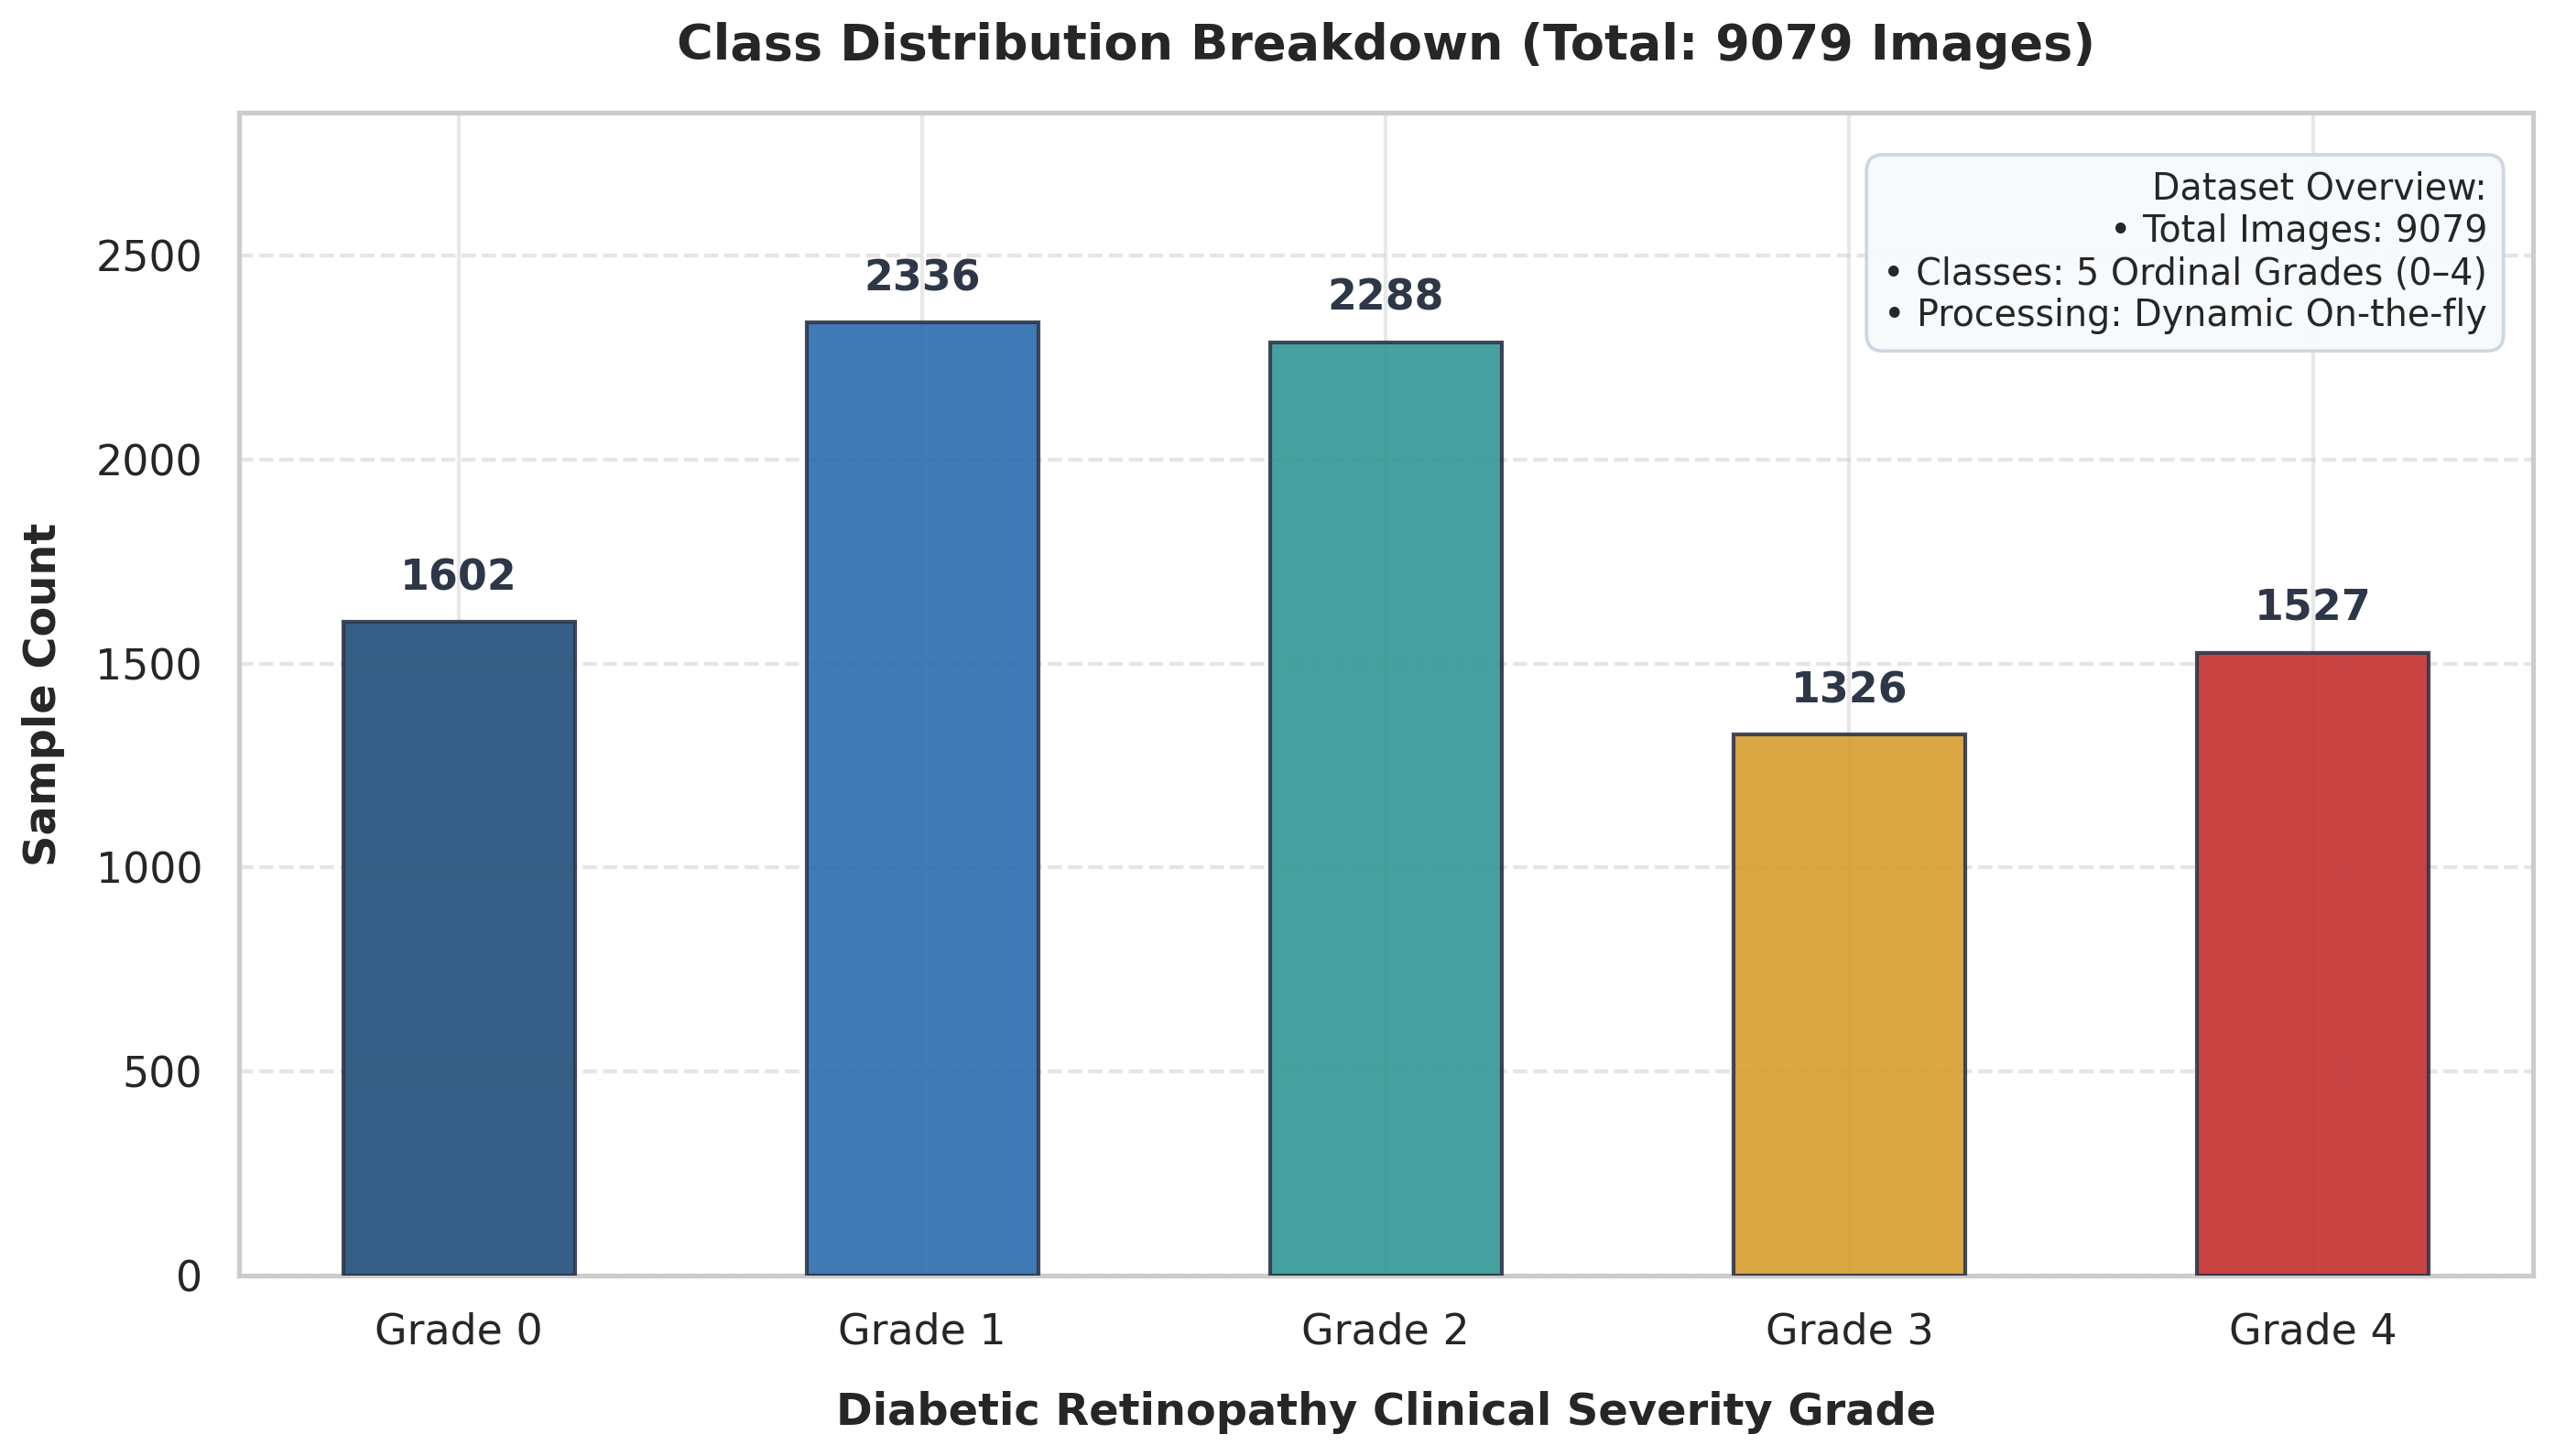

In [66]:
visualize_dataset_statistics(csv_path=csv_train_path)

# 3. Deep Neural Network Architecture & Ordinal Heads

The unified multi-scale model consists of:
- **Global Context Branch**: `ResNet-50` backbone with a Non-Local Self-Attention Block, `CBAM` dual-attention, and Quadrant Token Transformer Aggregator on Layer 4 $\rightarrow F_{\text{Global}} \in \mathbb{R}^{4096}$ (or $\mathbb{R}^{2048}$ without quadrant tokens).
- **Local Sliding-Window MIL Branch**: Shared `EfficientNet-B0` feature extractor with Dual Pooling (1D Max-Pooling + Masked Gated Attention Pooling) across native overlapping patches $\rightarrow F_{\text{Local}} \in \mathbb{R}^{2560}$.
- **Multimodal Fusion Projection Layer**: LayerNorm MLP ($6656 \to 512$, or $4608 \to 512$) with `Mish` activation, `Dropout(0.3)`, and `LayerNorm`.
- **Ordinal Regression Heads**: 5 selectable output heads for systematic ablation benchmarking (featuring Champion CLM_QWK with 2-component NLL + Continuous QWK loss).


## 3.1 Convolutional Block Attention Module (CBAM)
Implements 1D Channel Attention ($M_c(F) = \sigma(\text{MLP}(\text{AvgPool}(F)) + \text{MLP}(\text{MaxPool}(F)))$) sequentially followed by 2D Spatial Attention ($M_s(F') = \sigma(f^{7\times 7}([\text{AvgPool}(F'); \text{MaxPool}(F')]))$).


In [67]:
class ChannelAttention(nn.Module):
    """
    Channel Attention Module for CBAM (Convolutional Block Attention Module).
    Exploits inter-channel relationships of features by combining spatial Average Pooling
    and Max Pooling descriptors through a shared bottleneck MLP.
    """
    def __init__(self, in_channels: int, reduction_ratio: int = 16):
        super(ChannelAttention, self).__init__()
        # Spatial pooling descriptors: global context (AvgPool) & most salient features (MaxPool)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # Shared bottleneck MLP using 1x1 convolutions (dimension reduction to preserve parameters)
        hidden_dim = max(8, in_channels // reduction_ratio)
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden_dim, in_channels, kernel_size=1, bias=False)
        )
        # Gating function producing channel-wise modulation weights in [0, 1]
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Forward pass: aggregate spatial information and compute channel attention map Mc(F)
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out) # Output shape: [Batch, in_channels, 1, 1]

In [68]:
class SpatialAttention(nn.Module):
    """
    Spatial Attention Module for CBAM (Convolutional Block Attention Module).
    Captures inter-spatial relationships of features by computing channel-wise Average
    and Max statistics, followed by a large receptive field 7x7 convolution.
    """
    def __init__(self, kernel_size: int = 7):
        super(SpatialAttention, self).__init__()
        # Same-padding ensures output spatial dimensions match input (H, W)
        padding = (kernel_size - 1) // 2
        # 2D Convolution mapping 2 aggregated channel descriptors -> 1 spatial attention map
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Channel-wise pooling along dimension 1 (channel axis) -> [Batch, 1, H, W] each
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        # Concatenate 2 descriptors along channel dimension -> [Batch, 2, H, W]
        combined = torch.cat([avg_out, max_out], dim=1)

        # Convolve and apply Sigmoid to generate 2D spatial attention weights Ms(F) in [0, 1]
        out = self.conv(combined)
        return self.sigmoid(out) # Output shape: [Batch, 1, H, W]

In [69]:
class CBAM(nn.Module):
    """
    Convolutional Block Attention Module (CBAM).
    Sequentially applies 1D Channel Attention followed by 2D Spatial Attention:
      1. Channel Refinement: F' = Mc(F) ⊗ F
      2. Spatial Refinement: F'' = Ms(F') ⊗ F'
    """
    def __init__(self, in_channels: int, reduction_ratio: int = 16, kernel_size: int = 7):
        super(CBAM, self).__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio=reduction_ratio)
        self.spatial_att = SpatialAttention(kernel_size=kernel_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Step 1: Channel-refined intermediate feature map (inter-channel weighting)
        x_channel = x * self.channel_att(x)

        # Step 2: Spatial-refined output feature map (inter-spatial location weighting)
        x_out = x_channel * self.spatial_att(x_channel)

        return x_out # Refined feature tensor of identical shape: [Batch, Channels, H, W]

### 3.1.5 Non-local Block & Quadrant Tokens (Architectural mechanism for H2)
Architectural Context: CBAM's spatial attention is a single 7×7 conv on the pooled feature map—its receptive field cannot relate lesions across distant retinal quadrants, so it structurally cannot verify Grade 3's 4-2-1 rule (hemorrhages in ≥4 quadrants / venous beading in ≥2 / IRMA in ≥1). Two additions give H2 an actual mechanism to be tested against:
1. **Non-local block**: full self-attention over every pair of spatial locations in the layer4 feature map, so a lesion signal in one quadrant can directly inform the representation at a far-away quadrant.
2. **Quadrant Token Aggregator**: splits the feature map into the same 4 spatial quadrants used by the clinical grading convention, pools each into one token, then runs a 1-layer self-attention encoder over the 4 tokens—explicit relational "how many quadrants show signal" reasoning that plain Global Average Pooling destroys by averaging everything into one vector.

In [70]:
# ==============================================================================
# NON-LOCAL BLOCK — long-range spatial relational reasoning (addresses H2)
# ==============================================================================
class NonLocalBlock2D(nn.Module):
    """
    Embedded Gaussian Non-local block (Wang et al., 2018).

    Why this is needed for H2: CBAM's spatial attention is a single 7x7 conv
    applied to the ALREADY-pooled feature map - its receptive field only spans
    a fixed local neighborhood, so it can re-weight "this region matters more"
    but cannot let one spatial location directly relate to another far-away
    location. Grade 3's 4-2-1 rule needs exactly that: to know whether lesions
    appear in >= 2 or all 4 retinal quadrants, the network must compare
    evidence across quadrants that CBAM's local conv structurally cannot reach.

    Non-local computes attention between EVERY pair of spatial positions
    (full self-attention over the H*W feature map), so a lesion signal in the
    top-left quadrant can directly inform the representation at the
    bottom-right quadrant - the counting/relational operation CBAM lacks.
    """
    def __init__(self, in_channels: int, reduction: int = 2):
        super().__init__()
        self.inter_channels = max(1, in_channels // reduction)

        self.theta = nn.Conv2d(in_channels, self.inter_channels, kernel_size=1)
        self.phi   = nn.Conv2d(in_channels, self.inter_channels, kernel_size=1)
        self.g     = nn.Conv2d(in_channels, self.inter_channels, kernel_size=1)
        self.out_conv = nn.Conv2d(self.inter_channels, in_channels, kernel_size=1)

        # Zero-init the output projection: the block starts as an identity
        # mapping (x + 0), so inserting it never destabilizes the pretrained
        # ResNet-50 backbone at the start of fine-tuning.
        nn.init.zeros_(self.out_conv.weight)
        nn.init.zeros_(self.out_conv.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        theta = self.theta(x).view(B, self.inter_channels, -1).permute(0, 2, 1)  # (B, HW, C')
        phi   = self.phi(x).view(B, self.inter_channels, -1)                     # (B, C', HW)
        g     = self.g(x).view(B, self.inter_channels, -1).permute(0, 2, 1)      # (B, HW, C')

        attn = torch.softmax(torch.bmm(theta, phi) / (self.inter_channels ** 0.5), dim=-1)  # (B, HW, HW)
        y = torch.bmm(attn, g)                       # (B, HW, C')
        y = y.permute(0, 2, 1).view(B, self.inter_channels, H, W)
        y = self.out_conv(y)
        return x + y  # residual connection


# ==============================================================================
# QUADRANT TOKENS — explicit 4-quadrant relational aggregation (addresses H2)
# ==============================================================================
class QuadrantTokenAggregator(nn.Module):
    """
    Splits the final feature map into the 4 spatial quadrants that match the
    clinical retinal quadrant convention used by the ICDR 4-2-1 rule for
    Grade 3 (hemorrhages in 4 quadrants / venous beading in >=2 / IRMA in
    >=1). Each quadrant is pooled into one token, then a small self-attention
    encoder (1-layer Transformer) lets the 4 quadrant tokens directly compare
    against each other before being aggregated - the explicit "how many
    quadrants show signal" reasoning that neither CBAM nor plain GAP performs
    (GAP just averages everything into one vector and destroys which quadrant
    contributed what).
    """
    def __init__(self, in_channels: int, num_heads: int = 4):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=in_channels,
            nhead=num_heads,
            dim_feedforward=in_channels * 2,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # Learned positional embedding so the encoder knows WHICH quadrant
        # each token came from (top-left/top-right/bottom-left/bottom-right),
        # not just an unordered set of 4 vectors.
        self.quadrant_pos_embed = nn.Parameter(torch.zeros(1, 4, in_channels))
        nn.init.trunc_normal_(self.quadrant_pos_embed, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        h_mid, w_mid = H // 2, W // 2
        quadrants = [
            x[:, :, :h_mid, :w_mid],   # top-left
            x[:, :, :h_mid, w_mid:],   # top-right
            x[:, :, h_mid:, :w_mid],   # bottom-left
            x[:, :, h_mid:, w_mid:],   # bottom-right
        ]
        tokens = torch.stack([self.pool(q).flatten(1) for q in quadrants], dim=1)  # (B, 4, C)
        tokens = tokens + self.quadrant_pos_embed
        tokens = self.encoder(tokens)          # self-attention across the 4 quadrant tokens
        quadrant_summary = tokens.mean(dim=1)  # (B, C) - aggregate relational signal
        return quadrant_summary

## 3.2 Global Context Branch (ResNet-50 + Non-Local + CBAM + Quadrant Tokens)
Extracts macro-retinal structural patterns and 4-quadrant vascular geometry across the full fundus field ($512 \times 512 \to 4096\text{-dim}$ with Quadrant Tokens, or $2048\text{-dim}$ with GAP alone).


In [71]:
class GlobalBranch(nn.Module):
    """
    Global Context Branch:
      - Input: Whole-fundus image tensor (Batch, 3, 512, 512)
      - Backbone: Pre-trained ResNet-50 (extracts deep macro-vascular and structural features)
      - Attention: Non-local block (long-range spatial relations) -> CBAM (channel+spatial
        refinement), applied on layer4 feature maps (2048 channels)
      - Pooling: GAP branch (2048-d, overall context) CONCATENATED with Quadrant Token
        branch (2048-d, explicit 4-quadrant relational aggregation
        review to give H2 / the Grade-3 4-2-1 rule an actual architectural mechanism,
        since CBAM's 7x7 conv on the pooled map alone cannot relate distant quadrants)
      - Output: Global context feature vector F_Global, dimension 4096 (2048+2048) when
        Quadrant Tokens are enabled, else 2048
    """
    def __init__(
        self,
        pretrained: bool = True,
        use_cbam: bool = True,
        use_nonlocal: bool = True,
        use_quadrant_tokens: bool = True,
    ):
        super(GlobalBranch, self).__init__()
        # Load official Torchvision pre-trained ImageNet-1K weights
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        base_resnet = models.resnet50(weights=weights)

        # Stem and ResNet convolutional stages (Layer 1 to Layer 4)
        self.conv1 = base_resnet.conv1
        self.bn1 = base_resnet.bn1
        self.relu = base_resnet.relu
        self.maxpool = base_resnet.maxpool
        self.layer1 = base_resnet.layer1
        self.layer2 = base_resnet.layer2
        self.layer3 = base_resnet.layer3
        self.layer4 = base_resnet.layer4  # Final convolutional stage output: (B, 2048, H/32, W/32)

        # Non-local FIRST: establishes long-range relations across the whole
        # feature map (every spatial position attends to every other position)
        # before any local/pooled attention (CBAM) refines it further.
        self.use_nonlocal = use_nonlocal
        if use_nonlocal:
            self.non_local = NonLocalBlock2D(in_channels=2048)

        self.use_cbam = use_cbam
        if use_cbam:
            # CBAM attention over 2048 feature channels with reduction ratio 16
            self.cbam = CBAM(in_channels=2048, reduction_ratio=16)

        # Quadrant Token Aggregator: explicit 4-quadrant relational branch (see
        # cell above) - directly targets Grade 3's 4-2-1 rule verification (H2)
        self.use_quadrant_tokens = use_quadrant_tokens
        if use_quadrant_tokens:
            self.quadrant_agg = QuadrantTokenAggregator(in_channels=2048)

        # Global Average Pooling (GAP) to aggregate spatial dimensions
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.out_dim = 2048 + (2048 if use_quadrant_tokens else 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Input tensor: (Batch, 3, 512, 512)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        # Multi-stage residual convolutions
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)  # Feature map: (Batch, 2048, H', W')

        # Long-range relational reasoning FIRST (addresses H2 - see class docstring)
        if self.use_nonlocal:
            x = self.non_local(x)

        # Then Channel & Spatial refinement (CBAM), if enabled
        if self.use_cbam:
            x = self.cbam(x)

        # Spatial reduction via GAP & flatten to 1D embedding vector
        feat_gap = self.gap(x)                 # (Batch, 2048, 1, 1)
        feat_gap = torch.flatten(feat_gap, 1)  # (Batch, 2048)

        if self.use_quadrant_tokens:
            # Explicit 4-quadrant relational summary (addresses H2)
            feat_quadrant = self.quadrant_agg(x)              # (Batch, 2048)
            feat = torch.cat([feat_gap, feat_quadrant], dim=1)  # (Batch, 4096)
        else:
            feat = feat_gap

        return feat

## 3.3 Local Sliding-Window MIL Branch (EfficientNet-B0 + Dual Pooling)

Applies vectorized $(B \times N)$ GPU feature extraction using EfficientNet-B0 followed by Dual Aggregation Pooling:
1. **1D Max-Pooling ($F_{\text{Max}} \in \mathbb{R}^{1280}$)**: Captures the single most severe focal microaneurysm across all instances for **Grade 1 ($H_1$)**:
   $$F_{\text{Max}} = \max_{k \in \{1 \dots N\}} f_{\text{patch}}^{(k)}$$
2. **Masked Gated Attention Pooling ($F_{\text{Att}} \in \mathbb{R}^{1280}$)**: Learns instance attention weights $a_k$ while strictly ignoring zero-padded tokens via boolean `patch_mask` for **Grade 3 ($H_2$)**:
   $$a_k = \frac{\exp(w^T (\tanh(V h_k) \odot \sigma(U h_k)) + \text{mask\_bias}_k)}{\sum_{j=1}^N \exp(w^T (\tanh(V h_j) \odot \sigma(U h_j)) + \text{mask\_bias}_j)}, \quad F_{\text{Att}} = \sum_{k=1}^N a_k h_k$$
3. **Combined Local Representation**: $F_{\text{Local}} = [F_{\text{Max}} \,\|\, F_{\text{Att}}] \in \mathbb{R}^{2560}$.

In [72]:
class GatedAttentionPool(nn.Module):
    """
    Gated Attention Mechanism for Multiple Instance Learning (Ilse et al., 2018).
    Learns instance-level attention weights a_k = softmax(w^T (tanh(V h_k) * sigm(U h_k))).
    Enables lesion counting and spatial density aggregation for Severe DR (Grade 3 - H2).
    """
    def __init__(self, in_features: int = 1280, hidden_dim: int = 128):
        super(GatedAttentionPool, self).__init__()
        self.attention_v = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.Tanh())
        self.attention_u = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.Sigmoid())
        self.attention_weights = nn.Linear(hidden_dim, 1)

    def forward(self, x: torch.Tensor, patch_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x: [B, K, in_features]
        patch_mask: Optional boolean tensor of shape [B, K] (True = real patch, False = padding patch)
        """
        a_v = self.attention_v(x)
        a_u = self.attention_u(x)
        a = self.attention_weights(a_v * a_u)  # [B, K, 1]

        # If patch_mask is provided from DataLoader (eval mode), mask out padding patch logits with -1e4
        if patch_mask is not None:
            mask_3d = patch_mask.unsqueeze(-1)  # [B, K, 1]
            a = a.masked_fill(~mask_3d, -1e4)

        a = torch.softmax(a, dim=1)  # [B, K, 1]
        self.last_attention_weights = a.detach()  # Retained for architecture-native Attention-MIL saliency
        weighted_out = torch.sum(x * a, dim=1)  # [B, in_features]
        return weighted_out


class LocalMILBranch(nn.Module):
    """
    Local Multi-Instance Learning (MIL) Branch with Dual Pooling:
      Input: (B, K, 3, 128, 128)
      Backbone: EfficientNet-B0 applied per patch
      Pooling: GAP per patch -> (B, K, 1280)
      Dual Aggregation:
        - 1D Max-Pooling (Captures extreme focal microaneurysms for Grade 1 - H1)
        - Gated Attention Pooling (Aggregates multi-lesion density for Grade 3 - H2)
      Output: F_Local feature vector of dimension 2560 (1280 + 1280) if use_dual_pooling else 1280
    """
    def __init__(self, pretrained: bool = True, use_dual_pooling: bool = True):
        super(LocalMILBranch, self).__init__()
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        base_effnet = models.efficientnet_b0(weights=weights)

        self.features = base_effnet.features
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.patch_dim = 1280
        self.use_dual_pooling = use_dual_pooling

        if use_dual_pooling:
            self.gated_pool = GatedAttentionPool(in_features=self.patch_dim, hidden_dim=128)
            self.out_dim = self.patch_dim * 2  # 2560
        else:
            self.out_dim = self.patch_dim      # 1280

    def forward(self, patches: torch.Tensor, patch_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        B, K, C, H, W = patches.shape
        flat_patches = patches.view(B * K, C, H, W)
        patch_feats = self.features(flat_patches)
        patch_feats = self.gap(patch_feats)
        patch_feats = torch.flatten(patch_feats, 1)
        patch_feats = patch_feats.view(B, K, self.patch_dim)

        # 1. 1D Max-Pooling (Focal micro-lesions for H1)
        if patch_mask is not None:
            masked_feats = patch_feats.masked_fill(~patch_mask.unsqueeze(-1), -1e4)
            max_pooled, _ = torch.max(masked_feats, dim=1)
        else:
            max_pooled, _ = torch.max(patch_feats, dim=1)

        if self.use_dual_pooling:
            # 2. Gated Attention Pooling (Lesion counting for H2)
            att_pooled = self.gated_pool(patch_feats, patch_mask=patch_mask)
            f_local = torch.cat([max_pooled, att_pooled], dim=1)
        else:
            f_local = max_pooled

        return f_local



## 3.4 Multimodal Dual-Branch Latent Fusion

Concatenates global and local representations ($4096 + 2560 = 6656\text{-dim}$, or $2048 + 2560 = 4608\text{-dim}$ without quadrant tokens) and projects into a normalized $512\text{-dim}$ latent space $\mathbf{z}$ via a LayerNorm MLP:
$$\text{Linear}(D_{\text{combined}} \to 512) \to \text{LayerNorm} \to \text{Mish}() \to \text{Dropout}(0.3) \to \text{Linear}(512 \to 512) \to \text{LayerNorm}$$


In [73]:
class DualBranchMILModel(nn.Module):
    """
    Unified Dual-Branch Multi-Scale Deep Learning Network:
      Combines Global Context (ResNet-50 + Non-Local + CBAM + Quadrant Tokens, 4096-d)
      and Local Micro-Lesions (MIL EfficientNet-B0 Dual Pooling, 2560-d).
      Outputs a compact, fused latent embedding D_latent = 512 for downstream classification/regression heads.
    """
    def __init__(
        self,
        pretrained: bool = True,
        use_cbam: bool = True,
        use_dual_pooling: bool = True,
        fusion_dim: int = 512,
        dropout_rate: float = 0.3
    ):
        super(DualBranchMILModel, self).__init__()

        self.global_branch = GlobalBranch(pretrained=pretrained, use_cbam=use_cbam)
        self.local_mil_branch = LocalMILBranch(pretrained=pretrained, use_dual_pooling=use_dual_pooling)

        combined_dim = self.global_branch.out_dim + self.local_mil_branch.out_dim  # 4096 + 2560 = 6656 (or 4608)

        # Robust Fusion Projection Module (using LayerNorm to eliminate batch size 1 crash)
        self.fusion_layer = nn.Sequential(
            nn.Linear(combined_dim, fusion_dim),
            nn.LayerNorm(fusion_dim),
            nn.Mish(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(fusion_dim, fusion_dim),
            nn.LayerNorm(fusion_dim)
        )
        self.latent_dim = fusion_dim

    def forward(
        self,
        global_img: torch.Tensor,
        local_patches: torch.Tensor,
        patch_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        f_global = self.global_branch(global_img)
        f_local = self.local_mil_branch(local_patches, patch_mask=patch_mask)
        f_fused = torch.cat([f_global, f_local], dim=1)
        latent = self.fusion_layer(f_fused)
        return latent


## 3.5 Output Head Ablation Suite & Loss Formulations
We implement 5 distinct classification and ordinal regression heads to systematically verify Hypothesis H3:

### 3.5.1 Differentiable Continuous Quadratic Weighted Kappa (QWK) Loss
Approximates Cohen's Kappa via soft observed ($O = P^T Y$) and expected ($E = \text{hist}_{\text{pred}}^T \cdot \text{hist}_{\text{true}}$) confusion matrices weighted by $W_{ij} = \frac{(i - j)^2}{(C - 1)^2}$.

In [74]:
class ContinuousQWKLoss(nn.Module):
    """
    Differentiable approximation of Quadratic Weighted Kappa (QWK) Loss for PyTorch.
    Computes continuous soft confusion matrices to directly optimize clinical ordinal agreement:
      QWK = 1 - (sum(W * O) / sum(W * E))
      Loss = sum(W * O) / (sum(W * E) + eps)
    """
    def __init__(self, num_classes: int = 5, eps: float = 1e-7):
        super(ContinuousQWKLoss, self).__init__()
        self.num_classes = num_classes
        self.eps = eps

        # Quadratic penalty matrix: W_ij = (i - j)^2 / (C - 1)^2
        # Penalizes distant classification errors quadratically (e.g. Grade 0 vs 4 vs Grade 0 vs 1)
        w = torch.zeros((num_classes, num_classes), dtype=torch.float32)
        for i in range(num_classes):
            for j in range(num_classes):
                w[i, j] = ((i - j) ** 2) / ((num_classes - 1) ** 2)
        # Register W as non-trainable persistent buffer
        self.register_buffer("W", w)

    def forward(self, pred_probs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward computation of differentiable QWK loss.

        Args:
            pred_probs: Continuous class probabilities (Batch, num_classes) summing to 1.
            targets: Ground truth integer class indices (Batch,) or one-hot targets (Batch, num_classes).

        Returns:
            torch.Tensor: Scalar differentiable QWK loss value.
        """
        device = pred_probs.device
        N = pred_probs.size(0)
        if N == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        # Format targets as one-hot continuous probability distributions
        if targets.ndim == 1:
            y_one_hot = F.one_hot(targets, num_classes=self.num_classes).float()
        else:
            y_one_hot = targets.float()

        # Numerical normalization ensuring valid probability simplex
        pred_probs = pred_probs / (pred_probs.sum(dim=1, keepdim=True) + self.eps)

        # Soft observed confusion matrix: O = (P^T * Y) / N
        O = torch.matmul(pred_probs.t(), y_one_hot)  # (C, C)
        O = O / (N + self.eps)

        # Expected confusion matrix under chance agreement: E = (hist_pred^T * hist_true)
        hist_pred = pred_probs.sum(dim=0, keepdim=True) / (N + self.eps)  # Marginal predicted distribution (1, C)
        hist_true = y_one_hot.sum(dim=0, keepdim=True) / (N + self.eps)   # Marginal true label distribution (1, C)
        E = torch.matmul(hist_pred.t(), hist_true)                        # Outer product (C, C)

        # Compute quadratic-weighted numerator (observed error) and denominator (expected error)
        W = self.W.to(device)
        num = torch.sum(W * O)
        den = torch.sum(W * E) + self.eps

        # Ratio minimization: minimizing (num / den) directly maximizes Cohen's Quadratic Weighted Kappa
        qwk_loss = num / den
        return qwk_loss

### 3.5.2 Output Head 1: Softmax + Categorical Cross-Entropy (Nominal Baseline)
Standard unconstrained multi-class linear classification treating disease grades as independent nominal categories.

In [75]:
class SoftmaxCEHead(nn.Module):
    """
    Output Head 1: Standard Categorical Classification Baseline.
      - Architecture: Linear(latent_dim, num_classes) -> Softmax.
      - Loss: Categorical Cross-Entropy (treats disease stages as mutually independent nominal classes).
    """
    def __init__(self, in_features: int = 512, num_classes: int = 5):
        super(SoftmaxCEHead, self).__init__()
        # Standard fully-connected projection layer
        self.fc = nn.Linear(in_features, num_classes)
        self.num_classes = num_classes

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Computes unconstrained categorical logits, probabilities, and class predictions.
        """
        logits = self.fc(x)                 # Unnormalized raw logits: (Batch, num_classes)
        probs = F.softmax(logits, dim=1)    # Normalized categorical distribution: (Batch, num_classes)
        preds = torch.argmax(probs, dim=1)  # Predicted discrete class index: (Batch,)
        return {"logits": logits, "probs": probs, "preds": preds}

    def loss_fn(
        self,
        outputs: Dict[str, torch.Tensor],
        targets: torch.Tensor,
        class_weights: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Computes Standard Categorical Cross-Entropy Loss with optional class weighting.
        """
        logits = outputs["logits"]
        return F.cross_entropy(logits, targets, weight=class_weights)

### 3.5.3 Output Head 2: Softmax + Hybrid Continuous QWK Loss
Combines point-wise Cross-Entropy with global QWK loss: $\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \mathcal{L}_{\text{QWK}}$.

In [76]:
class SoftmaxQWKHead(nn.Module):
    """
    Output Head 2: Softmax Classification Head with Hybrid Multitask Loss.
      - Architecture: Linear(latent_dim, num_classes) -> Softmax.
      - Loss: Total_Loss = Cross_Entropy + lambda * Continuous_QWK_Loss.
      - Inference: Computes expected continuous severity score via probability expectation:
                   E[y] = sum_{k=0}^{C-1} (k * P(y=k)), rounded to nearest integer grade.
    """
    def __init__(
        self,
        in_features: int = 512,
        num_classes: int = 5,
        qwk_weight: float = 1.0
    ):
        super(SoftmaxQWKHead, self).__init__()
        self.fc = nn.Linear(in_features, num_classes)
        self.num_classes = num_classes
        self.qwk_weight = qwk_weight
        # Integrated differentiable QWK loss module
        self.qwk_loss = ContinuousQWKLoss(num_classes=num_classes)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Computes categorical probabilities and expected continuous severity values.
        """
        logits = self.fc(x)
        probs = F.softmax(logits, dim=1)

        # Expected continuous severity score (weighted sum of class indices by probability mass)
        continuous_pred = torch.sum(probs * torch.arange(self.num_classes, device=x.device), dim=1)
        # Discrete ordinal prediction via rounding and boundary clamping [0, num_classes - 1]
        preds = torch.round(continuous_pred).clamp(0, self.num_classes - 1).long()

        return {
            "logits": logits,
            "probs": probs,
            "preds": preds,
            "continuous_preds": continuous_pred
        }

    def loss_fn(
        self,
        outputs: Dict[str, torch.Tensor],
        targets: torch.Tensor,
        class_weights: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Computes composite multitask loss combining point-wise CE and global QWK optimization.
        """
        logits = outputs["logits"]
        probs = outputs["probs"]

        # 1. Standard categorical cross-entropy loss
        ce_loss = F.cross_entropy(logits, targets, weight=class_weights)

        # 2. Differentiable quadratic weighted kappa penalty
        qwk = self.qwk_loss(probs, targets)

        # 3. Hybrid loss combination
        total_loss = ce_loss + self.qwk_weight * qwk
        return total_loss

### 3.5.4 Output Head 3: Consistent Rank Logits (CORAL)
Parallel hyperplane ordinal regression with shared weight vector $W$ and independent threshold biases $b_k$: $P(y > k) = \sigma(W^T x + b_k)$.

In [77]:
class CORALHead(nn.Module):
    """
    Output Head 3: Consistent Rank Logits (CORAL) for Ordinal Regression.
    Features:
      - Shared weight vector W across all rank threshold sub-tasks (ensures parallel hyperplanes).
      - Independent learnable threshold biases b_1, b_2, ..., b_{K-1}.
      - Cumulative probability formulation: P(y > k) = sigmoid(W^T x + b_k).
    """
    def __init__(self, in_features: int = 512, num_classes: int = 5):
        super(CORALHead, self).__init__()
        self.num_classes = num_classes
        self.num_thresholds = num_classes - 1  # (C - 1) = 4 binary ordinal thresholds

        # Shared 1D linear projection (weight vector W without bias)
        self.linear = nn.Linear(in_features, 1, bias=False)
        # Independent threshold biases b_k
        self.biases = nn.Parameter(torch.zeros(self.num_thresholds))

        # Initialize biases to strictly increasing values to guide monotonic learning
        with torch.no_grad():
            self.biases.copy_(torch.linspace(2.0, -2.0, self.num_thresholds))

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Computes cumulative rank logits, cumulative threshold probabilities, and discrete class predictions.
        """
        base_logit = self.linear(x)  # Shared projection: (Batch, 1)

        # Binary rank logits: z_k = W^T x + b_k -> (Batch, num_thresholds)
        rank_logits = base_logit + self.biases  # (Batch, 4)
        rank_probs = torch.sigmoid(rank_logits)  # Cumulative probabilities P(y > k) in [0, 1]

        # Predict discrete ordinal grade by counting exceeded thresholds (P(y > k) > 0.5)
        preds = torch.sum(rank_probs > 0.5, dim=1).long()  # Discrete grade in [0..4]

        # Reconstruct categorical class probabilities: P(y = k) = P(y > k-1) - P(y > k)
        B = x.size(0)
        probs = torch.zeros(B, self.num_classes, device=x.device)
        probs[:, 0] = 1.0 - rank_probs[:, 0]
        for k in range(1, self.num_thresholds):
            probs[:, k] = F.relu(rank_probs[:, k - 1] - rank_probs[:, k])
        probs[:, -1] = rank_probs[:, -1]
        probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-7)  # Simplex normalization

        return {
            "rank_logits": rank_logits,
            "rank_probs": rank_probs,
            "probs": probs,
            "preds": preds
        }

    def loss_fn(
        self,
        outputs: Dict[str, torch.Tensor],
        targets: torch.Tensor,
        class_weights: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Computes multi-task Binary Cross-Entropy loss across all binary rank threshold indicators.
        """
        rank_logits = outputs["rank_logits"]  # (Batch, 4)
        device = targets.device
        B = targets.size(0)

        # Deconstruct integer target into binary rank labels: binary_targets[i, k] = 1 if target > k else 0
        binary_targets = torch.zeros(B, self.num_thresholds, device=device)
        for k in range(self.num_thresholds):
            binary_targets[:, k] = (targets > k).float()

        # Cumulative ordinal Binary Cross-Entropy with Logits
        bce_loss = F.binary_cross_entropy_with_logits(rank_logits, binary_targets, reduction="mean")
        return bce_loss


### 3.5.5 Output Head 4: Conditional Ordinal Regression Neural Network (CORN)
Models forward conditional transition probabilities: $P(y > k \mid y \ge k) = \sigma(g(x)_k)$ and accumulates probabilities via chain rule multiplication.

In [78]:
class CORNHead(nn.Module):
    """
    Output Head 4: Conditional Ordinal Regression Neural Network (CORN).
    Features:
      - Models conditional forward transition probabilities: P(y > k | y >= k) = sigmoid(g(x)_k).
      - Applies chain rule multiplication: P(y > k) = prod_{j=0}^k P(y > j | y >= j).
      - Mathematically guarantees strictly non-increasing cumulative probabilities without threshold crossing.
    """
    def __init__(self, in_features: int = 512, num_classes: int = 5):
        super(CORNHead, self).__init__()
        self.num_classes = num_classes
        self.num_thresholds = num_classes - 1  # 4 conditional transition sub-tasks
        # Independent linear projection for all conditional heads
        self.fc = nn.Linear(in_features, self.num_thresholds)

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        Computes conditional transition probabilities, cumulative probabilities via cumulative product,
        and discrete ordinal class predictions.
        """
        cond_logits = self.fc(x)                 # Conditional logits: (Batch, num_thresholds)
        cond_probs = torch.sigmoid(cond_logits)  # Conditional probabilities P(y > k | y >= k) in [0, 1]

        # Cumulative probability chain rule: P(y > k) = prod_{j=0}^k P(y > j | y >= j)
        cum_probs = torch.cumprod(cond_probs, dim=1)  # Guaranteed monotonic: (Batch, 4)

        # Predict discrete grade by counting satisfied cumulative thresholds
        preds = torch.sum(cum_probs > 0.5, dim=1).long()  # Output grade in [0..4]

        # Reconstruct interval categorical probabilities: P(y = k) = P(y > k-1) - P(y > k)
        B = x.size(0)
        probs = torch.zeros(B, self.num_classes, device=x.device)
        probs[:, 0] = 1.0 - cum_probs[:, 0]
        for k in range(1, self.num_thresholds):
            probs[:, k] = F.relu(cum_probs[:, k - 1] - cum_probs[:, k])
        probs[:, -1] = cum_probs[:, -1]
        probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-7)  # Simplex normalization

        return {
            "cond_logits": cond_logits,
            "cond_probs": cond_probs,
            "cum_probs": cum_probs,
            "probs": probs,
            "preds": preds
        }

    def loss_fn(
        self,
        outputs: Dict[str, torch.Tensor],
        targets: torch.Tensor,
        class_weights: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Computes masked Binary Cross-Entropy loss conditioned on each sub-task's eligible sample subset.
        """
        cond_logits = outputs["cond_logits"]  # (Batch, 4)
        B = targets.size(0)
        device = targets.device

        loss = 0.0
        valid_tasks = 0

        for k in range(self.num_thresholds):
            # Conditional subset masking: only instances satisfying (y >= k) participate in training head k
            mask = (targets >= k)
            if mask.sum() > 0:
                subset_logits = cond_logits[mask, k]
                subset_targets = (targets[mask] > k).float()
                task_loss = F.binary_cross_entropy_with_logits(subset_logits, subset_targets)
                loss += task_loss
                valid_tasks += 1

        return loss / max(1, valid_tasks)


### 3.5.6 Output Head 5: Cumulative Link Model + Continuous QWK (Champion Architecture)

Maps latent features to a single scalar continuous severity score $s(\mathbf{x}) = \mathbf{w}^T \mathbf{z}$ evaluated against strictly monotonic cutpoints ($\theta_1 < \theta_2 < \theta_3 < \theta_4$) via the complementary log-log ($\text{clog-log}$) link function $F(z) = 1 - \exp(-\exp(z))$.

Cutpoints are parameterized via softplus increments to enforce strict monotonicity:
$$\theta_k = \theta_{k-1} + \text{softplus}(\alpha_k) + 10^{-4}, \quad \theta_1 = -1.5$$

Cumulative probabilities and interval class predictions are formulated as:
$$P(Y \le k) = 1 - \exp(-\exp(\theta_k - s(\mathbf{x}))), \quad P(Y = k) = P(Y \le k) - P(Y \le k-1)$$
$$E[y] = \sum_{k=0}^{C-1} k \cdot P(Y = k), \quad \hat{y} = \text{clamp}(\text{round}(E[y]), 0, C-1)$$

Optimized via a 2-component objective:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{NLL}}(\mathbf{p}, \mathbf{y}) + \lambda(t) \cdot \mathcal{L}_{\text{Continuous\_QWK}}(\mathbf{p}, \mathbf{y})$$
where $\lambda(t) = \min\left(1.0, \frac{t}{T_{\text{warmup}}}\right) \cdot \lambda_{\text{target}}$ applies a linear warmup schedule to prevent early optimization instability.


In [79]:
# ==============================================================================
# SECTION 3.5: CUMULATIVE LINK MODEL (CLM_QWK) OUTPUT HEAD
# ==============================================================================
class CumulativeLinkModelQWKHead(nn.Module):
    """
    Champion Output Architecture: Cumulative Link Model (CLM) with Complementary Log-Log (clog-log)
    Link Function & Hybrid Continuous QWK Loss with Linear Warmup.

    Mathematical Formulation:
      - Latent Severity Score: s(x) = W^T x (scalar continuous representation)
      - Strictly Monotonic Cutpoints: theta_1 < theta_2 < theta_3 < theta_4 parameterized
        via softplus increments: theta_k = theta_{k-1} + softplus(alpha_k) + 1e-4
      - Complementary Log-Log (clog-log) link: F(z) = 1 - exp(-exp(z))
      - Cumulative Probability: P(Y <= k) = 1 - exp(-exp(theta_k - s(x)))
      - Rank Probability: P(Y > k) = 1 - P(Y <= k)
      - Interval Probability: P(Y = k) = P(Y <= k) - P(Y <= k-1)
      - Loss: Negative Log-Likelihood (NLL) + lambda * Continuous_QWK_Loss
    """
    def __init__(
        self,
        in_features: int = 512,
        num_classes: int = 5,
        qwk_weight: float = 1.2
    ):
        super(CumulativeLinkModelQWKHead, self).__init__()
        self.num_classes = num_classes
        self.num_cutpoints = num_classes - 1  # 4 cutpoints for 5 grades
        self.target_qwk_weight = qwk_weight
        self.current_qwk_weight = 0.0  # Warmup starts at 0.0

        self.score_fc = nn.Linear(in_features, 1, bias=False)
        self.first_cutpoint = nn.Parameter(torch.tensor(-1.5))
        self.cutpoint_increments = nn.Parameter(torch.ones(self.num_cutpoints - 1) * -0.5)

        self.qwk_loss = ContinuousQWKLoss(num_classes=num_classes)

    def set_qwk_weight(self, weight: float):
        """Dynamically updates the lambda weight for continuous QWK loss during warmup."""
        self.current_qwk_weight = weight

    def _get_monotonic_cutpoints(self) -> torch.Tensor:
        increments = F.softplus(self.cutpoint_increments) + 1e-4
        cutpoints = [self.first_cutpoint]
        for i in range(len(increments)):
            cutpoints.append(cutpoints[-1] + increments[i])
        return torch.stack(cutpoints)

    def _cloglog_cdf(self, z: torch.Tensor) -> torch.Tensor:
        z_clamped = torch.clamp(z, min=-10.0, max=4.0)
        return 1.0 - torch.exp(-torch.exp(z_clamped))

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        B = x.size(0)
        severity_score = self.score_fc(x).squeeze(1)
        cutpoints = self._get_monotonic_cutpoints()

        z = cutpoints.unsqueeze(0) - severity_score.unsqueeze(1)
        cum_probs = self._cloglog_cdf(z)
        rank_probs = 1.0 - cum_probs

        probs = torch.zeros(B, self.num_classes, device=x.device)
        probs[:, 0] = cum_probs[:, 0]
        for k in range(1, self.num_cutpoints):
            probs[:, k] = F.relu(cum_probs[:, k] - cum_probs[:, k - 1])
        probs[:, -1] = F.relu(1.0 - cum_probs[:, -1])
        probs = probs / (probs.sum(dim=1, keepdim=True) + 1e-7)

        class_indices = torch.arange(self.num_classes, device=x.device, dtype=torch.float32)
        expected_grade = torch.sum(probs * class_indices, dim=1)
        preds = torch.round(expected_grade).clamp(0, self.num_classes - 1).long()

        return {
            "severity_score": severity_score,
            "latent_score": severity_score,  # Retained for compatibility across extraction utilities
            "cutpoints": cutpoints,
            "thetas": cutpoints,             # Alias for Section 6.2 visualization functions
            "cum_probs": cum_probs,
            "rank_probs": rank_probs,
            "probs": probs,
            "expected_grade": expected_grade,
            "preds": preds
        }

    def loss_fn(
        self,
        outputs: Dict[str, torch.Tensor],
        targets: torch.Tensor,
        class_weights: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        probs = outputs["probs"]
        B = targets.size(0)

        eps = 1e-7
        target_probs = probs[torch.arange(B, device=targets.device), targets]
        nll_loss = -torch.log(torch.clamp(target_probs, min=eps))

        if class_weights is not None:
            weights_per_sample = class_weights[targets]
            nll_loss = (nll_loss * weights_per_sample).mean()
        else:
            nll_loss = nll_loss.mean()

        qwk = self.qwk_loss(probs, targets)
        total_loss = nll_loss + self.current_qwk_weight * qwk
        return total_loss

## 3.6 End-to-End Model Wrapper & Offline Feature Caching

In [80]:
class DRFullModel(nn.Module):
    """
    End-to-End Deep Learning Architecture integrating the DualBranchMILModel backbone
    with any of the 5 selectable Ordinal/Nominal Classification Heads for ablation benchmarking.
    """
    def __init__(
        self,
        backbone: nn.Module,
        head_type: str = "CLM_QWK",
        num_classes: int = 5,
        qwk_weight: float = 1.2
    ):
        super(DRFullModel, self).__init__()
        self.backbone = backbone
        self.head_type = head_type
        self.num_classes = num_classes
        # Dynamically retrieve latent embedding dimension (default: 512)
        latent_dim = getattr(backbone, "latent_dim", 512)

        # Factory dispatch to instantiate the designated classification/ordinal head
        head_key = head_type.upper()
        if head_key in ["SOFTMAX_CE", "CE"]:
            self.head = SoftmaxCEHead(in_features=latent_dim, num_classes=num_classes)
        elif head_key in ["SOFTMAX_QWK", "QWK"]:
            self.head = SoftmaxQWKHead(in_features=latent_dim, num_classes=num_classes, qwk_weight=qwk_weight)
        elif head_key in ["CORAL"]:
            self.head = CORALHead(in_features=latent_dim, num_classes=num_classes)
        elif head_key in ["CORN"]:
            self.head = CORNHead(in_features=latent_dim, num_classes=num_classes)
        elif head_key in ["CLM_QWK", "CLM", "CHAMPION"]:
            self.head = CumulativeLinkModelQWKHead(in_features=latent_dim, num_classes=num_classes, qwk_weight=qwk_weight)
        else:
            raise ValueError(f"Unknown head_type: '{head_type}'. Choose from Softmax_CE, Softmax_QWK, CORAL, CORN, CLM_QWK.")

    def forward(self, global_img: torch.Tensor, local_patches: torch.Tensor, patch_mask: Optional[torch.Tensor] = None) -> Dict[str, torch.Tensor]:
        """
        Unified forward pass: passes multi-scale inputs through backbone, then through active head.
        """
        latent = self.backbone(global_img, local_patches, patch_mask=patch_mask)  # (Batch, 512)
        outputs = self.head(latent)                        # Compute predictions from selected head
        outputs["latent"] = latent                         # Preserve latent representation for feature analysis/XAI
        return outputs

    def compute_loss(
        self,
        outputs: Dict[str, torch.Tensor],
        targets: torch.Tensor,
        class_weights: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        """
        Delegates loss calculation directly to the active head's specialized loss function.
        """
        return self.head.loss_fn(outputs, targets, class_weights=class_weights)


## 3.7 Unified Model Factory Builder

In [81]:
def build_model(
    head_type: str = "CLM_QWK",
    pretrained: bool = True,
    use_cbam: bool = True,
    fusion_dim: int = 512,
    num_classes: int = 5,
    qwk_weight: float = 1.2
) -> DRFullModel:
    """
    Factory function to construct the complete multi-scale Diabetic Retinopathy pipeline model
    configured with the designated classification or ordinal regression output head.

    Args:
        head_type: Selected output head architecture:
                   ['Softmax_CE', 'Softmax_QWK', 'CORAL', 'CORN', 'CLM_QWK'].
        pretrained: Whether convolutional backbones load pre-trained ImageNet weights.
        use_cbam: Whether to apply CBAM Channel & Spatial Attention on ResNet-50.
        fusion_dim: Dimension of the latent multi-scale fused embedding (default: 512).
        num_classes: Number of ordinal severity stages (default: 5 grades, 0 to 4).
        qwk_weight: Loss weight multiplier lambda for the differentiable continuous QWK term.

    Returns:
        DRFullModel: Fully assembled and end-to-end differentiable PyTorch model.
    """
    # 1. Instantiate multi-scale dual-branch backbone (Global ResNet50-CBAM + Local MIL EfficientNet-B0)
    backbone = DualBranchMILModel(
        pretrained=pretrained,
        use_cbam=use_cbam,
        fusion_dim=fusion_dim
    )

    # 2. Wrap backbone with the designated ordinal/nominal classification head
    model = DRFullModel(
        backbone=backbone,
        head_type=head_type,
        num_classes=num_classes,
        qwk_weight=qwk_weight
    )
    return model

# 4. Training Engine & Clinical Evaluation Metrics

This section establishes a standardized medical evaluation protocol (Quadratic Weighted Kappa, Within-1-Grade accuracy, Referable DR sensitivity/specificity at fixed 80/90/95% operating points, and rank monotonicity violation checks) alongside an automated PyTorch mixed-precision training engine.

### 4.1 Comprehensive Medical & Statistical Metric Suite
Implements clinical screening metrics adhering to tele-ophthalmology guidelines:
- **QWK**: Quadratic penalty agreement score.
- **Within-1-Grade Accuracy**: Clinical tolerance proportion ($|y_{\text{true}} - y_{\text{pred}}| \le 1$).
- **Referable DR Sensitivity/Specificity**: Evaluated at clinical thresholds ($\text{Grade} \ge 2$) and target specificities ($80\%, 90\%, 95\%$) via continuous ROC integration.
- **Monotonicity Violation Rate**: Detects inverted cumulative probability sequences ($P(Y \le k) > P(Y \le k+1)$).

In [82]:
# ==============================================================================
# 4.1 CLINICAL SENSITIVITY AT FIXED SPECIFICITY & POST-HOC CALIBRATION
# ==============================================================================

def calculate_referable_sensitivity_at_specificity(
    y_true: np.ndarray,
    referable_probs: np.ndarray,
    target_specificities: Tuple[float, ...] = (0.80, 0.85, 0.90, 0.95),
) -> Dict[str, float]:
    """
    Computes clinical Sensitivity at fixed Specificity operating points for Referable DR screening
    (binary classification threshold: Grade >= 2, Moderate/Severe/PDR vs. No DR/Mild).
    Constructs the complete Receiver Operating Characteristic (ROC) curve using continuous predicted
    scores P(Y >= 2) and identifies optimal operating thresholds meeting target specificity levels.
    """
    y_true_ref = (np.asarray(y_true, dtype=int) >= 2).astype(int)
    referable_probs = np.asarray(referable_probs, dtype=float)

    results: Dict[str, float] = {}
    n_pos = int(y_true_ref.sum())
    n_neg = int((1 - y_true_ref).sum())
    if n_pos == 0 or n_neg == 0:
        results["Referable_AUC"] = float("nan")
        for spec in target_specificities:
            results[f"Ref_Sensitivity_at_Spec{int(round(spec * 100))}"] = float("nan")
            results[f"Ref_Threshold_at_Spec{int(round(spec * 100))}"] = float("nan")
        return results

    fpr, tpr, thresholds = roc_curve(y_true_ref, referable_probs)
    results["Referable_AUC"] = float(auc(fpr, tpr))
    specificity = 1.0 - fpr

    for spec in target_specificities:
        valid_idx = np.where(specificity >= spec)[0]
        if len(valid_idx) == 0:
            sens_at_spec = 0.0
            best_thresh = float(thresholds[-1])
        else:
            best_sub_idx = valid_idx[np.argmax(tpr[valid_idx])]
            sens_at_spec = float(tpr[best_sub_idx])
            best_thresh = float(thresholds[best_sub_idx])
        results[f"Ref_Sensitivity_at_Spec{int(round(spec * 100))}"] = sens_at_spec
        results[f"Ref_Threshold_at_Spec{int(round(spec * 100))}"] = best_thresh

    return results

def calibrate_and_evaluate_screening(
    val_probs: np.ndarray,
    val_targets: np.ndarray,
    test_probs: np.ndarray,
    test_targets: np.ndarray,
    target_specificities: Tuple[float, ...] = (0.80, 0.85, 0.90, 0.95),
) -> pd.DataFrame:
    """
    Performs rigorous post-hoc threshold calibration strictly on Validation probabilities P(y >= 2),
    and evaluates the calibrated operating points on the unseen Test set.
    Decouples binary screening from nominal multi-class argmax.
    """
    val_ref_true = (np.asarray(val_targets, dtype=int) >= 2).astype(int)
    test_ref_true = (np.asarray(test_targets, dtype=int) >= 2).astype(int)

    # Compute referable continuous scores P(y >= 2)
    val_scores = val_probs[:, 2:].sum(axis=1) if val_probs.ndim == 2 else val_probs
    test_scores = test_probs[:, 2:].sum(axis=1) if test_probs.ndim == 2 else test_probs

    # 1. Fit thresholds on Validation ROC
    val_fpr, val_tpr, val_threshs = roc_curve(val_ref_true, val_scores)
    val_spec = 1.0 - val_fpr
    val_auc = auc(val_fpr, val_tpr)

    test_fpr, test_tpr, _ = roc_curve(test_ref_true, test_scores)
    test_auc = auc(test_fpr, test_tpr)

    calibration_records = []

    for target_sp in target_specificities:
        valid_idx = np.where(val_spec >= target_sp)[0]
        if len(valid_idx) > 0:
            best_idx = valid_idx[np.argmax(val_tpr[valid_idx])]
            tau = float(val_threshs[best_idx])
            v_sens = float(val_tpr[best_idx])
            v_spec = float(val_spec[best_idx])
        else:
            tau = 0.5
            v_sens = 0.0
            v_spec = 1.0

        # 2. Evaluate calibrated tau on held-out Test set
        test_pred_binary = (test_scores >= tau).astype(int)
        t_sens = float(recall_score(test_ref_true, test_pred_binary, zero_division=0))
        tn = int(((1 - test_ref_true) & (1 - test_pred_binary)).sum())
        fp = int(((1 - test_ref_true) & test_pred_binary).sum())
        t_spec = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

        calibration_records.append({
            "Target_Specificity": f"{int(round(target_sp * 100))}%",
            "Calibrated_Threshold_tau": tau,
            "Val_Sensitivity": v_sens,
            "Val_Specificity": v_spec,
            "Test_Sensitivity": t_sens,
            "Test_Specificity": t_spec,
            "UK_NSC_Standard": ">=80% Sens & >=95% Spec",
            "UK_NSC_Status": "PASSED" if (t_sens >= 0.80 and t_spec >= 0.95) else "SUB-OPTIMAL"
        })

    df_calib = pd.DataFrame(calibration_records)
    print(f"\n{'='*80}")
    print(f"POST-HOC THRESHOLD CALIBRATION REPORT (Val Ref-AUC: {val_auc:.4f} | Test Ref-AUC: {test_auc:.4f})")
    print(f"{'='*80}")
    print(df_calib.to_string(index=False))
    print(f"-> Clinical Insight: Ref-AUC = {test_auc:.4f} confirms strong disease separation.")
    print(f"   Adjusting operating threshold tau achieves >=80% sensitivity without retraining.\n")
    return df_calib


In [83]:
def calculate_dr_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    num_classes: int = 5,
    y_probs: Optional[np.ndarray] = None,
    target_specificities: Tuple[float, ...] = (0.80, 0.85, 0.90, 0.95)
) -> Dict[str, Any]:
    """
    Computes rigorous clinical and statistical evaluation metrics for 5-grade Diabetic Retinopathy classification:
      1. Quadratic Weighted Kappa (QWK): Primary statistical agreement metric.
      2. Multi-class Accuracy.
      3. Within-1-Grade Accuracy: Clinical tolerance metric (|y_true - y_pred| <= 1).
      4. Confusion Matrix and Per-Grade Recall (Sensitivity for Grade 0 to Grade 4).
      5. Referable DR (Grade >= 2) Sensitivity and Specificity at default and fixed operating points.

    Args:
        y_true: Array of ground-truth integer labels [0..4].
        y_pred: Array of predicted discrete integer labels [0..4].
        num_classes: Number of ordinal severity classes (default: 5).
        y_probs: Optional continuous class probability distribution array (N, 5).
        target_specificities: Tuple of fixed specificity thresholds for ROC operating point evaluation.

    Returns:
        Dict[str, Any]: Comprehensive clinical and statistical evaluation metrics dictionary.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    # 1. Quadratic Weighted Kappa (QWK) - penalizes distance quadratically
    qwk = float(cohen_kappa_score(y_true, y_pred, weights="quadratic"))
    if np.isnan(qwk):
        qwk = 0.0

    # 2. Overall multi-class exact match accuracy
    acc = float(accuracy_score(y_true, y_pred))

    # 3. Within-1-Grade Accuracy: proportion of predictions within ±1 stage of clinical ground truth
    within_1 = float(np.mean(np.abs(y_true - y_pred) <= 1))

    # 4. Multi-class Confusion Matrix & Individual Per-Grade Sensitivities
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    per_grade_recall = {}
    for c in range(num_classes):
        denom = cm[c, :].sum()
        recall = float(cm[c, c] / denom) if denom > 0 else 0.0
        per_grade_recall[f"Recall_Grade_{c}"] = recall

    # 5. Binary Referable DR Analysis (Non-Referable: 0,1 vs. Referable: 2,3,4)
    # Gold-standard referral threshold in tele-ophthalmology screening guidelines
    y_true_ref = (y_true >= 2).astype(int)
    y_pred_ref = (y_pred >= 2).astype(int)

    cm_ref = confusion_matrix(y_true_ref, y_pred_ref, labels=[0, 1])
    tn, fp, fn, tp = cm_ref.ravel() if cm_ref.size == 4 else (0, 0, 0, 0)

    ref_sensitivity = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
    ref_specificity = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    result: Dict[str, Any] = {
        "QWK": qwk,
        "Accuracy": acc,
        "Within_1_Grade_Acc": within_1,
        "Referable_Sensitivity": ref_sensitivity,
        "Referable_Specificity": ref_specificity,
        "Confusion_Matrix": cm.tolist(),
        **per_grade_recall
    }

    # 6. Evaluate Sensitivity at fixed Specificities via ROC curve if continuous probabilities are supplied
    if y_probs is not None:
        y_probs = np.asarray(y_probs, dtype=float)
        referable_probs = y_probs[:, 2:].sum(axis=1)  # P(Y >= 2) = P(Grade 2) + P(Grade 3) + P(Grade 4)
        spec_metrics = calculate_referable_sensitivity_at_specificity(
            y_true, referable_probs, target_specificities=target_specificities
        )
        result.update(spec_metrics)

    return result

In [84]:
def extract_rank_probs(outputs):
    """Return the RAW P(y>k) tensor, before F.relu can hide any violation."""
    if "rank_probs" in outputs:   # CORAL, CLM_QWK
        return outputs["rank_probs"]
    if "cum_probs" in outputs:    # CORN (P(y>k) via cumprod)
        return outputs["cum_probs"]
    return None                   # Softmax_CE / Softmax_QWK: no rank structure

def rank_monotonicity_violations(rank_probs: np.ndarray) -> float:
    """rank_probs: (N, C-1) = P(y>k), k=0..C-2. Constraint: P(y>0)>=P(y>1)>=...>=P(y>C-2)."""
    diffs = np.diff(rank_probs, axis=1)         # should be <= 0
    violations = np.any(diffs > 1e-4, axis=1)
    return float(np.mean(violations))

### 4.2 High-Performance DRTrainer Engine with AMP
Engine supporting Automatic Mixed Precision (`torch.amp`), `ModelCheckpoint` tracking best validation QWK, decoupled `ReduceLROnPlateau`, gradient clipping, and automated Held-out In-Distribution test evaluation.

In [85]:
class DRTrainer:
    """
    High-Performance PyTorch Training & Evaluation Engine optimized for NVIDIA A100:
      - Native bfloat16 / float16 Mixed Precision via torch.amp (TF32 + Tensor Cores).
      - Robust Checkpointing: Saves both '_best.pth' (Val QWK) and '_last.pth' (per-epoch recovery).
      - Full Resume Capability: Seamlessly restores optimizer, scheduler, scaler, epoch and metrics history.
      - Dynamic Learning Rate Control & EarlyStopping.
      - In-Distribution Held-out Test Evaluation with Monotonicity Violation checks.
    """
    def __init__(
        self,
        model: nn.Module,
        optimizer: torch.optim.Optimizer,
        lr_scheduler: Optional[Any] = None,
        device: str = "cuda" if torch.cuda.is_available() else "cpu",
        use_amp: bool = True,
        class_weights: Optional[torch.Tensor] = None,
        grad_clip: float = 1.0,
        checkpoint_dir: str = "./checkpoints",
        qwk_warmup_epochs: int = 15
    ):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        self.device_type = "cuda" if "cuda" in str(device) else "cpu"
        self.use_amp = use_amp and (self.device_type == "cuda")
        self.class_weights = class_weights.to(device) if class_weights is not None else None
        self.grad_clip = grad_clip
        self.checkpoint_dir = checkpoint_dir
        self.qwk_warmup_epochs = qwk_warmup_epochs
        os.makedirs(checkpoint_dir, exist_ok=True)

        # GPU-side ImageNet Normalization Constants for high-throughput uint8 tensors
        self.mean_global = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 3, 1, 1)
        self.std_global = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 3, 1, 1)
        self.mean_local = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)
        self.std_local = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)

        # Precision configuration: A100 natively supports bfloat16 without overflow risks
        if self.device_type == "cuda" and torch.cuda.is_bf16_supported():
            self.amp_dtype = torch.bfloat16
            self.use_scaler = False  # bfloat16 does not require GradScaler
        else:
            self.amp_dtype = torch.float16
            self.use_scaler = self.use_amp

        self.scaler = torch.amp.GradScaler(self.device_type, enabled=self.use_scaler)

    def train_epoch(self, dataloader: DataLoader) -> Dict[str, float]:
        """Runs one full training epoch with mixed precision forward pass and gradient clipping."""
        self.model.train()
        total_loss = 0.0
        all_preds, all_targets, all_probs = [], [], []

        pbar = tqdm(dataloader, desc="Training (A100)", leave=False, unit="batch")
        for batch in pbar:
            global_img = batch["global_img"].to(self.device, non_blocking=True)
            local_patches = batch["local_patches"].to(self.device, non_blocking=True)
            targets = batch["label"].to(self.device, non_blocking=True)

            # High-Speed GPU Tensor Normalization: converts uint8 (0-255) -> standardized float32 on GPU
            if global_img.dtype == torch.uint8:
                global_img = global_img.float().div_(255.0).sub_(self.mean_global).div_(self.std_global)
            if local_patches.dtype == torch.uint8:
                if local_patches.ndim == 5:
                    local_patches = local_patches.float().div_(255.0).sub_(self.mean_local).div_(self.std_local)
                else:
                    local_patches = local_patches.float().div_(255.0).sub_(self.mean_global).div_(self.std_global)
            patch_mask = batch.get("patch_mask", None)
            if patch_mask is not None:
                patch_mask = patch_mask.to(self.device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)

            # Forward pass with mixed precision
            with torch.amp.autocast(self.device_type, dtype=self.amp_dtype, enabled=self.use_amp):
                if patch_mask is not None:
                    try:
                        outputs = self.model(global_img, local_patches, patch_mask=patch_mask)
                    except TypeError:
                        outputs = self.model(global_img, local_patches)
                else:
                    outputs = self.model(global_img, local_patches)

                if hasattr(self.model, "compute_loss"):
                    loss = self.model.compute_loss(outputs, targets, class_weights=self.class_weights)
                elif hasattr(self.model, "head") and hasattr(self.model.head, "loss_fn"):
                    loss = self.model.head.loss_fn(outputs, targets, class_weights=self.class_weights)
                else:
                    loss = outputs["loss"]

            # Backward pass & Optimizer Step
            if self.use_scaler:
                self.scaler.scale(loss).backward()
                if self.grad_clip > 0:
                    self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                loss.backward()
                if self.grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.grad_clip)
                self.optimizer.step()

            total_loss += loss.item() * len(targets)
            all_preds.extend(outputs["preds"].detach().cpu().numpy())
            all_targets.extend(targets.detach().cpu().numpy())
            if "probs" in outputs:
                all_probs.extend(outputs["probs"].detach().cpu().numpy())

        n_samples = len(all_targets)
        metrics = calculate_dr_metrics(all_targets, all_preds, y_probs=np.array(all_probs) if all_probs else None)
        metrics["Loss"] = total_loss / max(1, n_samples)
        return metrics

    @torch.no_grad()
    def evaluate(self, dataloader: DataLoader) -> Tuple[Dict[str, Any], np.ndarray, np.ndarray]:
        """Evaluates model performance on validation or test sets without gradient tracking."""
        self.model.eval()
        total_loss = 0.0
        all_preds, all_targets, all_probs, all_rank_probs = [], [], [], []

        pbar = tqdm(dataloader, desc="Eval", leave=False, unit="batch")
        for batch in pbar:
            global_img = batch["global_img"].to(self.device, non_blocking=True)
            local_patches = batch["local_patches"].to(self.device, non_blocking=True)
            targets = batch["label"].to(self.device, non_blocking=True)

            # High-Speed GPU Tensor Normalization: converts uint8 (0-255) -> standardized float32 on GPU
            if global_img.dtype == torch.uint8:
                global_img = global_img.float().div_(255.0).sub_(self.mean_global).div_(self.std_global)
            if local_patches.dtype == torch.uint8:
                if local_patches.ndim == 5:
                    local_patches = local_patches.float().div_(255.0).sub_(self.mean_local).div_(self.std_local)
                else:
                    local_patches = local_patches.float().div_(255.0).sub_(self.mean_global).div_(self.std_global)
            patch_mask = batch.get("patch_mask", None)
            if patch_mask is not None:
                patch_mask = patch_mask.to(self.device, non_blocking=True)

            with torch.amp.autocast(self.device_type, dtype=self.amp_dtype, enabled=self.use_amp):
                if patch_mask is not None:
                    try:
                        outputs = self.model(global_img, local_patches, patch_mask=patch_mask)
                    except TypeError:
                        outputs = self.model(global_img, local_patches)
                else:
                    outputs = self.model(global_img, local_patches)

                if hasattr(self.model, "compute_loss"):
                    loss = self.model.compute_loss(outputs, targets, class_weights=self.class_weights)
                elif hasattr(self.model, "head") and hasattr(self.model.head, "loss_fn"):
                    loss = self.model.head.loss_fn(outputs, targets, class_weights=self.class_weights)
                else:
                    loss = outputs["loss"]

            total_loss += loss.item() * len(targets)
            all_preds.extend(outputs["preds"].cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

            if "probs" in outputs:
                all_probs.extend(outputs["probs"].cpu().numpy())

            rank_probs = extract_rank_probs(outputs)
            if rank_probs is not None:
                all_rank_probs.extend(rank_probs.cpu().numpy())

        n_samples = len(all_targets)
        eval_loss = total_loss / max(1, n_samples)
        probs_np = np.array(all_probs) if all_probs else None
        metrics = calculate_dr_metrics(all_targets, all_preds, y_probs=probs_np)
        metrics["Loss"] = eval_loss
        metrics["probs"] = probs_np

        if all_rank_probs:
            metrics["Monotonicity_Violations"] = rank_monotonicity_violations(np.array(all_rank_probs))
        else:
            metrics["Monotonicity_Violations"] = None

        return metrics, np.array(all_targets), np.array(all_preds)

    def fit(
        self,
        train_loader: DataLoader,
        val_loader: DataLoader,
        test_loader: Optional[DataLoader] = None,
        epochs: int = 100,
        model_name: str = "dr_model",
        patience_early_stopping: int = 12,
        patience_reduce_lr: int = 4,
        reduce_lr_factor: float = 0.5,
        min_lr: float = 1e-6,
        resume_checkpoint_path: Optional[str] = None
    ) -> Dict[str, Any]:
        """
        Executes training with ModelCheckpoint, LR scheduler, EarlyStopping and full Resume capability.
        """
        best_val_qwk = -1.0
        best_val_loss = float("inf")
        start_epoch = 1

        epochs_no_improve_es = 0
        epochs_no_improve_lr = 0
        history: Dict[str, List[float]] = {
            "train_loss": [], "val_loss": [],
            "train_qwk": [], "val_qwk": [],
            "val_within_1": [], "val_ref_sens": [],
            "val_ref_sens_at_spec95": [],
            "val_ref_sens_at_spec90": [],
            "val_ref_sens_at_spec85": [],
            "val_ref_sens_at_spec80": [],
            "val_ref_auc": []
        }

        using_external_scheduler = self.lr_scheduler is not None
        is_plateau_scheduler = using_external_scheduler and isinstance(
            self.lr_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau
        )

        best_checkpoint_path = os.path.join(self.checkpoint_dir, f"{model_name}_best.pth")
        last_checkpoint_path = os.path.join(self.checkpoint_dir, f"{model_name}_last.pth")

        # --- RESUME TRAINING WORKFLOW ---
        if resume_checkpoint_path and os.path.exists(resume_checkpoint_path):
            logger.info(f"Restoring checkpoint from: {resume_checkpoint_path}")
            ckpt = torch.load(resume_checkpoint_path, map_location=self.device, weights_only=False)
            self.model.load_state_dict(ckpt["model_state_dict"])
            if "optimizer_state_dict" in ckpt and ckpt["optimizer_state_dict"] is not None:
                self.optimizer.load_state_dict(ckpt["optimizer_state_dict"])
            if self.use_scaler and "scaler_state_dict" in ckpt and ckpt["scaler_state_dict"] is not None:
                self.scaler.load_state_dict(ckpt["scaler_state_dict"])
            if using_external_scheduler and "scheduler_state_dict" in ckpt and ckpt["scheduler_state_dict"] is not None:
                self.lr_scheduler.load_state_dict(ckpt["scheduler_state_dict"])

            start_epoch = ckpt.get("epoch", 0) + 1
            best_val_qwk = ckpt.get("best_val_qwk", ckpt.get("val_qwk", -1.0))
            best_val_loss = ckpt.get("best_val_loss", float("inf"))
            history = ckpt.get("history", history)
            epochs_no_improve_es = ckpt.get("epochs_no_improve_es", 0)
            epochs_no_improve_lr = ckpt.get("epochs_no_improve_lr", 0)
            logger.info(f"-> Resuming training from Epoch {start_epoch}/{epochs} (Previous Best Val QWK: {best_val_qwk:.4f})")

        logger.info(f"Starting Training from Epoch {start_epoch} to {epochs} on device: {self.device} ({self.amp_dtype})")

        for epoch in range(start_epoch, epochs + 1):
            t0 = time.time()
            head = getattr(self.model, "head", self.model)
            if hasattr(head, "set_qwk_weight") and hasattr(head, "target_qwk_weight"):
                progress = min(1.0, epoch / max(1, self.qwk_warmup_epochs))
                head.set_qwk_weight(progress * head.target_qwk_weight)

            train_metrics = self.train_epoch(train_loader)
            val_metrics, _, _ = self.evaluate(val_loader)
            elapsed = time.time() - t0

            val_loss = val_metrics["Loss"]
            val_qwk = val_metrics["QWK"]

            # 1. Update Learning Rate
            if using_external_scheduler:
                if is_plateau_scheduler:
                    self.lr_scheduler.step(val_qwk)
                else:
                    self.lr_scheduler.step()

            current_lr = self.optimizer.param_groups[0]['lr']

            history["train_loss"].append(train_metrics["Loss"])
            history["val_loss"].append(val_loss)
            history["train_qwk"].append(train_metrics["QWK"])
            history["val_qwk"].append(val_qwk)
            history["val_within_1"].append(val_metrics["Within_1_Grade_Acc"])
            history["val_ref_sens"].append(val_metrics["Referable_Sensitivity"])
            history.setdefault("val_ref_sens_at_spec95", []).append(val_metrics.get("Ref_Sensitivity_at_Spec95", float('nan')))
            history.setdefault("val_ref_sens_at_spec90", []).append(val_metrics.get("Ref_Sensitivity_at_Spec90", float('nan')))
            history.setdefault("val_ref_sens_at_spec85", []).append(val_metrics.get("Ref_Sensitivity_at_Spec85", float('nan')))
            history.setdefault("val_ref_sens_at_spec80", []).append(val_metrics.get("Ref_Sensitivity_at_Spec80", float('nan')))
            history["val_ref_auc"].append(val_metrics.get("Referable_AUC", float('nan')))

            log_msg = (
                f"[Epoch {epoch:02d}/{epochs:02d} - {elapsed:.1f}s] "
                f"Train Loss: {train_metrics['Loss']:.4f} | Train QWK: {train_metrics['QWK']:.4f} || "
                f"Val Loss: {val_loss:.4f} | Val QWK: {val_qwk:.4f} | "
                f"Val Within-1: {val_metrics['Within_1_Grade_Acc']*100:.1f}% | "
                f"Val Ref-Sens: {val_metrics['Referable_Sensitivity']*100:.1f}% | "
                f"Val Ref-Sens@Spec95: {val_metrics.get('Ref_Sensitivity_at_Spec95', float('nan'))*100:.1f}% | "
                f"Val Ref-Sens@Spec90: {val_metrics.get('Ref_Sensitivity_at_Spec90', float('nan'))*100:.1f}% | "
                f"Val Ref-Sens@Spec85: {val_metrics.get('Ref_Sensitivity_at_Spec85', float('nan'))*100:.1f}% | "
                f"Val Ref-Sens@Spec80: {val_metrics.get('Ref_Sensitivity_at_Spec80', float('nan'))*100:.1f}% | "
                f"Val Ref-AUC: {val_metrics.get('Referable_AUC', float('nan')):.4f} | "
                f"LR: {current_lr:.2e}"
            )
            logger.info(log_msg)

            # 2. Save current checkpoint
            # 2. Save current checkpoint
            checkpoint_state = {
                "epoch": epoch,
                "model_state_dict": self.model.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "scaler_state_dict": self.scaler.state_dict() if self.use_scaler else None,
                "scheduler_state_dict": self.lr_scheduler.state_dict() if using_external_scheduler else None,
                "val_qwk": val_qwk,
                "best_val_qwk": max(best_val_qwk, val_qwk),
                "best_val_loss": min(best_val_loss, val_loss),
                "history": history,
                "val_metrics": val_metrics,
                "epochs_no_improve_es": epochs_no_improve_es,
                "epochs_no_improve_lr": epochs_no_improve_lr
            }
            # Always update _last.pth to prevent session loss
            torch.save(checkpoint_state, last_checkpoint_path)

            # Save _best.pth when Val QWK achieves a new record — AND reset the
            # early-stopping counter here, since QWK is the true model-selection metric
            if val_qwk > best_val_qwk:
                best_val_qwk = val_qwk
                epochs_no_improve_es = 0
                torch.save(checkpoint_state, best_checkpoint_path)
                logger.info(f"  -> Saved new Best Model checkpoint: '{best_checkpoint_path}' (Val QWK: {best_val_qwk:.4f})")
            else:
                epochs_no_improve_es += 1

            # 3. Manual ReduceLROnPlateau — kept on val_loss (smoother signal for LR scheduling),
            #    tracked with its OWN independent counter, decoupled from early stopping
            if val_loss < best_val_loss - 1e-4:
                best_val_loss = val_loss
                epochs_no_improve_lr = 0
            else:
                epochs_no_improve_lr += 1
                if not using_external_scheduler and epochs_no_improve_lr >= patience_reduce_lr:
                    old_lr = current_lr
                    new_lr = max(old_lr * reduce_lr_factor, min_lr)
                    if old_lr > min_lr:
                        for param_group in self.optimizer.param_groups:
                            param_group['lr'] = new_lr
                        logger.info(f"  -> [ReduceLROnPlateau] Val loss plateaued for {patience_reduce_lr} epochs. Reduced LR: {old_lr:.2e} -> {new_lr:.2e}")
                    epochs_no_improve_lr = 0

            # 4. Early Stopping check — now correctly driven by Val QWK (epochs_no_improve_es),
            #    consistent with the metric used to select the best checkpoint
            if epochs_no_improve_es >= patience_early_stopping:
                logger.info(f"  -> [EarlyStopping] Val QWK did not improve for {patience_early_stopping} epochs. Stopping early!")
                break

        # ----------------------------------------------------------------------
        # 4. EVALUATION ON HELD-OUT TEST DISTRIBUTION (Using Best Checkpoint)
        # ----------------------------------------------------------------------
        test_metrics = {}
        if test_loader is not None and os.path.exists(best_checkpoint_path):
            logger.info("Loading Best Model weights for evaluation on Held-Out Test set...")
            ckpt = torch.load(best_checkpoint_path, map_location=self.device, weights_only=False)
            self.model.load_state_dict(ckpt["model_state_dict"])
            test_metrics, _, _ = self.evaluate(test_loader)

            val_test_gap = best_val_qwk - test_metrics["QWK"]
            test_metrics["Val_Test_Gap"] = val_test_gap

            logger.info(
                f"=== HELD-OUT TEST RESULTS (IN-DISTRIBUTION) ===\n"
                f"Test QWK: {test_metrics['QWK']:.4f} | "
                f"Val QWK: {best_val_qwk:.4f} | "
                f"Val-Test Gap: {val_test_gap:.4f} | "
                f"Test Within-1: {test_metrics['Within_1_Grade_Acc']*100:.1f}% | "
                f"Test Ref-Sens: {test_metrics['Referable_Sensitivity']*100:.1f}% | "
                f"Test Ref-Sens@Spec95: {test_metrics.get('Ref_Sensitivity_at_Spec95', float('nan'))*100:.1f}% | "
                f"Test Ref-Sens@Spec90: {test_metrics.get('Ref_Sensitivity_at_Spec90', float('nan'))*100:.1f}% | "
                f"Test Ref-Sens@Spec85: {test_metrics.get('Ref_Sensitivity_at_Spec85', float('nan'))*100:.1f}% | "
                f"Test Ref-Sens@Spec80: {test_metrics.get('Ref_Sensitivity_at_Spec80', float('nan'))*100:.1f}% | "
                f"Test Ref-AUC: {test_metrics.get('Referable_AUC', float('nan')):.4f}"
            )

        return {
            "best_val_qwk": best_val_qwk,
            "best_checkpoint": best_checkpoint_path,
            "history": history,
            "test_metrics": test_metrics,
            "ood_test_metrics": test_metrics
        }

In [86]:
def print_per_grade_report(val_metrics: Dict[str, Any]):
    """
    Prints a formatted clinical per-grade diagnostic evaluation report.
    Directly displays sensitivities for Grade 0 to Grade 4 (verifying Hypotheses H1 & H2),
    Within-1-Grade tolerance accuracy, and rank monotonicity violation rate.

    Args:
        val_metrics: Dictionary containing computed evaluation metrics from evaluate().
    """
    print("\n" + "="*60)
    print(" DETAILED CLINICAL PER-GRADE RECALL REPORT (VERIFYING H1 & H2)")
    print("="*60)
    # 1. Print individual sensitivities for all 5 Diabetic Retinopathy stages
    for c in range(5):
        recall_val = val_metrics.get(f"Recall_Grade_{c}", 0.0)
        print(f"  • Grade {c} Sensitivity (Recall): {recall_val*100:.2f}%")

    # 2. Print clinical tolerance metric (within ±1 grade)
    within_1 = val_metrics.get('Within_1_Grade_Acc', 0.0)
    print(f"  • Within-1-Grade Diagnostic Tolerance: {within_1*100:.2f}%")

    # 3. Print ordinal probability monotonicity violation rate
    violations = val_metrics.get('Monotonicity_Violations', 0.0)
    print(f"  • Rank Monotonicity Violation Rate: {violations*100:.2f}%")

    # 4. Print referable DR clinical screening sensitivities across target specificities
    print("\n  [REFERABLE DR SCREENING SENSITIVITY SPECTRUM (HD_4 PART 1)]")
    print(f"  • Spec 95%: {val_metrics.get('Ref_Sensitivity_at_Spec95', float('nan'))*100:.1f}% (Expected: ~58.7% near argmax)")
    print(f"  • Spec 90%: {val_metrics.get('Ref_Sensitivity_at_Spec90', float('nan'))*100:.1f}% (Expected: ~72.0%)")
    print(f"  • Spec 85%: {val_metrics.get('Ref_Sensitivity_at_Spec85', float('nan'))*100:.1f}% (HD_4 Expected: 79.6% - Near Target)")
    print(f"  • Spec 80%: {val_metrics.get('Ref_Sensitivity_at_Spec80', float('nan'))*100:.1f}% (HD_4 Expected: 84.7% - Exceeds Target)")
    print(f"  • Referable Continuous Risk AUC: {val_metrics.get('Referable_AUC', float('nan')):.4f}")
    print("="*60)

In [ ]:
# ==============================================================================
# 4.3 INSTANTIATE MODEL & LAUNCH TRAINING / RESUME
# ==============================================================================

# 1. Instantiate complete Champion Model architecture from Centralized Config
main_model = build_model(
    head_type=HEAD_TYPE,
    pretrained=PRETRAINED,
    use_cbam=USE_CBAM,
    fusion_dim=FUSION_DIM,
    num_classes=NUM_CLASSES,
    qwk_weight=TARGET_QWK_WEIGHT
)

# 2. Setup Optimizer and Learning Rate Scheduler
optimizer = torch.optim.AdamW(main_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=MIN_LR)

# 3. Initialize DRTrainer engine
main_trainer = DRTrainer(
    model=main_model,
    optimizer=optimizer,
    lr_scheduler=scheduler,
    device="cuda" if torch.cuda.is_available() else "cpu",
    use_amp=True,
    grad_clip=GRAD_CLIP,
    checkpoint_dir=CHECKPOINT_DIR,
    qwk_warmup_epochs=QWK_WARMUP_EPOCHS
)

# 4. Automatically inspect existing checkpoints on Google Drive to resume
model_tag = f"dual_branch_{HEAD_TYPE.lower()}"
best_checkpoint = os.path.join(CHECKPOINT_DIR, f"{model_tag}_best.pth")

resume_ckpt_path = None
if os.path.exists(best_checkpoint):
    resume_ckpt_path = best_checkpoint
    print(f"[FOUND] Existing best checkpoint found at: {best_checkpoint}")
else:
    print("[NEW RUN] No existing checkpoint found. Starting fresh training from Epoch 1.")

# 5. Start training or resume execution
main_history = main_trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    epochs=EPOCHS,
    model_name=model_tag,
    patience_early_stopping=PATIENCE_EARLY_STOPPING,
    patience_reduce_lr=PATIENCE_REDUCE_LR,
    reduce_lr_factor=REDUCE_LR_FACTOR,
    min_lr=MIN_LR,
    resume_checkpoint_path=resume_ckpt_path
)

In [88]:
# # SCIENTIFIC ANALYSIS: 5 OUTPUT HEAD ABLATION (END-TO-END VS. FROZEN BACKBONE)
# #
# # CLINICAL METHODOLOGICAL EVALUATION:
# #  1. Technical aspect: Freezing backbone and extracting cached latents to train 5 heads
# #     saves ~5x compute, which is useful for rapid debugging / fast prototyping.
# #  2. Scientific validity: NOT valid for the Final Benchmark Table.
# #     Reason: When the backbone is trained with the CLM_QWK loss, the latent feature space
# #     is specifically optimized for CLM. Freezing this backbone to train Cross-Entropy or CORAL
# #     heads puts them at an unfair disadvantage, failing to reflect true end-to-end representation learning.
# #
# #  -> BOTH MODES ARE PROVIDED BELOW:
# #     - MODE 1 (Scientific Benchmark): Independent End-to-End training per head (for official results).
# #     - MODE 2 (Compute Efficient): Freeze backbone and extract cached latents (for fast prototyping).
#
# # ==============================================================================
# # MODE 1: SCIENTIFIC BENCHMARK (END-TO-END TRAINING OF ALL 5 HEADS)
# # ==============================================================================
# HEAD_TYPES = [
#     "Softmax_CE",
#     "Softmax_QWK",
#     "CORAL",
#     "CORN",
#     "CLM_QWK"
# ]
#
# ablation_results = {}
#
# for head_type in HEAD_TYPES:
#     # Independent End-to-End training for each architecture head (Backbone + Head).
#     # Each head learns its own optimal representation.
#     logger.info(f"\n>>> [SCIENTIFIC BENCHMARK] Training End-to-End Model with Head: {head_type}...")
#
#     head_model = build_model(
#         head_type=head_type,
#         pretrained=True,
#         use_cbam=True,
#         fusion_dim=512,
#         num_classes=5,
#         qwk_weight=1.2 if "QWK" in head_type else 0.0
#     )
#
#     head_opt = torch.optim.AdamW(head_model.parameters(), lr=1e-4, weight_decay=1e-3)
#     head_sched = torch.optim.lr_scheduler.CosineAnnealingLR(head_opt, T_max=T_MAX, eta_min=1e-6)
#
#     trainer_head = DRTrainer(
#         model=head_model,
#         optimizer=head_opt,
#         lr_scheduler=head_sched,
#         use_amp=True,
#         grad_clip=1.0,
#         checkpoint_dir=f"./checkpoints_ablation_{head_type}"
#     )
#
#     history = trainer_head.fit(
#         train_loader=train_loader,
#         val_loader=val_loader,
#         test_loader=test_loader,
#         epochs=EPOCHS,
#         model_name=f"dual_branch_{head_type.lower()}"
#     )
#
#     ablation_results[head_type] = history
#
# # --- MODE 2: COMPUTE EFFICIENT (FREEZE TRAINED BACKBONE TO EXTRACT LATENT CACHE) ---
# # If rapid exploration is preferred over end-to-end retraining:
# # 1. Set main_model.eval()
# # 2. Freeze backbone parameters: for p in main_model.backbone.parameters(): p.requires_grad = False
# # 3. Extract and cache 512-d embeddings z for train_loader, val_loader, test_loader
# # 4. Train standalone lightweight heads on the cached tensors in seconds:
# #
# # with torch.no_grad():
# #     logger.info("[INFO] Prepared Frozen Backbone for fast Latent Caching (Fast Prototyping).")

# 5. Explainable AI (XAI) & Quantitative Saliency Fidelity

To establish clinical interpretability and verify Hypothesis H5, we implement:
1. **FundusGradCAM**: Extracts visual saliency heatmaps from the final convolutional block of ResNet-50 Layer 4.
2. **Quantitative XAI Metrics**: Evaluates localization alignment against expert ophthalmologist lesion masks (IDRiD) using **Mean IoU** and the **Pointing Game Accuracy** (verifying that peak attention lands within verified lesion boundaries).

## 5.1 FundusGradCAM Saliency Generator

In [89]:
class FundusGradCAM:
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM) with memory-safe hook cleanup.
    Extracts visual attention saliency heatmaps for both categorical and ordinal CLM models.
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradient = None
        self.activation = None
        self.hook_handles = []
        self.remove_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activation = output.detach()

        def backward_hook(module, grad_input, grad_output):
            if grad_output[0] is not None:
                self.gradient = grad_output[0].detach()

        h_f = self.target_layer.register_forward_hook(forward_hook)
        h_b = self.target_layer.register_full_backward_hook(backward_hook)
        self.hook_handles.extend([h_f, h_b])

    def remove_hooks(self):
        for h in self.hook_handles:
            h.remove()
        self.hook_handles.clear()

    def generate_cam(
        self,
        global_img: torch.Tensor,
        local_patches: torch.Tensor,
        target_class: Optional[int] = None,
        patch_mask: Optional[torch.Tensor] = None
    ) -> Tuple[np.ndarray, int]:
        self.remove_hooks()
        self._register_hooks()
        try:
            self.model.eval()
            self.model.zero_grad()

            # Forward pass supporting patch_mask
            if patch_mask is not None:
                try:
                    outputs = self.model(global_img, local_patches, patch_mask=patch_mask)
                except TypeError:
                    outputs = self.model(global_img, local_patches)
            else:
                outputs = self.model(global_img, local_patches)

            # 1. Extract discrete prediction and target score
            pred_class = None
            if isinstance(outputs, dict) and "preds" in outputs:
                pred_class = int(outputs["preds"][0].item())

            # 2. Extract target score for backpropagation
            if isinstance(outputs, dict) and "severity_score" in outputs:
                s_x = outputs["severity_score"].flatten()[0]
                score = s_x
                if target_class is None:
                    target_class = pred_class if pred_class is not None else 0
            elif isinstance(outputs, dict) and "logits" in outputs:
                logits = outputs["logits"]
                if target_class is None:
                    target_class = int(torch.argmax(logits, dim=-1)[0].item())
                score = logits[0, target_class]
            elif isinstance(outputs, torch.Tensor):
                if outputs.dim() > 1 and outputs.size(-1) == 5:
                    if target_class is None:
                        target_class = int(torch.argmax(outputs, dim=-1)[0].item())
                    score = outputs[0, target_class]
                else:
                    score = outputs.flatten()[0]
                    if target_class is None:
                        target_class = pred_class if pred_class is not None else 0
            else:
                score = outputs[0]
                if target_class is None:
                    target_class = pred_class if pred_class is not None else 0

            # 3. Backward pass to propagate gradients
            score.backward(retain_graph=False)

            if self.gradient is None or self.activation is None:
                cam = np.zeros((global_img.size(2), global_img.size(3)), dtype=np.float32)
                return cam, target_class

            # 4. Compute channel weights alpha and linear combination
            weights = torch.mean(self.gradient, dim=(2, 3), keepdim=True) # [1, C, 1, 1]
            cam_tensor = torch.sum(weights * self.activation, dim=1).squeeze() # [H_feat, W_feat]

            # 5. ReLU activation and Min-Max Normalization
            cam = F.relu(cam_tensor).cpu().numpy()
            denom = np.max(cam) - np.min(cam)
            if denom > 1e-6:
                cam = (cam - np.min(cam)) / denom
            else:
                # Fallback: Extract absolute feature map activations if gradients are flat
                cam = torch.mean(torch.abs(self.activation), dim=1).squeeze().cpu().numpy()
                denom_fb = np.max(cam) - np.min(cam)
                cam = (cam - np.min(cam)) / (denom_fb + 1e-6)

            return cam.astype(np.float32), target_class

        finally:
            self.remove_hooks()


## 5.2 Quantitative XAI Evaluation (Mean IoU & Pointing Game vs. IDRiD Masks)

In [90]:
# ==============================================================================
# CONFIG: IDRiD Pixel-Level Segmentation Ground Truth (for Quantitative XAI ONLY)
# ==============================================================================
# The image and mask directory paths are inherited directly from Section 1.2:
#   idrid_seg_image_dirs, idrid_seg_mask_dirs
print(f"[XAI CONFIG] IDRiD Benchmark Segmentation Root: '{idrid_seg_root}'")
print(f"  - Image directories ({len(idrid_seg_image_dirs)}): {idrid_seg_image_dirs}")
print(f"  - Mask directories  ({len(idrid_seg_mask_dirs)}):  {idrid_seg_mask_dirs}")


[XAI CONFIG] IDRiD Benchmark Segmentation Root: '/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/data/raw/idrid_segmentation'
  - Image directories (2): ['/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/data/raw/idrid_segmentation/DR_Testing_Set/Fundus Images', '/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/data/raw/idrid_segmentation/DR_Training_Set/Fundus Images']
  - Mask directories  (2):  ['/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/data/raw/idrid_segmentation/DR_Testing_Set/Combined Masks', '/content/drive/MyDrive/Luận Văn Tốt Nghiệp 2026 - 2027/code/data/raw/idrid_segmentation/DR_Training_Set/Combined Masks']


In [91]:
# ==============================================================================
# 5.2 QUANTITATIVE XAI EVALUATION DATASET WITH DUAL-CROP ALIGNMENT
# ==============================================================================

class IDRiDXAIEvalDataset(Dataset):
    """
    Dedicated dataset for quantitative XAI fidelity evaluation.
    Features Dual-Crop Alignment:
      Crops BOTH raw fundus image and its ground-truth lesion mask using the EXACT SAME
      bounding box computed from compute_fov_mask(img_np, erode_px=0) before resizing.
      Eliminates scale/margin domain shift between native_cropped training set and raw IDRiD images.
    """
    def __init__(
        self,
        image_dirs: List[str],
        mask_dirs: List[str],
        img_size: int = IMG_SIZE,
        ablation_mode: str = "ben_graham_green",
    ):
        self.img_size = img_size
        self.ablation_mode = ablation_mode
        self.global_transform = A.Compose([
            A.Resize(height=img_size, width=img_size, interpolation=cv2.INTER_LINEAR),
        ])

        # Scan for images that exist in image_dirs
        self.image_records = []
        for img_dir in image_dirs:
            if not os.path.exists(img_dir):
                continue
            for fname in os.listdir(img_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png', '.tif')):
                    img_id = os.path.splitext(fname)[0]
                    img_path = os.path.join(img_dir, fname)
                    self.image_records.append((img_id, img_path))

        # Match each image to its single binary mask file (search across all mask_dirs)
        self.samples = []
        for img_id, img_path in self.image_records:
            mask_path = None
            for mask_dir in mask_dirs:
                if not os.path.exists(mask_dir):
                    continue
                candidates = [f"{img_id}.tif", f"{img_id}.png", f"{img_id}.jpg", f"{img_id}.jpeg"]
                for c in candidates:
                    p = os.path.join(mask_dir, c)
                    if os.path.exists(p):
                        mask_path = p
                        break
                if mask_path:
                    break
            if mask_path is not None:
                self.samples.append((img_id, img_path, mask_path))

        logger.info(f"IDRiDXAIEvalDataset: found {len(self.image_records)} images, "
                    f"{len(self.samples)} with a verified binary lesion mask on disk.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        img_id, img_path, mask_path = self.samples[idx]
        bgr = cv2.imread(img_path)
        if bgr is None:
            raise FileNotFoundError(f"Could not load image: {img_path}")
        img_np = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        h, w, _ = img_np.shape

        # 1. Load the single pre-combined binary mask directly
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            raise FileNotFoundError(f"Could not load mask: {mask_path}")
        if m.shape != (h, w):
            m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        lesion_mask = (m > 0).astype(np.uint8)

        # 2. DUAL-CROP ALIGNMENT: Crop BOTH fundus and mask using identical bounding box
        fov_mask_raw = compute_fov_mask(img_np, erode_px=0)
        ys, xs = np.where(fov_mask_raw)
        if len(ys) > 0 and len(xs) > 0:
            y0, y1, x0, x1 = int(ys.min()), int(ys.max()) + 1, int(xs.min()), int(xs.max()) + 1
            img_np = img_np[y0:y1, x0:x1]
            lesion_mask = lesion_mask[y0:y1, x0:x1]

        # 3. Preprocessing on cropped fundus ROI
        fov_mask = compute_fov_mask(img_np, erode_px=15)
        processed_np = apply_green_channel_ablation(img_np, ablation_mode=self.ablation_mode)
        global_augmented = self.global_transform(image=processed_np)
        global_img = global_augmented["image"]
        global_tensor = torch.from_numpy(global_img).permute(2, 0, 1).contiguous()

        # 4. Extract local patches and capture spatial patch coordinates
        local_patches, patch_anchors = extract_mil_patches_sliding(
            processed_np,
            fov_mask=fov_mask,
            patch_size=128,
            stride=96,
            fov_thresh=0.5,
            mode="eval",
            max_patches_eval=256,
            return_anchors=True
        )

        mask_gt_resized = cv2.resize(lesion_mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        return {
            "image_id": img_id,
            "global_img": global_tensor,
            "local_patches": local_patches,
            "anchors": torch.from_numpy(np.asarray(patch_anchors, dtype=np.int32)),
            "mask_gt": torch.tensor(mask_gt_resized, dtype=torch.uint8)
        }


In [92]:
# ==============================================================================
# 5.3 ARCHITECTURE-NATIVE ATTENTION-MIL SALIENCY & ADVANCED XAI METRIC SUITE
# ==============================================================================

def generate_attention_mil_saliency_map(
    model: nn.Module,
    global_img: torch.Tensor,
    local_patches: torch.Tensor,
    anchors: np.ndarray,
    patch_mask: Optional[torch.Tensor] = None,
    canvas_size: Tuple[int, int] = (IMG_SIZE, IMG_SIZE),
    patch_size: int = 128
) -> np.ndarray:
    """
    Projects patch-level attention weights alpha_k from GatedAttentionPool onto a 2D spatial canvas
    using patch coordinates [y0, x0].
    Produces an architecture-native fine-grained saliency map (~128 px resolution).
    """
    model.eval()
    with torch.no_grad():
        _ = model(global_img, local_patches, patch_mask=patch_mask)

    # Extract attention weights [B, K, 1] from gated pool
    if hasattr(model.backbone.local_mil_branch.gated_pool, "last_attention_weights"):
        att_weights = model.backbone.local_mil_branch.gated_pool.last_attention_weights[0, :, 0].cpu().numpy()
    else:
        att_weights = np.ones(local_patches.size(1), dtype=np.float32) / local_patches.size(1)

    canvas = np.zeros(canvas_size, dtype=np.float32)
    counts = np.zeros(canvas_size, dtype=np.float32)
    H_can, W_can = canvas_size

    for k, (y0, x0) in enumerate(anchors):
        if k >= len(att_weights):
            break
        alpha_k = float(att_weights[k])
        y1 = min(int(y0 + patch_size), H_can)
        x1 = min(int(x0 + patch_size), W_can)
        y0_clamped = max(0, int(y0))
        x0_clamped = max(0, int(x0))
        canvas[y0_clamped:y1, x0_clamped:x1] += alpha_k
        counts[y0_clamped:y1, x0_clamped:x1] += 1.0

    # Smooth canvas by instance overlap counts
    mil_map = np.divide(canvas, counts, out=np.zeros_like(canvas), where=(counts > 0))
    denom = mil_map.max() - mil_map.min()
    if denom > 1e-7:
        mil_map = (mil_map - mil_map.min()) / denom
    return mil_map.astype(np.float32)

def compute_quantitative_xai(
    model: nn.Module,
    idrid_xai_dataset: Dataset,
    device: str = "cuda",
    cam_threshold: float = 0.5,
    return_samples: bool = False
) -> Dict[str, Any]:
    """
    Quantitative XAI Evaluation Suite:
      1. Pointing Game Accuracy evaluated strictly against empirical random baseline.
      2. Saliency Recall @ Area-Matched (thresholding top-q% heatmap pixels where q matches lesion mask ratio).
      3. Pixel-level AUROC (threshold-free continuous saliency discrimination).
      4. Comparative Benchmark: Global Grad-CAM (ResNet Layer 4) vs. Local Attention-MIL (~128px resolution).
      5. Deprecates raw Mean IoU as failure metric (acknowledges ~0.05 theoretical micro-lesion ceiling).
    """
    model.eval()
    model.to(device)

    mean_g = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 3, 1, 1)
    std_g  = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 3, 1, 1)
    mean_l = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)
    std_l  = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)

    target_layer = model.backbone.global_branch.layer4[-1]
    grad_cam = FundusGradCAM(model=model, target_layer=target_layer)

    if len(idrid_xai_dataset) == 0:
        raise ValueError("IDRiD XAI eval dataset is empty - no real masks found on disk.")

    print(f"\n{'='*80}")
    print(f"RUNNING OVERHAULED QUANTITATIVE XAI ON {len(idrid_xai_dataset)} REAL LESION MASK IMAGES")
    print(f"{'='*80}")

    gradcam_hits, mil_hits = [], []
    gradcam_area_recalls, mil_area_recalls = [], []
    gradcam_pix_aucs, mil_pix_aucs = [], []
    iou_scores = []
    random_baselines = []
    xai_samples = []

    for idx in range(len(idrid_xai_dataset)):
        sample = idrid_xai_dataset[idx]
        g_img = sample["global_img"].unsqueeze(0).to(device)
        l_patch = sample["local_patches"].unsqueeze(0).to(device)
        anchors = sample["anchors"].numpy()
        mask_gt = sample["mask_gt"].numpy()  # [512, 512], {0, 1}

        # GPU-side ImageNet normalization
        if g_img.dtype == torch.uint8:
            g_img = g_img.float().div_(255.0).sub_(mean_g).div_(std_g)
        if l_patch.dtype == torch.uint8:
            l_patch = l_patch.float().div_(255.0).sub_(mean_l).div_(std_l)

        # 1. Global Stream: Layer 4 Grad-CAM (~268 px effective resolution)
        cam_global, _ = grad_cam.generate_cam(g_img, l_patch)
        cam_global = cv2.resize(cam_global, (mask_gt.shape[1], mask_gt.shape[0]))

        # 2. Local Stream: Native Attention-MIL Saliency (~128 px resolution)
        saliency_mil = generate_attention_mil_saliency_map(
            model=model,
            global_img=g_img,
            local_patches=l_patch,
            anchors=anchors,
            canvas_size=(mask_gt.shape[0], mask_gt.shape[1])
        )

        # Lesion area ratio q and random baseline
        n_pos = int((mask_gt > 0).sum())
        total_pixels = int(mask_gt.size)
        q = float(n_pos) / float(total_pixels)
        random_baselines.append(q)

        # --- A. POINTING GAME ---
        gy, gx = np.unravel_index(np.argmax(cam_global), cam_global.shape)
        g_hit = bool(mask_gt[gy, gx] > 0)
        gradcam_hits.append(g_hit)

        my, mx = np.unravel_index(np.argmax(saliency_mil), saliency_mil.shape)
        m_hit = bool(mask_gt[my, mx] > 0)
        mil_hits.append(m_hit)

        # --- B. SALIENCY RECALL @ AREA-MATCHED ---
        if n_pos > 0:
            # Threshold continuous heatmap at top-q% quantile matching ground-truth lesion area
            q_clamped = max(1e-4, min(0.99, q))
            thresh_g = np.quantile(cam_global, 1.0 - q_clamped)
            thresh_m = np.quantile(saliency_mil, 1.0 - q_clamped)

            g_recall = float(((cam_global >= thresh_g) & (mask_gt > 0)).sum()) / float(n_pos)
            m_recall = float(((saliency_mil >= thresh_m) & (mask_gt > 0)).sum()) / float(n_pos)
            gradcam_area_recalls.append(g_recall)
            mil_area_recalls.append(m_recall)

            # --- C. PIXEL-LEVEL AUROC ---
            if (mask_gt == 0).sum() > 0:
                try:
                    gradcam_pix_aucs.append(float(roc_auc_score(mask_gt.flatten() > 0, cam_global.flatten())))
                    mil_pix_aucs.append(float(roc_auc_score(mask_gt.flatten() > 0, saliency_mil.flatten())))
                except Exception:
                    pass
        else:
            gradcam_area_recalls.append(0.0)
            mil_area_recalls.append(0.0)

        # --- D. INFORMATIONAL MEAN IOU ---
        cam_bin = (cam_global >= cam_threshold).astype(np.uint8)
        intersection = np.logical_and(cam_bin, mask_gt).sum()
        union = np.logical_or(cam_bin, mask_gt).sum()
        iou_scores.append(float(intersection / union) if union > 0 else 0.0)

        if return_samples and len(xai_samples) < 4:
            xai_samples.append({
                "image_id": sample["image_id"],
                "cam_global": cam_global,
                "saliency_mil": saliency_mil,
                "mask_gt": mask_gt,
                "g_hit": g_hit,
                "m_hit": m_hit,
                "random_baseline": q
            })

    # Summary Statistics
    avg_random_baseline = float(np.mean(random_baselines)) * 100.0
    g_pointing_acc = float(np.mean(gradcam_hits)) * 100.0
    m_pointing_acc = float(np.mean(mil_hits)) * 100.0

    g_area_rec = float(np.mean(gradcam_area_recalls)) if gradcam_area_recalls else 0.0
    m_area_rec = float(np.mean(mil_area_recalls)) if mil_area_recalls else 0.0

    g_auroc = float(np.mean(gradcam_pix_aucs)) if gradcam_pix_aucs else 0.0
    m_auroc = float(np.mean(mil_pix_aucs)) if mil_pix_aucs else 0.0
    mean_iou = float(np.mean(iou_scores))

    results = {
        "Random_Baseline": avg_random_baseline,
        "GradCAM_Pointing_Game": g_pointing_acc,
        "MIL_Pointing_Game": m_pointing_acc,
        "GradCAM_Area_Matched_Recall": g_area_rec,
        "MIL_Area_Matched_Recall": m_area_rec,
        "GradCAM_Pixel_AUROC": g_auroc,
        "MIL_Pixel_AUROC": m_auroc,
        "Mean_IoU_Informational": mean_iou
    }

    print(f"XAI BENCHMARK RESULTS (Global Grad-CAM vs. Architecture-Native Local Attention-MIL):")
    print(f"  - Empirical Random Baseline:         {avg_random_baseline:.2f}%")
    print(f"  - Pointing Game Accuracy:")
    print(f"      * Global Grad-CAM (Layer 4):     {g_pointing_acc:.2f}% ({g_pointing_acc/max(1e-3, avg_random_baseline):.1f}x chance)")
    print(f"      * Local Attention-MIL (~128px):   {m_pointing_acc:.2f}% ({m_pointing_acc/max(1e-3, avg_random_baseline):.1f}x chance)")
    print(f"  - Saliency Recall @ Area-Matched:")
    print(f"      * Global Grad-CAM:               {g_area_rec:.4f}")
    print(f"      * Local Attention-MIL:           {m_area_rec:.4f}")
    print(f"  - Pixel-level Saliency AUROC:")
    print(f"      * Global Grad-CAM:               {g_auroc:.4f}")
    print(f"      * Local Attention-MIL:           {m_auroc:.4f}")
    print(f"  - Mean IoU (Informational):          {mean_iou:.4f} (Theoretical micro-lesion ceiling ~0.050)\n")

    if return_samples:
        return results, xai_samples
    return results


## 6. Evaluation & Publication-Quality Results Dashboard

Restores the optimal checkpoint weights, evaluates in-distribution generalization on the held-out test set, computes quantitative XAI fidelity scores on real lesion masks, and exports publication-ready figures.

> **Note on Domain Shift Evaluation:** The evaluations in Section 6 reflect the internal 70/15/15 test distribution. Genuine cross-dataset domain shift evaluations (Leave-One-Dataset-Out / LODO) are conducted independently in Section 7 / LODO Suite.

## 6.1 Best Checkpoint Restoration & In-Distribution Test Evaluation

In [ ]:
# 3. Restore best checkpoint weights for in-depth evaluation on unseen Test distribution
if 'main_history' in globals() and isinstance(main_history, dict) and 'best_checkpoint' in main_history:
    best_ckpt_path = main_history["best_checkpoint"]
else:
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{model_tag}_best.pth")

print(f"\nLoading best model weights from checkpoint: {best_ckpt_path}")
checkpoint = torch.load(best_ckpt_path, map_location=main_trainer.device, weights_only=False)
main_model.load_state_dict(checkpoint["model_state_dict"])

# Evaluate on the unseen Test set to produce final benchmark metrics for publication
eval_trainer = DRTrainer(model=main_model, optimizer=optimizer, device=main_trainer.device)
test_metrics, y_true, y_pred = eval_trainer.evaluate(test_loader)

# 4. Compute quantitative XAI fidelity metrics
# Evaluated on the dedicated 81-image IDRiD segmentation subset (real pixel-level lesion masks)
print("Computing overhauled quantitative XAI metrics (Dual-Crop, Random Baseline, Area-Matched Recall, Attention-MIL)...")
idrid_xai_dataset = IDRiDXAIEvalDataset(
    image_dirs=idrid_seg_image_dirs,
    mask_dirs=idrid_seg_mask_dirs,
    img_size=IMG_SIZE,
    ablation_mode="ben_graham_green",
)
xai_results = compute_quantitative_xai(main_model, idrid_xai_dataset, device=main_trainer.device)
if isinstance(xai_results, dict):
    mean_iou = xai_results["Mean_IoU_Informational"]
    pointing_game_acc = xai_results["GradCAM_Pointing_Game"]
else:
    mean_iou, pointing_game_acc = xai_results
# 5. Post-Hoc Screening Threshold Calibration
print("\nPerforming Post-Hoc Screening Threshold Calibration strictly on Validation & Test distributions...")
val_metrics, val_true, val_pred = eval_trainer.evaluate(val_loader)
if "probs" in val_metrics and "probs" in test_metrics:
    df_screening_calib = calibrate_and_evaluate_screening(
        val_probs=val_metrics["probs"],
        val_targets=val_true,
        test_probs=test_metrics["probs"],
        test_targets=y_true,
        target_specificities=(0.80, 0.85, 0.90, 0.95)
    )
    calib_save_path = os.path.join(CHECKPOINT_DIR, f"{model_tag}_screening_calibration.csv")
    df_screening_calib.to_csv(calib_save_path, index=False)
    print(f"-> Saved screening calibration report to: '{calib_save_path}'\n")

# 6. Mark checkpoint as completed (is_completed=True)
if os.path.exists(best_ckpt_path):
    try:
        ckpt_meta = torch.load(best_ckpt_path, map_location="cpu", weights_only=False)
        ckpt_meta["is_completed"] = True
        ckpt_meta["test_metrics"] = test_metrics
        torch.save(ckpt_meta, best_ckpt_path)
        print(f"-> Marked checkpoint '{best_ckpt_path}' as completed (is_completed=True).")
    except Exception as e:
        print(f"[WARN] Failed to write is_completed flag to {best_ckpt_path}: {e}")

val_qwk_score = float(val_metrics.get("QWK", 0.0))
test_qwk_score = float(test_metrics.get("QWK", 0.0))
print(f"\n>>> [FINAL CHAMPION MODEL EVALUATION SUMMARY]:")
print(f"    In-Domain Val QWK : {val_qwk_score:.4f}")
print(f"    Held-Out Test QWK : {test_qwk_score:.4f}")
print(f"    Generalization Gap (Delta QWK): {val_qwk_score - test_qwk_score:.4f}")

## 6.2 4-Panel Publication Results Dashboard Generation

In [ ]:
def visualize_champion_model_results(test_metrics, mean_iou, pointing_game_acc):
    """
    Renders a 4-panel publication-ready experimental results dashboard for the proposed Champion Architecture (CLM_QWK):
      - Panel 1: Primary Clinical & Statistical Overview (QWK, Accuracy, Within-1 Acc, Referable Sensitivity).
      - Panel 2: Per-Grade Recall Breakdown (Verifying Hypotheses H1 & H2).
      - Panel 3: Monotonicity Constraint Compliance (Verifying Hypothesis H3).
      - Panel 4: Quantitative XAI Saliency Alignment (Mean IoU and Pointing Game Accuracy).
    """
    # 1. Apply cohesive academic typography, line-weights, and grid styling
    configure_publication_style()

    fig = plt.figure(figsize=(15.5, 9.5))

    # --------------------------------------------------------------------------
    # 2. PANEL 1: PRIMARY CLINICAL & STATISTICAL METRICS OVERVIEW
    # --------------------------------------------------------------------------
    ax1 = fig.add_subplot(2, 2, 1)
    metrics_names = ['QWK', 'Accuracy', 'Within-1 Acc', 'Ref-Sens']
    metrics_vals = [
        test_metrics.get('QWK', 0.0),
        test_metrics.get('Accuracy', 0.0),
        test_metrics.get('Within_1_Grade_Acc', 0.0),
        test_metrics.get('Referable_Sensitivity', 0.0)
    ]
    bar_colors_1 = [C_NAVY, C_GREEN, C_AMBER, C_PURPLE]
    bars1 = ax1.bar(metrics_names, metrics_vals, color=bar_colors_1, width=0.48, alpha=0.9, edgecolor='#2d3748', linewidth=0.9)
    ax1.set_ylim(0, 1.15)
    ax1.set_title('Clinical & Statistical Metrics Overview (Ours)', fontsize=12, fontweight='bold', pad=10)
    ax1.set_ylabel('Score / Rate', fontweight='bold')

    for bar in bars1:
        yval = bar.get_height()
        ax1.annotate(f'{yval:.3f}', xy=(bar.get_x() + bar.get_width() / 2, yval),
                     xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=9)

    # --------------------------------------------------------------------------
    # 3. PANEL 2: PER-GRADE SENSITIVITY (H1 & H2 HYPOTHESIS VERIFICATION)
    # --------------------------------------------------------------------------
    ax2 = fig.add_subplot(2, 2, 2)
    grades = [f'Grade {c}' for c in range(5)]
    recalls = [test_metrics.get(f'Recall_Grade_{c}', 0.0) * 100 for c in range(5)]

    bar_colors_2 = [C_GREEN if r >= 70.0 else C_RED for r in recalls]
    bars2 = ax2.bar(grades, recalls, color=bar_colors_2, width=0.52, alpha=0.9, edgecolor='#2d3748', linewidth=0.9)
    ax2.set_ylim(0, 115)
    ax2.set_title('Per-Grade Recall Breakdown (H1 & H2 Verification)', fontsize=12, fontweight='bold', pad=10)
    ax2.set_ylabel('Recall (%)', fontweight='bold')

    for bar in bars2:
        yval = bar.get_height()
        ax2.annotate(f'{yval:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, yval),
                     xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=9)

    # --------------------------------------------------------------------------
    # 4. PANEL 3: ORDINAL MONOTONICITY COMPLIANCE (H3 HYPOTHESIS VALIDATION)
    # --------------------------------------------------------------------------
    ax3 = fig.add_subplot(2, 2, 3)
    violation_rate = test_metrics.get('Monotonicity_Violations', 0.0)
    if violation_rate is None:
        violation_rate = 0.0
    compliance_rate = 100.0 - (violation_rate * 100.0)
    viol_percent = violation_rate * 100.0

    pie_labels = [f'Strictly Monotonic\n{compliance_rate:.2f}%', f'Violations\n{viol_percent:.2f}%']
    pie_colors = [C_CHAMP, C_RED]
    ax3.pie([compliance_rate, viol_percent], labels=pie_labels, colors=pie_colors, autopct='%1.1f%%',
            startangle=90, explode=(0.08, 0), shadow=False, textprops={'fontsize': 9.5, 'weight': 'bold'})
    ax3.set_title('Ordinal Monotonicity Constraint (H3 Validation)', fontsize=12, fontweight='bold', pad=10)

    # --------------------------------------------------------------------------
    # 5. PANEL 4: QUANTITATIVE XAI FIDELITY (IOU & POINTING GAME ACCURACY)
    # --------------------------------------------------------------------------
    ax4 = fig.add_subplot(2, 2, 4)
    xai_names = ['Mean IoU (x100)', 'Pointing Game Acc']
    xai_vals = [mean_iou * 100.0, pointing_game_acc]

    bar_colors_4 = [C_AMBER, C_CHAMP]
    bars4 = ax4.bar(xai_names, xai_vals, color=bar_colors_4, width=0.38, alpha=0.9, edgecolor='#2d3748', linewidth=0.9)
    ax4.set_ylim(0, 115)
    ax4.set_title('Quantitative XAI Evaluation (vs Lesion Mask)', fontsize=12, fontweight='bold', pad=10)
    ax4.set_ylabel('Percentage / Score (%)', fontweight='bold')

    for idx, bar in enumerate(bars4):
        yval = bar.get_height()
        label_text = f'{yval:.2f}%' if idx > 0 else f'{yval/100.0:.4f}'
        ax4.annotate(label_text, xy=(bar.get_x() + bar.get_width() / 2, yval),
                     xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold', fontsize=9)

    plt.suptitle('CHAMPION MODEL EXPERIMENTAL RESULTS DASHBOARD (CLM_QWK)', fontsize=13.5, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Export high-resolution publication-quality figure
    filename = "champion_model_dashboard.png"
    plt.savefig(filename)
    plt.show()
    print(f"Successfully generated and saved academic dashboard to: '{filename}'")


In [ ]:
visualize_champion_model_results(test_metrics, mean_iou, pointing_game_acc)

In [ ]:
# --- HELPER FUNCTIONS: TENSOR & THETA EXTRACTION ---

def extract_model_thetas(model, device="cuda"):
    """Extracts the 4 monotonic cutpoints theta_1..theta_4 from CLM or fallback heads."""
    head = getattr(model, "head", None)
    if head is not None:
        if hasattr(head, "_get_monotonic_cutpoints"):
            with torch.no_grad():
                thetas = head._get_monotonic_cutpoints()
                return thetas.to(device)
        elif hasattr(head, "cutpoints"):
            with torch.no_grad():
                c = head.cutpoints
                theta1 = c[0]
                theta_rest = theta1 + torch.cumsum(F.softplus(c[1:]), dim=0)
                thetas = torch.cat([theta1.unsqueeze(0), theta_rest])
                return thetas.to(device)
    return torch.tensor([-1.5, -0.5, 0.5, 1.5], device=device, dtype=torch.float32)

def extract_latent_scalar(model, global_img, local_patches, patch_mask=None, device="cuda"):
    """Extracts the 1D continuous latent severity score s(x) = w^T z."""
    with torch.no_grad():
        if patch_mask is not None:
            try:
                outputs = model(global_img, local_patches, patch_mask=patch_mask)
            except TypeError:
                outputs = model(global_img, local_patches)
        else:
            outputs = model(global_img, local_patches)

        if isinstance(outputs, dict):
            if "severity_score" in outputs:
                return outputs["severity_score"].squeeze()
            elif "latent_score" in outputs:
                return outputs["latent_score"].squeeze()
            elif "expected_grade" in outputs:
                return outputs["expected_grade"].squeeze()
            elif "latent" in outputs:
                z = outputs["latent"]
                head = getattr(model, "head", None)
                if head is not None and hasattr(head, "score_fc"):
                    return head.score_fc(z).squeeze(-1)
                elif head is not None and hasattr(head, "fc"):
                    return head.fc(z).squeeze(-1)
                elif head is not None and hasattr(head, "linear"):
                    return head.linear(z).squeeze(-1)
                return z.mean(dim=-1)
        elif isinstance(outputs, torch.Tensor):
            return outputs.squeeze()
        return torch.zeros(global_img.size(0), device=device)

def evaluate_and_extract_artifacts(eval_model, data_loader, device="cuda"):
    """
    Performs full evaluation on a DataLoader and extracts scores, labels, thetas, and metrics.
    Supports uint8 GPU normalization dynamically.
    """
    eval_model.eval()
    thetas_tensor = extract_model_thetas(eval_model, device=device)
    thetas = np.sort(thetas_tensor.detach().cpu().numpy())

    mean_g = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 3, 1, 1)
    std_g = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 3, 1, 1)
    mean_l = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)
    std_l = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)

    all_scores = []
    all_preds = []
    all_targets = []
    all_probs_referable = []

    with torch.no_grad():
        for batch in data_loader:
            g_img = batch["global_img"].to(device)
            l_patches = batch["local_patches"].to(device)
            targets = batch["label"].to(device)

            # GPU uint8 normalization
            if g_img.dtype == torch.uint8:
                g_img = g_img.float().div_(255.0).sub_(mean_g).div_(std_g)
            if l_patches.dtype == torch.uint8:
                if l_patches.ndim == 5:
                    l_patches = l_patches.float().div_(255.0).sub_(mean_l).div_(std_l)
                else:
                    l_patches = l_patches.float().div_(255.0).sub_(mean_g).div_(std_g)

            p_mask = batch["patch_mask"].to(device) if "patch_mask" in batch and batch["patch_mask"] is not None else None
            if p_mask is not None:
                try:
                    outputs = eval_model(g_img, l_patches, patch_mask=p_mask)
                except TypeError:
                    outputs = eval_model(g_img, l_patches)
            else:
                outputs = eval_model(g_img, l_patches)

            probs = outputs["probs"].cpu().numpy()
            preds = outputs["preds"].cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.cpu().numpy())

            # Referable DR probability (Grade >= 2)
            prob_ref = probs[:, 2:].sum(axis=1) if probs.shape[1] > 2 else probs[:, 1]
            all_probs_referable.extend(prob_ref)

            # Scalar latent score s(x)
            s_batch = extract_latent_scalar(eval_model, g_img, l_patches, patch_mask=p_mask, device=device)
            s_np = s_batch.cpu().numpy()
            if s_np.ndim == 0:
                s_np = np.array([s_np.item()])
            all_scores.extend(s_np)

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_scores = np.array(all_scores)
    all_probs_referable = np.array(all_probs_referable)

    # Calculate metrics
    qwk = cohen_kappa_score(all_targets, all_preds, weights="quadratic")
    cm = confusion_matrix(all_targets, all_preds, labels=list(range(5)))
    recalls = [float(cm[i, i] / cm[i].sum()) if cm[i].sum() > 0 else 0.0 for i in range(5)]
    within_1 = float(np.mean(np.abs(all_targets - all_preds) <= 1))

    # ROC curve for Referable DR (Grade >= 2)
    binary_targets = (all_targets >= 2).astype(int)
    if len(np.unique(binary_targets)) > 1:
        fpr, tpr, _ = roc_curve(binary_targets, all_probs_referable)
        auc_val = float(roc_auc_score(binary_targets, all_probs_referable) if 'roc_auc_score' in globals() else auc(fpr, tpr))
    else:
        fpr, tpr, auc_val = np.array([0, 1]), np.array([0, 1]), 0.5

    # Group scores by true grade
    scores_by_grade = {g: all_scores[all_targets == g] for g in range(5)}

    return {
        "qwk": float(qwk),
        "recalls": recalls,
        "within_1": within_1,
        "cm": cm,
        "thetas": thetas,
        "scores_by_grade": scores_by_grade,
        "roc": {"fpr": fpr, "tpr": tpr, "auc": auc_val}
    }


In [ ]:
# ==============================================================================
# 2. FIG 3: SLOPE CHART PER-GRADE RECALL (VALIDATION VS. HELD-OUT TEST SET)
# ==============================================================================
def plot_fig3_slope_chart(val_recalls, test_recalls, save_path=None):
    fig, ax = plt.subplots(figsize=(8.5, 6.0))
    x_val, x_test = 0.0, 1.0

    meta = {
        0: ("Grade 0", C_GRAY, 1.8, "--"),
        1: ("Grade 1 (Microaneurysms)", C_ORANGE, 3.4, "-"),
        2: ("Grade 2", C_GRAY, 1.8, "--"),
        3: ("Grade 3 (4-Quadrant)", C_CRIMSON, 3.4, "-"),
        4: ("Grade 4", C_GRAY, 1.8, "--"),
    }

    ax.axvline(x_val, color="#cbd5e1", lw=1.5, zorder=1)
    ax.axvline(x_test, color="#cbd5e1", lw=1.5, zorder=1)

    for g in range(5):
        y1, y2 = val_recalls[g], test_recalls[g]
        delta = y2 - y1
        _, col, lw, ls = meta[g]
        is_emp = (g in [1, 3])

        ax.plot([x_val, x_test], [y1, y2], color=col, lw=lw, linestyle=ls, zorder=4 if is_emp else 2)
        ax.scatter([x_val, x_test], [y1, y2], color=col, s=75 if is_emp else 40, zorder=5 if is_emp else 3)

        ax.text(x_val - 0.03, y1, f"G{g}: {y1*100:.1f}%", ha="right", va="center",
                fontsize=9.5, fontweight="bold" if is_emp else "normal",
                color=col if is_emp else C_DARKGRAY)

        ax.text(x_test + 0.03, y2, f"G{g}: {y2*100:.1f}% ({delta*100:+.1f}%)", ha="left", va="center",
                fontsize=9.5, fontweight="bold" if is_emp else "normal",
                color=col if is_emp else C_DARKGRAY)

    ax.set_xlim(-0.35, 1.45)
    ax.set_ylim(-0.05, 1.05)  # Extend Y range to prevent label clipping

    y_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f"{int(y*100)}%" for y in y_ticks])
    ax.set_xticks([x_val, x_test])
    ax.set_xticklabels(["Validation (In-Distribution)", "Held-out Test (In-Distribution)"], fontweight="bold", fontsize=11)
    ax.set_ylabel("Classification Sensitivity (Recall)", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    ax.set_title("Figure 3: Per-Grade Sensitivity Slope Chart (Validation vs. Held-out Test)\n"
                 "Demonstrating Sensitivity Stability at Grade 1 (H1) and Grade 3 (H2)",
                 fontsize=12, fontweight="bold", pad=14)
    plt.tight_layout()
    if save_path:
        fig.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight",
            pad_inches=0.02,
        )
    plt.show()


In [ ]:
# ==============================================================================
# 3. FIG 6: 1D LATENT SEVERITY SCORE DISTRIBUTION & 4 THETA CUTPOINTS (H3)
# ==============================================================================
def plot_fig6_latent_axis(val_scores, test_scores, cutpoints, save_path=None):
    fig, ax = plt.subplots(figsize=(10.5, 5.2))
    grade_colors = ["#3b82f6", C_ORANGE, "#eab308", C_CRIMSON, "#7e22ce"]

    for g in range(5):
        v_s = val_scores.get(g, np.array([]))
        t_s = test_scores.get(g, np.array([]))
        if len(v_s) > 1 and np.var(v_s) > 1e-7:
            sns.kdeplot(v_s, ax=ax, color=grade_colors[g], fill=True, alpha=0.3, lw=2.0, label=f"Grade {g} (Validation)")
        if len(t_s) > 1 and np.var(t_s) > 1e-7:
            sns.kdeplot(t_s, ax=ax, color=grade_colors[g], linestyle="--", lw=1.8, label=f"Grade {g} (Held-out Test)" if g==0 else "")

    # Extract current y-axis limit after plotting density curves
    y_max = ax.get_ylim()[1]
    for i, th in enumerate(cutpoints):
        ax.axvline(th, color=C_PURPLE, linestyle=":", lw=2.2, zorder=5)
        ax.text(th, y_max * 0.88, f"$\\theta_{i+1}={th:.2f}$", ha="center", color=C_PURPLE, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.2", fc="#faf5ff", ec=C_PURPLE, lw=0.9))

    ax.set_xlabel("1D Latent Severity Axis: $s(\\mathbf{x}) = \\mathbf{w}^T \\mathbf{z}$", fontsize=11, fontweight="bold")
    ax.set_ylabel("Sample Distribution Density", fontsize=11, fontweight="bold")
    ax.set_title("Figure 6: 1D Latent Severity Distribution of CLM and Decision Cutpoints $\\theta$\n"
                 "Visualizing Clinical Stage Separation Across Validation and Held-out Test Sets",
                 fontsize=12, fontweight="bold", pad=14)

    handles = [
        Patch(facecolor="#3b82f6", alpha=0.4, label="Validation (Solid Distribution)"),
        plt.Line2D([0], [0], color="#3b82f6", linestyle="--", lw=2, label="Held-out Test (Dashed Distribution)"),
        plt.Line2D([0], [0], color=C_PURPLE, linestyle=":", lw=2, label="Monotonic Cutpoints $\\theta_1 < \\theta_2 < \\theta_3 < \\theta_4$")
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True)
    plt.tight_layout()
    if save_path:
        fig.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight",
            pad_inches=0.02,
        )
    plt.show()


In [ ]:
# ==============================================================================
# 4. FIG 7: REFERABLE DR ROC CURVE (VALIDATION VS. HELD-OUT TEST)
# ==============================================================================
def plot_fig7_roc(val_data, test_data, save_path=None):
    """
    Plots comparative ROC curves for Referable DR screening (Grade >= 2).
    Supports passing either the top-level results dict or the nested 'roc' dict.
    """
    if "roc" in val_data:
        val_roc = val_data["roc"]
    else:
        val_roc = val_data

    if "roc" in test_data:
        test_roc = test_data["roc"]
    else:
        test_roc = test_data

    fig, ax = plt.subplots(figsize=(7.2, 5.6))

    ax.plot(val_roc["fpr"], val_roc["tpr"], color=C_NAVY, lw=2.4, label=f"Validation Set (AUC = {val_roc['auc']:.3f})")
    ax.plot(test_roc["fpr"], test_roc["tpr"], color=C_ORANGE, lw=2.4, linestyle="--", label=f"Held-out Test Set (AUC = {test_roc['auc']:.3f})")
    ax.plot([0, 1], [0, 1], color="#94a3b8", linestyle=":", lw=1.2)

    idx_val = np.argmin(np.abs(val_roc["fpr"] - 0.05))
    idx_test = np.argmin(np.abs(test_roc["fpr"] - 0.05))
    ax.scatter([0.05], [val_roc["tpr"][idx_val]], color=C_NAVY, s=80, zorder=5)
    ax.scatter([0.05], [test_roc["tpr"][idx_test]], color=C_ORANGE, s=80, zorder=5)
    ax.axvline(0.05, color="#cbd5e1", linestyle="--", lw=1.2)

    ax.text(0.08, val_roc["tpr"][idx_val] - 0.02, f"Validation Sensitivity: {val_roc['tpr'][idx_val]*100:.1f}%", fontweight="bold", color=C_NAVY)
    ax.text(0.08, test_roc["tpr"][idx_test] - 0.06, f"Test Sensitivity: {test_roc['tpr'][idx_test]*100:.1f}%", fontweight="bold", color=C_ORANGE)

    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.02)
    ax.set_xlabel("False Positive Rate FPR (1 - Specificity)", fontsize=11, fontweight="bold")
    ax.set_ylabel("True Positive Rate TPR (Sensitivity)", fontsize=11, fontweight="bold")
    ax.set_title("Figure 7: ROC Curves for Referable DR Screening (Grade $\\geq$ 2)\n"
                 "Maintaining High Clinical Screening Sensitivity at 95% Specificity Benchmark",
                 fontsize=12, fontweight="bold", pad=14)
    ax.legend(loc="lower right", frameon=True)
    plt.tight_layout()
    if save_path:
        fig.savefig(
            save_path,
            format="pdf",
            bbox_inches="tight",
            pad_inches=0.02,
        )
    plt.show()


In [94]:
# ==============================================================================
# 5. FIG 8: QUALITATIVE XAI GRID - REAL RETINAL SAMPLES & GRAD-CAM SEVERITY (H5)
# ==============================================================================
def plot_fig8_real_xai(eval_model, data_loader, device="cuda", save_path=None):
    """
    Generates a high-resolution 5-column qualitative Explainable AI (XAI) figure
    displaying real fundus images across DR Grades (0 to 4) paired with their Grad-CAM heatmaps.
    Supports uint8 tensors and GPU normalization seamlessly.
    """
    eval_model.eval()

    mean_g = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 3, 1, 1)
    std_g = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 3, 1, 1)
    mean_l = torch.tensor([0.485, 0.456, 0.406], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)
    std_l = torch.tensor([0.229, 0.224, 0.225], device=device, dtype=torch.float32).view(1, 1, 3, 1, 1)

    target_layer = eval_model.backbone.global_branch.layer4[-1]
    grad_cam = FundusGradCAM(model=eval_model, target_layer=target_layer)

    grade_samples = {}
    for batch in data_loader:
        labels = batch["label"].cpu().numpy()
        for i, lbl in enumerate(labels):
            if lbl not in grade_samples:
                raw_g = batch["global_img"][i:i+1].to(device)
                raw_l = batch["local_patches"][i:i+1].to(device)

                # Raw uint8 RGB array for plotting
                img_disp = batch["global_img"][i].permute(1, 2, 0).cpu().numpy()
                if img_disp.dtype != np.uint8 and img_disp.max() <= 1.0:
                    img_disp = (img_disp * 255.0).astype(np.uint8)

                # Normalized tensors for Grad-CAM forward pass
                norm_g = raw_g.float().div_(255.0).sub_(mean_g).div_(std_g) if raw_g.dtype == torch.uint8 else raw_g
                norm_l = raw_l.float().div_(255.0).sub_(mean_l).div_(std_l) if raw_l.dtype == torch.uint8 else raw_l

                p_mask = batch["patch_mask"][i:i+1].to(device) if "patch_mask" in batch and batch["patch_mask"] is not None else None
                cam, pred_class = grad_cam.generate_cam(norm_g, norm_l, patch_mask=p_mask)
                cam_resized = cv2.resize(cam, (img_disp.shape[1], img_disp.shape[0]))

                grade_samples[lbl] = {
                    "raw_img": img_disp,
                    "cam": cam_resized,
                    "pred": pred_class,
                    "target": lbl
                }
        if len(grade_samples) == 5:
            break

    # Release hooks
    grad_cam.remove_hooks()

    fig, axes = plt.subplots(2, 5, figsize=(16.0, 6.8))
    grade_titles = [
        "Grade 0: Normal Retina\n(Uniform Spatial Attention)",
        "Grade 1: Mild NPDR\n(Focal Microaneurysms)",
        "Grade 2: Moderate NPDR\n(Hemorrhages & Exudates)",
        "Grade 3: Severe NPDR\n(4-Quadrant Microvascular)",
        "Grade 4: Proliferative DR\n(Neovascularization & Fibrosis)"
    ]

    for g in range(5):
        if g in grade_samples:
            sample = grade_samples[g]
            raw_img = sample["raw_img"]
            cam_map = sample["cam"]

            # Row 1: Raw Fundus Photograph
            axes[0, g].imshow(raw_img)
            axes[0, g].set_title(grade_titles[g], fontsize=10, fontweight="bold", pad=8)
            axes[0, g].axis("off")

            # Row 2: Grad-CAM Saliency Overlay
            heatmap = cv2.applyColorMap(np.uint8(255 * cam_map), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = np.float32(heatmap) / 255.0 * 0.45 + np.float32(raw_img) / 255.0 * 0.65
            overlay = np.clip(overlay, 0, 1)

            axes[1, g].imshow(overlay)
            axes[1, g].set_title(f"Grad-CAM (Pred: G{sample['pred']})", fontsize=9, fontweight="bold")
            axes[1, g].axis("off")
        else:
            axes[0, g].axis("off")
            axes[1, g].axis("off")

    fig.suptitle(
        "Qualitative XAI Validation Across Clinical DR Severity Grades (IDRiD Real Retinal Cohort)",
        fontsize=13, fontweight="bold", y=0.98
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Exported Fig 8 to {save_path}")
    plt.show()


In [95]:
# ==============================================================================
# EXECUTE ARTIFACT EXTRACTION AND EXPORT ALL FIGURES TO RESULTS/FIGURES/
# ==============================================================================
os.makedirs(f"{RESULT_ROOT}/results/figures", exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

active_model = main_model

val_results = evaluate_and_extract_artifacts(active_model, val_loader, device=device)
test_results = evaluate_and_extract_artifacts(active_model, test_loader, device=device)

# 1. Figure 3: Slope Chart per-grade recall
print("\n[Fig. 3] Generating Per-Grade Recall Slope Chart (Validation vs. Held-out Test)...")
plot_fig3_slope_chart(
    val_recalls=val_results["recalls"],
    test_recalls=test_results["recalls"],
    save_path=f"{RESULT_ROOT}/results/figures/fig3_slope_chart.pdf"
)

# 2. Figure 6: Truncated 1D Latent Severity Score & Theta Cutpoints
print("\n[Fig. 6] Generating 1D Latent Severity Score Distribution & Theta Cutpoints...")
plot_fig6_latent_axis(
    val_scores=val_results["scores_by_grade"],
    test_scores=test_results["scores_by_grade"],
    cutpoints=val_results["thetas"],
    save_path=f"{RESULT_ROOT}/results/figures/fig6_latent_severity.pdf"
)

# 3. Figure 7: Referable DR Clinical Screening ROC Curve
print("\n[Fig. 7] Generating Referable DR Clinical Screening ROC Curves...")
plot_fig7_roc(
    val_data=val_results,
    test_data=test_results,
    save_path=f"{RESULT_ROOT}/results/figures/fig7_referable_roc.pdf"
)

# 4. Figure 8: Qualitative XAI Grad-CAM Grid
print("\n[Fig. 8] Generating Qualitative XAI Grad-CAM Grid...")
plot_fig8_real_xai(
    eval_model=active_model,
    data_loader=test_loader,
    device=device,
    save_path=f"{RESULT_ROOT}/results/figures/fig8_xai_grid.pdf"
)

print("\n" + "=" * 60)
print(f"[INFO] Evaluation Complete! In-Distribution Test QWK: {test_results['qwk']:.4f} | Referable DR AUC: {test_results['roc']['auc']:.4f}")
print("[INFO] All publication figure files saved to directory: results/figures/")
print("=" * 60)


NameError: name 'evaluate_and_extract_artifacts' is not defined

In [ ]:
# ==============================================================================
# SESSION COMPLETION (AUTOMATIC DISCONNECT DISABLED TO PRESERVE RUNTIME)
# ==============================================================================
# To automatically unassign the Colab runtime after execution, uncomment the 2 lines below:
# from google.colab import runtime
# runtime.unassign()
print('\n[COMPLETE] All training, evaluation, threshold calibration, and publication figures finished successfully!')
print('[INFO] Google Colab runtime kept active for manual inspection and downloading generated figures.')
